In [1]:
import pandas as pd
from pathlib import Path
import re

# === 1. Définir le répertoire de base ===
# Si votre notebook et le dossier OneDrive_1_10-12-2025 se trouvent dans le même dossier
# (C:\Users\lly23\MCDNU\Projet), vous pouvez utiliser un chemin relatif :
base_dir = Path("OneDrive_1_10-12-2025")

# === 2. Fonction pour extraire les métadonnées à partir du nom du fichier ===
# Exemple de noms de fichiers :
#   ParisGareDeLyon_Marseille_prevu_2025-11-28.csv
#   ParisMontparnasse_Bordeaux_reel_2025-11-28.xlsx
#   ParisGareDeLyon_Montpellier_sud_reel_2025-11-28.csv
pattern = re.compile(
    r'^(?P<origin>[^_]+)_(?P<destination>.+)_(?P<scenario>prevu|reel)_(?P<date>\d{4}-\d{2}-\d{2})$'
)

# 用于统计被忽略的 retards 文件
ignored_retards = 0

def parse_filename(file_path: Path):
    """Analyse le nom du fichier pour extraire : origine, destination, scénario, date.
       Ignore silencieusement les fichiers *_retards_* (comptés à part)."""
    global ignored_retards

    stem = file_path.stem  # nom du fichier sans extension

    # ① 如果是 retards：直接忽略，不逐个打印
    if "_retards_" in stem:
        ignored_retards += 1
        return None

    m = pattern.match(stem)
    if not m:
        # ② 其他不符合格式的文件才打印（通常真的是异常文件名）
        print(f"⚠️ Nom du fichier inattendu, ignoré : {file_path.name}")
        return None

    meta = m.groupdict()
    meta["date"] = pd.to_datetime(meta["date"]).date()
    return meta

# === 3. Parcours de tous les sous-dossiers et lecture de tous les fichiers CSV / Excel ===
all_dfs = []

for file_path in base_dir.rglob("*"):
    # On ne garde que les fichiers .csv / .xls / .xlsx
    if file_path.suffix.lower() not in [".csv", ".xls", ".xlsx"]:
        continue
    
    meta = parse_filename(file_path)
    if meta is None:
        continue  # On ignore les fichiers qui ne correspondent pas au modèle attendu

    # Lecture du fichier selon son extension
    if file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)

    # Ajout des métadonnées comme colonnes (identiques pour toutes les lignes du fichier)
    df["origine"] = meta["origin"]
    df["destination"] = meta["destination"]
    df["scenario"] = meta["scenario"]      # prevu = prévision, reel = réel
    df["date"] = meta["date"]              # objet date

    all_dfs.append(df)

# === 4. Fusion de tous les DataFrames en une table unique ===
if all_dfs:
    trains_all = pd.concat(all_dfs, ignore_index=True)
else:
    trains_all = pd.DataFrame()

# Aperçu des premières lignes pour vérifier que tout est correct
if ignored_retards > 0:
    print(f"ℹ️ {ignored_retards} fichiers au format *_retards_* ont été ignorés dans cette lecture (reel/prevu).")
trains_all.head()



⚠️ Nom du fichier inattendu, ignoré : ParisEst_Strasbourg_reel_2025-11-27-checkpoint.csv
⚠️ Nom du fichier inattendu, ignoré : ParisGareDeLyon_Belfort_prevu_2025-11-29-checkpoint.csv
⚠️ Nom du fichier inattendu, ignoré : ParisGareDeLyon_Belfort_reel_2025-11-29-checkpoint.csv
⚠️ Nom du fichier inattendu, ignoré : ParisGareDeLyon_LyonPartDieu_prevu_2025-12-03-checkpoint.csv
ℹ️ 82 fichiers au format *_retards_* ont été ignorés dans cette lecture (reel/prevu).


,Train,Depart,Arrivee,Duree(min),Statut,Modes,origine,destination,scenario,date
0,9571,06:54,08:39,105,NaN,DB SNCF,ParisEst,Strasbourg,reel,2025-11-27
1,2363,07:23,09:07,104,SIGNIFICANT_DELAYS,TGV INOUI,ParisEst,Strasbourg,reel,2025-11-27
2,2407,07:58,09:59,121,NaN,TGV INOUI,ParisEst,Strasbourg,reel,2025-11-27
3,2365,09:25,11:11,106,NaN,TGV INOUI,ParisEst,Strasbourg,reel,2025-11-27
4,9591,09:55,11:40,105,NaN,DB SNCF,ParisEst,Strasbourg,reel,2025-11-27


In [2]:
from pathlib import Path
import pandas as pd
import re

# 使用你现有的 base_dir（保持一致性）
# base_dir = Path("OneDrive_1_10-12-2025")

# retards 文件名正则
RETARDS_RE = re.compile(
    r"(?P<origine>[^_]+)_(?P<destination>[^_]+)_retards_(?P<date>\d{4}-\d{2}-\d{2})\.(csv|xlsx|xls)$",
    re.IGNORECASE
)

retards_dfs = []

for fp in base_dir.rglob("*"):
    if not fp.is_file():
        continue

    m = RETARDS_RE.match(fp.name)
    if not m:
        continue

    origine = m.group("origine")
    destination = m.group("destination")
    date = pd.to_datetime(m.group("date")).date()

    # 读取文件
    if fp.suffix.lower() == ".csv":
        df = pd.read_csv(fp)
    else:
        df = pd.read_excel(fp)

    # 统一列名（防止隐藏空格）
    df.columns = [c.strip() for c in df.columns]

    # 添加元信息
    df["origine"] = origine
    df["destination"] = destination
    df["date"] = pd.to_datetime(date)
    df["scenario"] = "retards"

    retards_dfs.append(df)

# 合并为一个 dataframe
if retards_dfs:
    df_retards = pd.concat(retards_dfs, ignore_index=True)
else:
    df_retards = pd.DataFrame()

df_retards.head(), df_retards.shape


(   Train Depart_prevu Depart_reel  Retard_depart(min) Arrivee_prevu  \
 0   9561        07:16       07:16                 0.0         09:02   
 1   2407        07:58       07:58                 0.0         09:59   
 2   2409        10:13       10:13                 0.0         11:59   
 3   7691        10:07       10:22                15.0         11:54   
 4   9575        13:52       13:57                 5.0         15:38   
 
   Arrivee_reel  Retard_arrivee(min)  Duree_prev  Duree_reel  \
 0        09:17                 15.0       106.0         121   
 1        09:59                  0.0       121.0         121   
 2        12:29                 30.0       106.0         136   
 3        12:34                 40.0       106.0         131   
 4        16:48                 70.0       106.0         171   
 
    Retard_duree(min)      Modes              Statut   origine destination  \
 0               15.0    DB SNCF  SIGNIFICANT_DELAYS  ParisEst  Strasbourg   
 1                0.0  T

In [3]:
# # === 1. Séparer les données réelles et les prévisions ===
# df_reel = trains_all[trains_all["scenario"] == "reel"].copy()
# df_prevu = trains_all[trains_all["scenario"] == "prevu"].copy()

# # Clés pour fusionner les prévisions et les données réelles
# cles_fusion = ["date", "origine", "destination", "Train"]

# # === 2. Fusionner les données "réel" et "prévu" ===
# df_merged = pd.merge(
#     df_reel,
#     df_prevu,
#     on=cles_fusion,
#     suffixes=("_reel", "_prevu"),
#     how="inner"
# )

# # === 3. Construire les datetime de départ et d'arrivée (prévu et réel) ===
# # On combine la date (colonne 'date') et les heures 'Depart' / 'Arrivee'.

# df_merged["depart_reel_dt"] = pd.to_datetime(
#     df_merged["date"].astype(str) + " " + df_merged["Depart_reel"],
#     format="%Y-%m-%d %H:%M",
#     errors="coerce"
# )

# df_merged["depart_prevu_dt"] = pd.to_datetime(
#     df_merged["date"].astype(str) + " " + df_merged["Depart_prevu"],
#     format="%Y-%m-%d %H:%M",
#     errors="coerce"
# )

# df_merged["arrivee_reel_dt"] = pd.to_datetime(
#     df_merged["date"].astype(str) + " " + df_merged["Arrivee_reel"],
#     format="%Y-%m-%d %H:%M",
#     errors="coerce"
# )

# df_merged["arrivee_prevu_dt"] = pd.to_datetime(
#     df_merged["date"].astype(str) + " " + df_merged["Arrivee_prevu"],
#     format="%Y-%m-%d %H:%M",
#     errors="coerce"
# )

# # === 4. Corriger les trains qui arrivent après minuit (arrivée le jour suivant) ===
# # Si l'heure d'arrivée est strictement inférieure à l'heure de départ,
# # on suppose que l'arrivée a lieu le lendemain → on ajoute 1 jour.

# mask_reel_nuit = df_merged["arrivee_reel_dt"] < df_merged["depart_reel_dt"]
# df_merged.loc[mask_reel_nuit, "arrivee_reel_dt"] += pd.Timedelta(days=1)

# mask_prevu_nuit = df_merged["arrivee_prevu_dt"] < df_merged["depart_prevu_dt"]
# df_merged.loc[mask_prevu_nuit, "arrivee_prevu_dt"] += pd.Timedelta(days=1)

# # === 5. Calculer les retards au départ et à l'arrivée (en minutes) ===
# df_merged["retard_depart_min"] = (
#     df_merged["depart_reel_dt"] - df_merged["depart_prevu_dt"]
# ).dt.total_seconds() / 60.0

# df_merged["retard_arrivee_min"] = (
#     df_merged["arrivee_reel_dt"] - df_merged["arrivee_prevu_dt"]
# ).dt.total_seconds() / 60.0

# # On supprime les lignes où le calcul a échoué
# df_merged = df_merged.dropna(subset=["retard_depart_min", "retard_arrivee_min"])

# # === 6. Définir nous-mêmes ce qu'est un train "en retard" ===
# # Ici, on considère qu'un train est en retard si le retard est strictement positif (> 0 minute).
# # Vous pouvez changer le seuil (par exemple > 5 minutes) si nécessaire.

# df_merged["en_retard_depart"] = df_merged["retard_depart_min"] > 0
# df_merged["en_retard_arrivee"] = df_merged["retard_arrivee_min"] > 0

# # === 7. Statistiques globales ===
# nb_trains_total = len(df_merged)

# nb_trains_retard_depart = df_merged["en_retard_depart"].sum()
# nb_trains_retard_arrivee = df_merged["en_retard_arrivee"].sum()

# retard_moyen_depart_global = df_merged.loc[
#     df_merged["en_retard_depart"],
#     "retard_depart_min"
# ].mean()

# retard_moyen_arrivee_global = df_merged.loc[
#     df_merged["en_retard_arrivee"],
#     "retard_arrivee_min"
# ].mean()

# # === 8. Statistiques par destination ===
# # Nombre de trains (tous) par destination
# nb_trains_par_destination = (
#     df_merged.groupby("destination")["Train"]
#     .count()
#     .sort_values(ascending=False)
# )

# # Nombre de trains en retard au départ par destination
# nb_retard_depart_par_destination = (
#     df_merged[df_merged["en_retard_depart"]]
#     .groupby("destination")["Train"]
#     .count()
#     .sort_values(ascending=False)
# )

# # Nombre de trains en retard à l'arrivée par destination
# nb_retard_arrivee_par_destination = (
#     df_merged[df_merged["en_retard_arrivee"]]
#     .groupby("destination")["Train"]
#     .count()
#     .sort_values(ascending=False)
# )

# # # Retard moyen au départ (uniquement pour les trains en retard) par destination
# # retard_moyen_depart_par_destination = (
# #     df_merged[df_merged["en_retard_depart"]]
# #     .groupby("destination")["retard_depart_min"]
# #     .mean()
# #     .sort_values(ascending=False)
# # )

# # # Retard moyen à l'arrivée (uniquement pour les trains en retard) par destination
# # retard_moyen_arrivee_par_destination = (
# #     df_merged[df_merged["en_retard_arrivee"]]
# #     .groupby("destination")["retard_arrivee_min"]
# #     .mean()
# #     .sort_values(ascending=False)
# # )

# # === 9. Affichage d'un résumé textuel ===
# print("========== RÉSUMÉ GLOBAL ==========")
# print(f"Nombre total de TGV (avec prévision et réel appariés) : {nb_trains_total}\n")

# print("Nombre de TGV par destination :")
# for dest, nb in nb_trains_par_destination.items():
#     print(f"  Paris → {dest} : {nb} trains")
# print()

# print(f"Nombre de TGV en retard au départ (> 0 min) : {nb_trains_retard_depart}")
# print(f"Nombre de TGV en retard à l'arrivée (> 0 min) : {nb_trains_retard_arrivee}\n")

# print("Nombre de TGV en retard au départ par destination :")
# for dest, nb in nb_retard_depart_par_destination.items():
#     print(f"  Paris → {dest} : {nb} trains en retard au départ")
# print()

# print("Nombre de TGV en retard à l'arrivée par destination :")
# for dest, nb in nb_retard_arrivee_par_destination.items():
#     print(f"  Paris → {dest} : {nb} trains en retard à l'arrivée")
# print()

# # print("Retard moyen au départ (seulement pour les trains en retard) :")
# # if pd.notna(retard_moyen_depart_global):
# #     print(f"  Global : {retard_moyen_depart_global:.1f} minutes")
# # else:
# #     print("  Global : aucune donnée de retard au départ.")
# # print()

# # print("Retard moyen à l'arrivée (seulement pour les trains en retard) :")
# # if pd.notna(retard_moyen_arrivee_global):
# #     print(f"  Global : {retard_moyen_arrivee_global:.1f} minutes")
# # else:
# #     print("  Global : aucune donnée de retard à l'arrivée.")
# # print()

# # print("Retard moyen au départ par destination :")
# # for dest, retard in retard_moyen_depart_par_destination.items():
# #     print(f"  Paris → {dest} : {retard:.1f} minutes")
# # print()

# # print("Retard moyen à l'arrivée par destination :")
# # for dest, retard in retard_moyen_arrivee_par_destination.items():
# #     print(f"  Paris → {dest} : {retard:.1f} minutes")

In [4]:
from datetime import timedelta
import pandas as pd

# === 1. Séparer les données réelles et les prévisions ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()
df_prevu = trains_all[trains_all["scenario"] == "prevu"].copy()

# Clés pour fusionner les prévisions et les données réelles
cles_fusion = ["date", "origine", "destination", "Train"]

# === 2. Fusionner les données "réel" et "prévu" ===
df_merged = pd.merge(
    df_reel,
    df_prevu,
    on=cles_fusion,
    suffixes=("_reel", "_prevu"),
    how="inner"
)

# === 3. Construire les datetime de départ et d'arrivée (prévu et réel) ===
# On combine la date (colonne 'date') et les heures 'Depart' / 'Arrivee'.

df_merged["depart_reel_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_reel"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["depart_prevu_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_prevu"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["arrivee_reel_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Arrivee_reel"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["arrivee_prevu_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Arrivee_prevu"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# === 4. Corriger les trains qui arrivent après minuit (arrivée le jour suivant) ===
# Si l'heure d'arrivée est strictement inférieure à l'heure de départ,
# on suppose que l'arrivée a lieu le lendemain → on ajoute 1 jour.

mask_reel_nuit = df_merged["arrivee_reel_dt"] < df_merged["depart_reel_dt"]
df_merged.loc[mask_reel_nuit, "arrivee_reel_dt"] += pd.Timedelta(days=1)

mask_prevu_nuit = df_merged["arrivee_prevu_dt"] < df_merged["depart_prevu_dt"]
df_merged.loc[mask_prevu_nuit, "arrivee_prevu_dt"] += pd.Timedelta(days=1)

# === 5. Calculer les retards au départ et à l'arrivée (en minutes) ===
df_merged["retard_depart_min"] = (
    df_merged["depart_reel_dt"] - df_merged["depart_prevu_dt"]
).dt.total_seconds() / 60.0

df_merged["retard_arrivee_min"] = (
    df_merged["arrivee_reel_dt"] - df_merged["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# On supprime les lignes où le calcul a échoué
df_merged = df_merged.dropna(subset=["retard_depart_min", "retard_arrivee_min"])

# === 6. Définir nous-mêmes ce qu'est un train "en retard" ===
# Ici, on considère qu'un train est en retard si le retard est strictement positif (> 0 minute).
# Vous pouvez changer le seuil (par exemple > 5 minutes) si nécessaire.

df_merged["en_retard_depart"] = df_merged["retard_depart_min"] > 0
df_merged["en_retard_arrivee"] = df_merged["retard_arrivee_min"] > 0

# === 7. Statistiques globales ===
nb_trains_total = len(df_merged)

nb_trains_retard_depart = df_merged["en_retard_depart"].sum()
nb_trains_retard_arrivee = df_merged["en_retard_arrivee"].sum()

retard_moyen_depart_global = df_merged.loc[
    df_merged["en_retard_depart"],
    "retard_depart_min"
].mean()

retard_moyen_arrivee_global = df_merged.loc[
    df_merged["en_retard_arrivee"],
    "retard_arrivee_min"
].mean()

# === 8. Statistiques par destination ===
# Nombre de trains (tous) par destination
nb_trains_par_destination = (
    df_merged.groupby("destination")["Train"]
    .count()
    .sort_values(ascending=False)
)

# Nombre de trains en retard au départ par destination
nb_retard_depart_par_destination = (
    df_merged[df_merged["en_retard_depart"]]
    .groupby("destination")["Train"]
    .count()
    .sort_values(ascending=False)
)

# Nombre de trains en retard à l'arrivée par destination
nb_retard_arrivee_par_destination = (
    df_merged[df_merged["en_retard_arrivee"]]
    .groupby("destination")["Train"]
    .count()
    .sort_values(ascending=False)
)

# Retard moyen au départ (uniquement pour les trains en retard) par destination
retard_moyen_depart_par_destination = (
    df_merged[df_merged["en_retard_depart"]]
    .groupby("destination")["retard_depart_min"]
    .mean()
    .sort_values(ascending=False)
)

# Retard moyen à l'arrivée (uniquement pour les trains en retard) par destination
retard_moyen_arrivee_par_destination = (
    df_merged[df_merged["en_retard_arrivee"]]
    .groupby("destination")["retard_arrivee_min"]
    .mean()
    .sort_values(ascending=False)
)

# === 9. Affichage d'un résumé textuel ===
print("========== RÉSUMÉ GLOBAL ==========")
print(f"Nombre total de TGV (avec prévision et réel appariés) : {nb_trains_total}\n")

print("Nombre de TGV par destination :")
for dest, nb in nb_trains_par_destination.items():
    print(f"  Paris → {dest} : {nb} trains")
print()

print(f"Nombre de TGV en retard au départ (> 0 min) : {nb_trains_retard_depart}")
print(f"Nombre de TGV en retard à l'arrivée (> 0 min) : {nb_trains_retard_arrivee}\n")

print("Nombre de TGV en retard au départ par destination :")
for dest, nb in nb_retard_depart_par_destination.items():
    print(f"  Paris → {dest} : {nb} trains en retard au départ")
print()

print("Nombre de TGV en retard à l'arrivée par destination :")
for dest, nb in nb_retard_arrivee_par_destination.items():
    print(f"  Paris → {dest} : {nb} trains en retard à l'arrivée")
print()

print("Retard moyen au départ (seulement pour les trains en retard) :")
if pd.notna(retard_moyen_depart_global):
    print(f"  Global : {retard_moyen_depart_global:.1f} minutes")
else:
    print("  Global : aucune donnée de retard au départ.")
print()

print("Retard moyen à l'arrivée (seulement pour les trains en retard) :")
if pd.notna(retard_moyen_arrivee_global):
    print(f"  Global : {retard_moyen_arrivee_global:.1f} minutes")
else:
    print("  Global : aucune donnée de retard à l'arrivée.")
print()

print("Retard moyen au départ par destination :")
for dest, retard in retard_moyen_depart_par_destination.items():
    print(f"  Paris → {dest} : {retard:.1f} minutes")
print()

print("Retard moyen à l'arrivée par destination :")
for dest, retard in retard_moyen_arrivee_par_destination.items():
    print(f"  Paris → {dest} : {retard:.1f} minutes")


========== RÉSUMÉ GLOBAL ==========
Nombre total de TGV (avec prévision et réel appariés) : 7300

Nombre de TGV par destination :
  Paris → LyonPartDieu : 942 trains
  Paris → Rennes : 887 trains
  Paris → Bordeaux : 880 trains
  Paris → Marseille : 847 trains
  Paris → Strasbourg : 809 trains
  Paris → Nantes : 697 trains
  Paris → Lille : 641 trains
  Paris → Grenoble : 358 trains
  Paris → Belfort : 355 trains
  Paris → Toulouse : 342 trains
  Paris → Montpellier_centre : 280 trains
  Paris → Montpellier_sud : 262 trains

Nombre de TGV en retard au départ (> 0 min) : 776
Nombre de TGV en retard à l'arrivée (> 0 min) : 2111

Nombre de TGV en retard au départ par destination :
  Paris → Strasbourg : 100 trains en retard au départ
  Paris → Marseille : 99 trains en retard au départ
  Paris → LyonPartDieu : 93 trains en retard au départ
  Paris → Bordeaux : 87 trains en retard au départ
  Paris → Rennes : 87 trains en retard au départ
  Paris → Lille : 63 trains en retard au départ
  Pa

In [5]:
# === 10. Retard moyen "sur tous les trains" (incluant les trains à l'heure / en avance) ===
# Ici, on définit la contribution de retard comme max(retard, 0) pour éviter les valeurs négatives.

df_merged["retard_depart_pos"] = df_merged["retard_depart_min"].clip(lower=0)
df_merged["retard_arrivee_pos"] = df_merged["retard_arrivee_min"].clip(lower=0)

# Retard moyen par destination (sur tous les trains)
retard_moyen_depart_tous_trains_par_destination = (
    df_merged.groupby("destination")["retard_depart_pos"]
    .mean()
    .sort_values(ascending=False)
)

retard_moyen_arrivee_tous_trains_par_destination = (
    df_merged.groupby("destination")["retard_arrivee_pos"]
    .mean()
    .sort_values(ascending=False)
)

print("Retard moyen au départ (sur tous les trains, retard négatif ramené à 0) :")
for dest, r in retard_moyen_depart_tous_trains_par_destination.items():
    print(f"  Paris → {dest} : {r:.1f} minutes")
print()

print("Retard moyen à l'arrivée (sur tous les trains, retard négatif ramené à 0) :")
for dest, r in retard_moyen_arrivee_tous_trains_par_destination.items():
    print(f"  Paris → {dest} : {r:.1f} minutes")


Retard moyen au départ (sur tous les trains, retard négatif ramené à 0) :
  Paris → Grenoble : 5.6 minutes
  Paris → Montpellier_centre : 5.5 minutes
  Paris → Montpellier_sud : 4.5 minutes
  Paris → Belfort : 4.5 minutes
  Paris → Marseille : 3.7 minutes
  Paris → Strasbourg : 3.6 minutes
  Paris → LyonPartDieu : 3.2 minutes
  Paris → Bordeaux : 2.4 minutes
  Paris → Toulouse : 2.1 minutes
  Paris → Rennes : 2.1 minutes
  Paris → Lille : 1.8 minutes
  Paris → Nantes : 1.1 minutes

Retard moyen à l'arrivée (sur tous les trains, retard négatif ramené à 0) :
  Paris → Montpellier_sud : 11.2 minutes
  Paris → Grenoble : 10.8 minutes
  Paris → Montpellier_centre : 10.8 minutes
  Paris → Marseille : 9.0 minutes
  Paris → Belfort : 7.7 minutes
  Paris → Strasbourg : 7.5 minutes
  Paris → Toulouse : 6.9 minutes
  Paris → LyonPartDieu : 6.6 minutes
  Paris → Bordeaux : 4.8 minutes
  Paris → Nantes : 4.5 minutes
  Paris → Rennes : 4.1 minutes
  Paris → Lille : 4.0 minutes


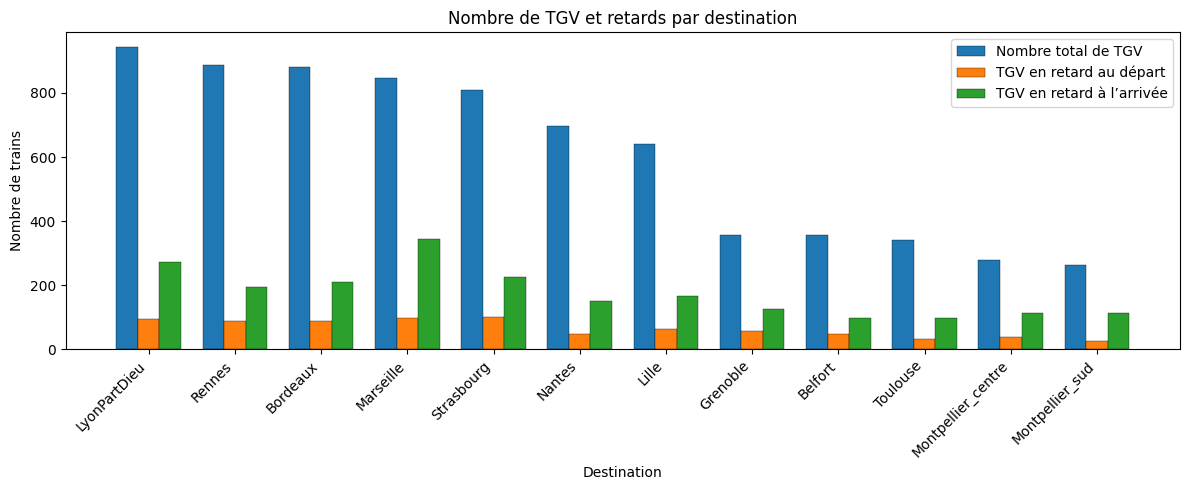

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# === 10. Préparer les données pour la visualisation ===

# S'assurer que toutes les destinations apparaissent dans les trois séries
destinations = nb_trains_par_destination.index

total_trains = nb_trains_par_destination.reindex(destinations, fill_value=0)
retard_depart = nb_retard_depart_par_destination.reindex(destinations, fill_value=0)
retard_arrivee = nb_retard_arrivee_par_destination.reindex(destinations, fill_value=0)

# === 11. Diagramme en barres groupées ===
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(destinations))
bar_width = 0.25

ax.bar(
    x - bar_width,
    total_trains.values,
    width=bar_width,
    label="Nombre total de TGV",
    edgecolor="black",
    linewidth=0.25
)

ax.bar(
    x,
    retard_depart.values,
    width=bar_width,
    label="TGV en retard au départ",
    edgecolor="black",
    linewidth=0.25
)

ax.bar(
    x + bar_width,
    retard_arrivee.values,
    width=bar_width,
    label="TGV en retard à l’arrivée",
    edgecolor="black",
    linewidth=0.25
)

# Axe des x
ax.set_xticks(x)
ax.set_xticklabels(destinations, rotation=45, ha="right")

# Titres et labels
ax.set_title("Nombre de TGV et retards par destination")
ax.set_xlabel("Destination")
ax.set_ylabel("Nombre de trains")

ax.legend()

plt.tight_layout()
plt.show()


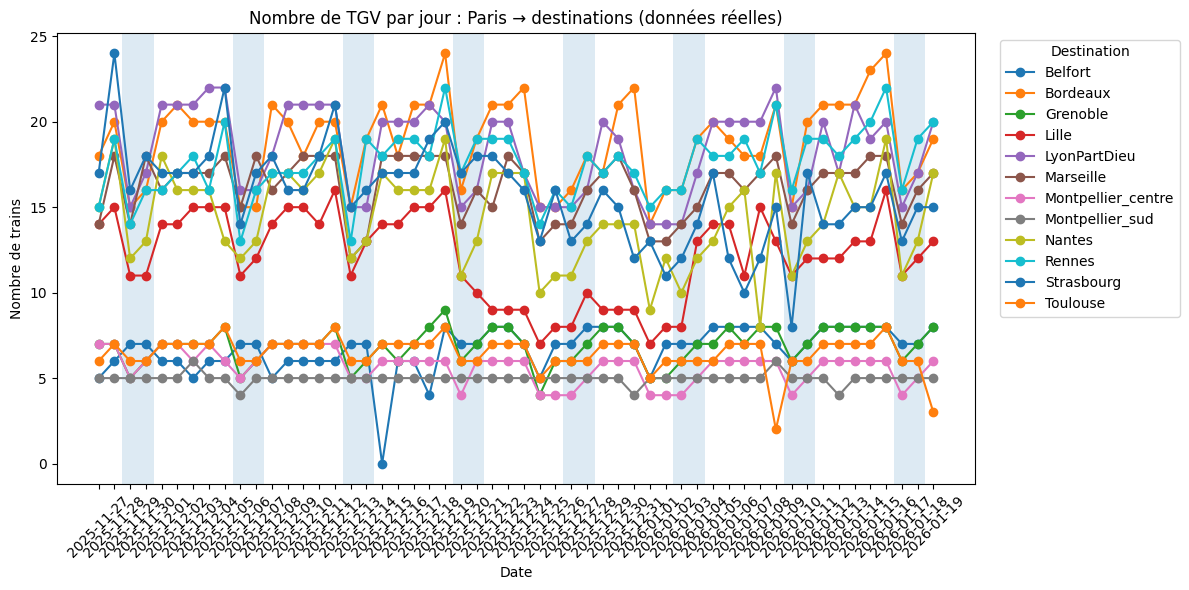

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def surligner_weekends(ax, dates):
    # dates : DatetimeIndex, liste de dates ou chaînes YYYY-MM-DD
    dates_dt = pd.to_datetime(dates)

    # DatetimeIndex → accès direct à dayofweek (sans .dt)
    weekends = dates_dt[dates_dt.dayofweek >= 5]  # 5=samedi, 6=dimanche

    for d in weekends:
        i = dates_dt.get_loc(d)
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.15)

# === 1. Garder uniquement les trains réels (départs effectivement observés) ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Compter le nombre de trains par date et par destination ===
table_counts = (
    df_reel.groupby(["date", "destination"])["Train"]
    .count()
    .unstack("destination")
    .fillna(0)
    .sort_index()
)

# === 3. Tracer l'évolution quotidienne (une ligne par destination) ===
# === Création explicite de la figure et de l'axe ===
fig, ax = plt.subplots(figsize=(12, 6))

# Axe des x = positions (0, 1, 2, ...)
x = range(len(table_counts.index))

# === Tracer une courbe par destination ===
for dest in table_counts.columns:
    ax.plot(x, table_counts[dest].values, marker="o", label=dest)

# === Mettre les dates comme labels de l'axe x ===
ax.set_xticks(list(x))
ax.set_xticklabels(table_counts.index.astype(str), rotation=45)

# === Surligner les week-ends (fonction déjà définie) ===
surligner_weekends(ax, table_counts.index)

# === Titres et légende ===
ax.set_title("Nombre de TGV par jour : Paris → destinations (données réelles)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de trains")
ax.legend(title="Destination", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

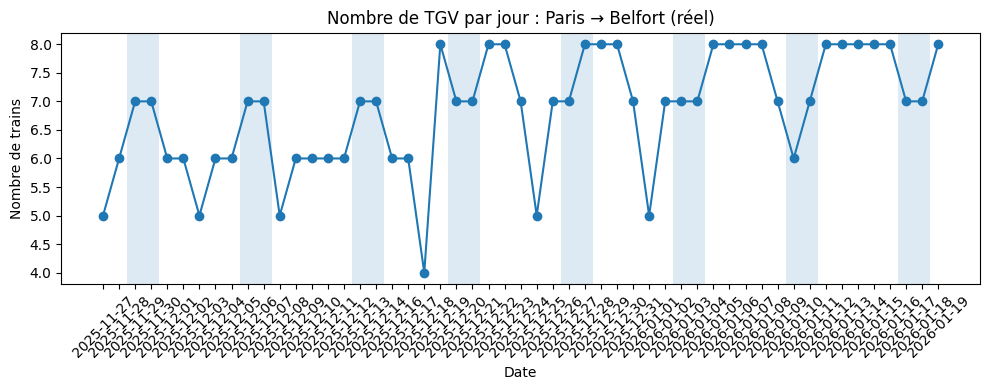

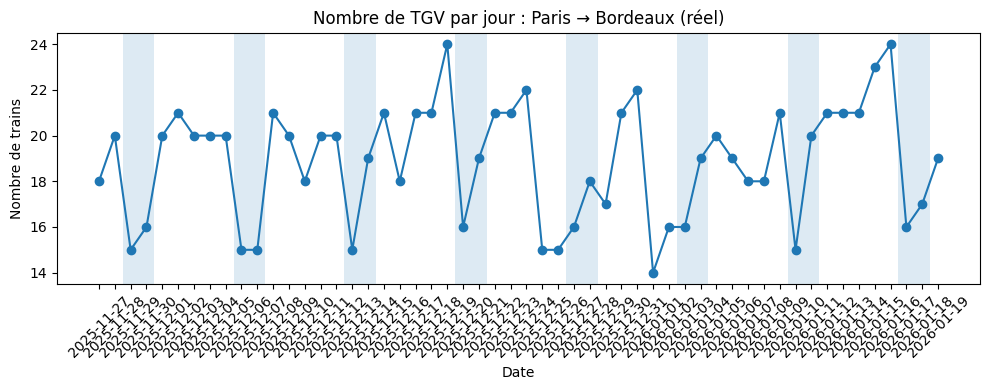

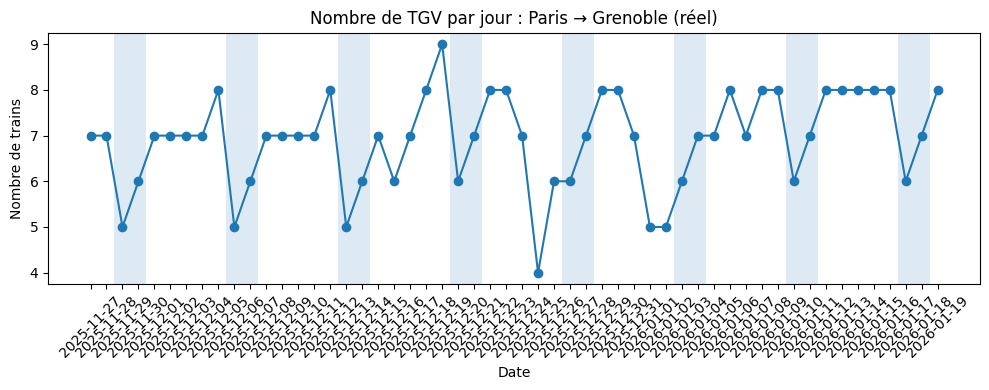

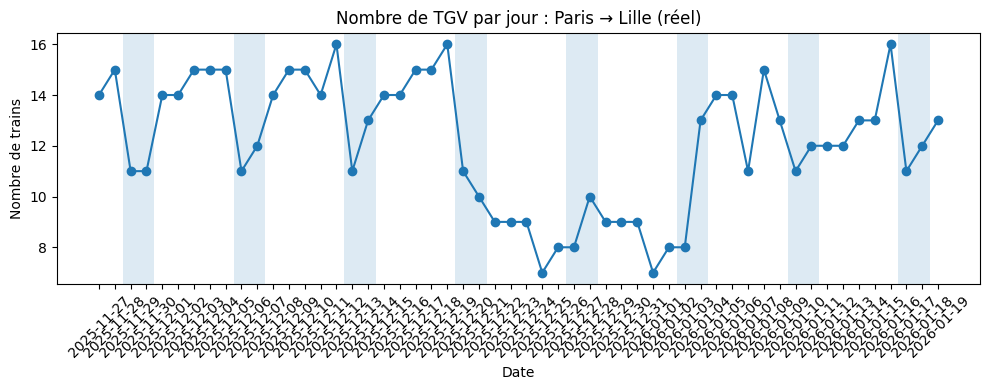

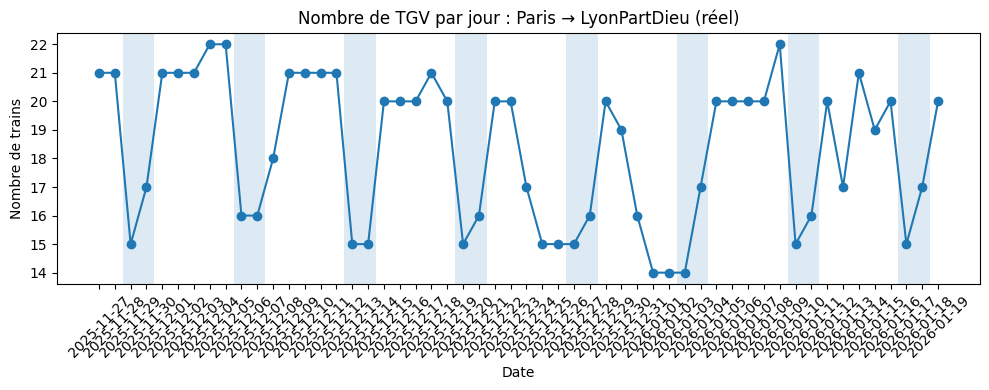

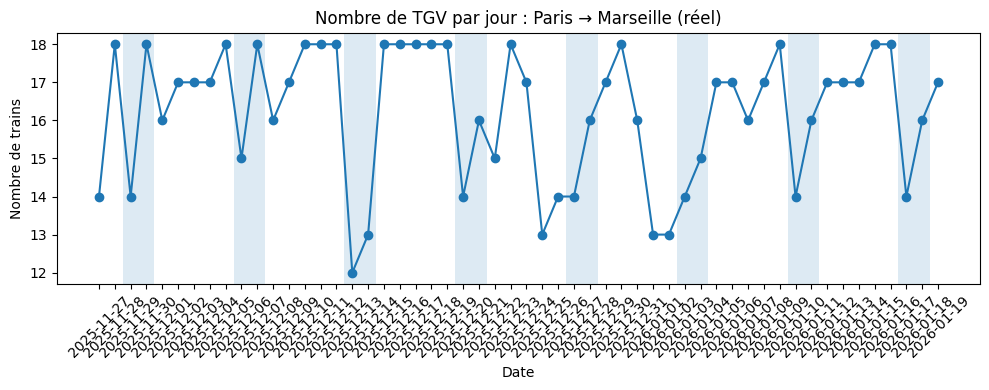

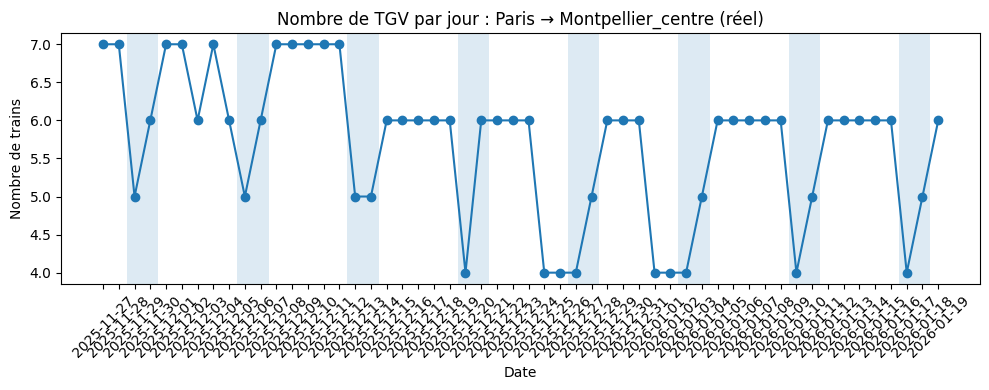

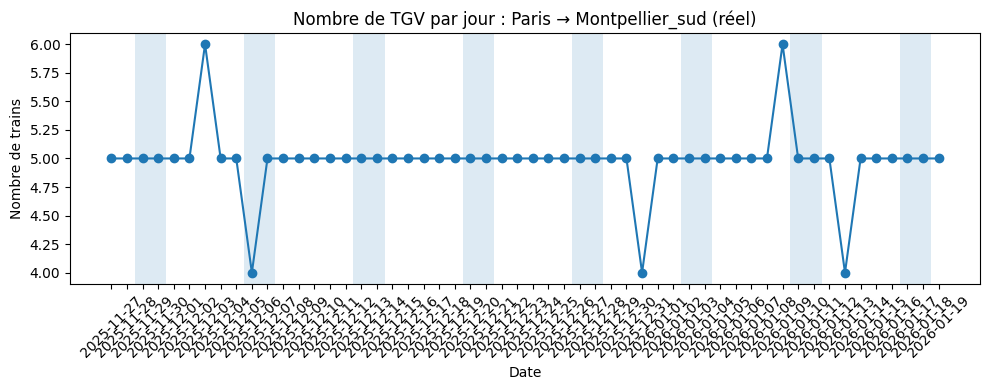

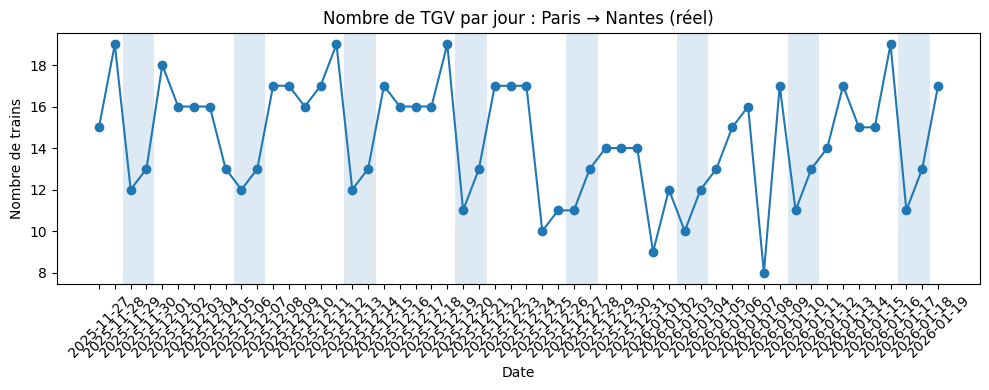

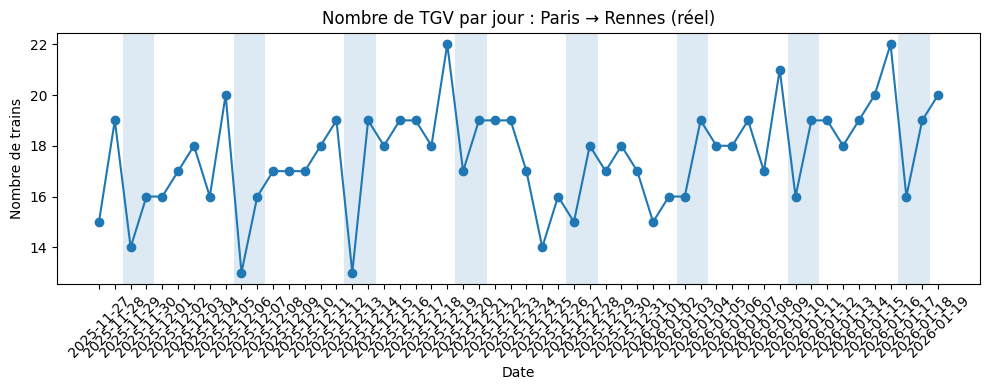

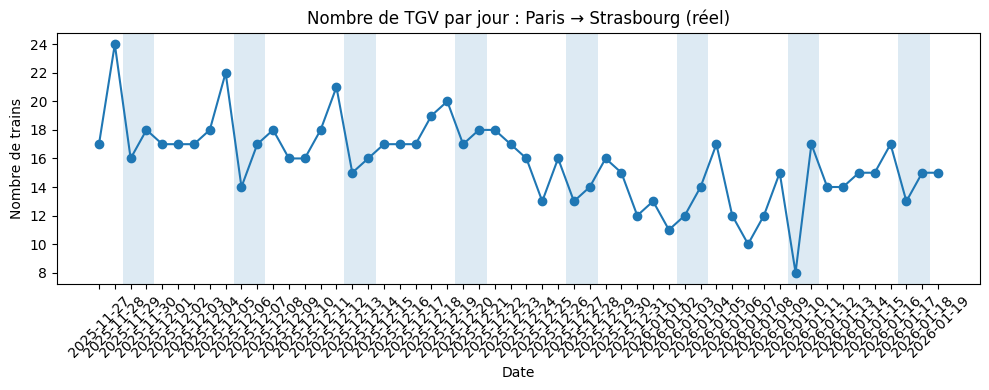

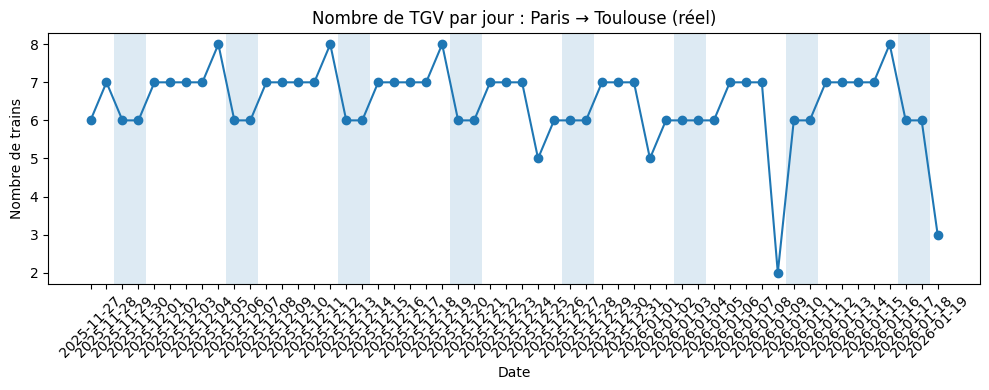

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Garder uniquement les trains réels ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Liste des destinations ===
destinations = sorted(df_reel["destination"].dropna().unique())

# === 3. Une figure par destination ===
for dest in destinations:
    serie = (
        df_reel[df_reel["destination"] == dest]
        .groupby("date")["Train"]
        .count()
        .sort_index()
    )

    # === Création explicite de la figure et de l'axe ===
    fig, ax = plt.subplots(figsize=(10, 4))

    # Axe des x = positions (0, 1, 2, ...)
    x = range(len(serie.index))

    # Courbe
    ax.plot(x, serie.values, marker="o")

    # Labels de dates
    ax.set_xticks(list(x))
    ax.set_xticklabels(serie.index.astype(str), rotation=45)

    # Surligner les week-ends
    surligner_weekends(ax, serie.index)

    # Titres et labels
    ax.set_title(f"Nombre de TGV par jour : Paris → {dest} (réel)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de trains")

    plt.tight_layout()
    plt.show()

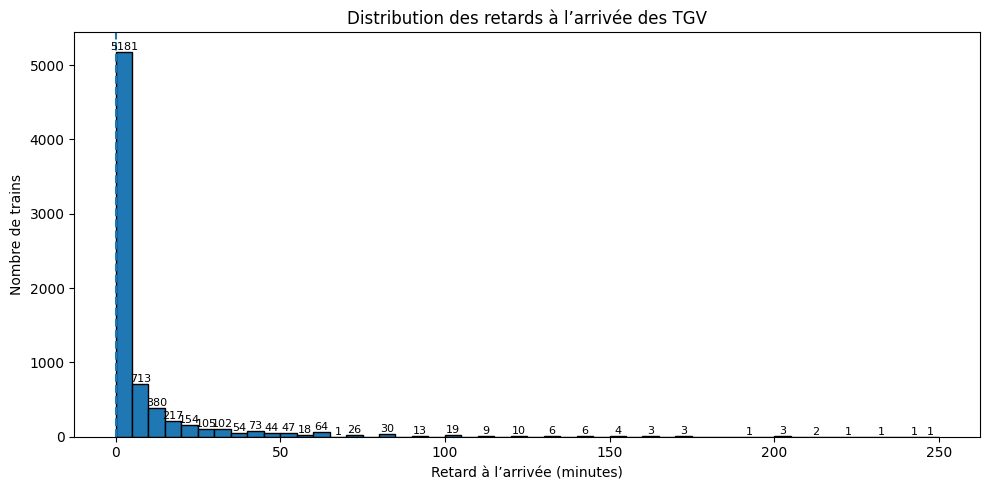

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Séparer les données réelles et les prévisions ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()
df_prevu = trains_all[trains_all["scenario"] == "prevu"].copy()

# Clés pour apparier prévision et réel
cles_fusion = ["date", "origine", "destination", "Train"]

# === 2. Fusionner les données (seulement les trains appariés) ===
df_merged = pd.merge(
    df_reel,
    df_prevu,
    on=cles_fusion,
    suffixes=("_reel", "_prevu"),
    how="inner"
)

# === 3. Construire les datetime de départ et d'arrivée ===
df_merged["depart_reel_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_reel"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["depart_prevu_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_prevu"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["arrivee_reel_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Arrivee_reel"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["arrivee_prevu_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Arrivee_prevu"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# === 4. Correction des arrivées après minuit ===
mask_reel_nuit = df_merged["arrivee_reel_dt"] < df_merged["depart_reel_dt"]
df_merged.loc[mask_reel_nuit, "arrivee_reel_dt"] += pd.Timedelta(days=1)

mask_prevu_nuit = df_merged["arrivee_prevu_dt"] < df_merged["depart_prevu_dt"]
df_merged.loc[mask_prevu_nuit, "arrivee_prevu_dt"] += pd.Timedelta(days=1)

# === 5. Calcul du retard à l'arrivée (en minutes) ===
df_merged["retard_arrivee_min"] = (
    df_merged["arrivee_reel_dt"] - df_merged["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# Supprimer les valeurs non calculables
df_merged = df_merged.dropna(subset=["retard_arrivee_min"])

# === 6. Visualisation de la distribution des retards ===
plt.figure(figsize=(10, 5))

# Définir manuellement les bornes des classes (0, 5, 10, 15, ...)
bornes = np.arange(0, df_merged["retard_arrivee_min"].max() + 5, 5)

# Histogramme : chaque barre représente un intervalle de retard (en minutes)
counts, bins, patches = plt.hist(
    df_merged["retard_arrivee_min"],
    bins=bornes,
    edgecolor="black"
)
# Ajouter les valeurs au-dessus de chaque barre
for count, patch in zip(counts, patches):
    if count > 0:  # éviter d'afficher les zéros
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Distribution des retards à l’arrivée des TGV")
plt.xlabel("Retard à l’arrivée (minutes)")
plt.ylabel("Nombre de trains")

# Ligne verticale à 0 minute (frontière avance / retard)
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()


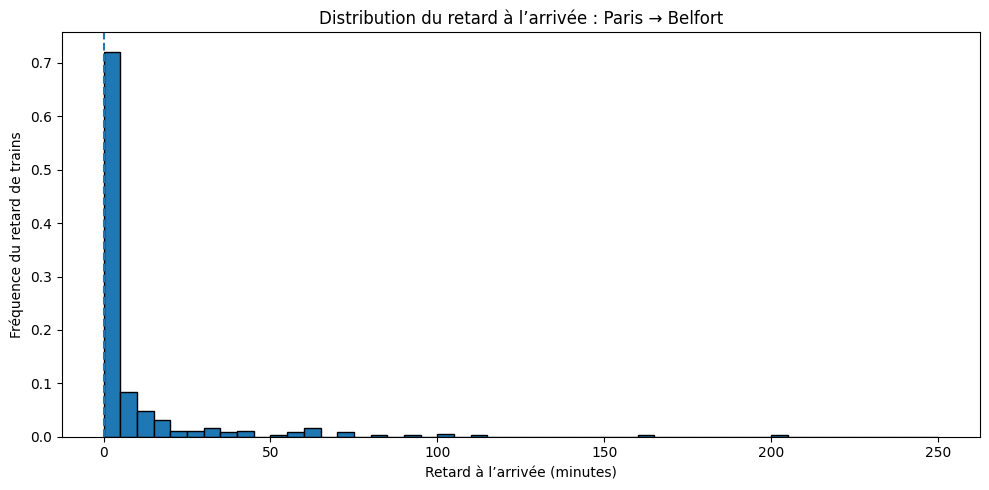

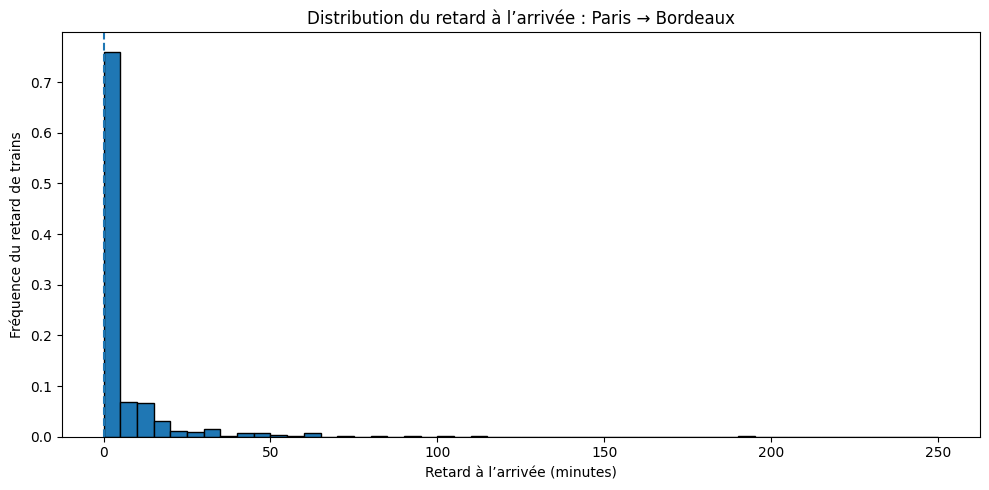

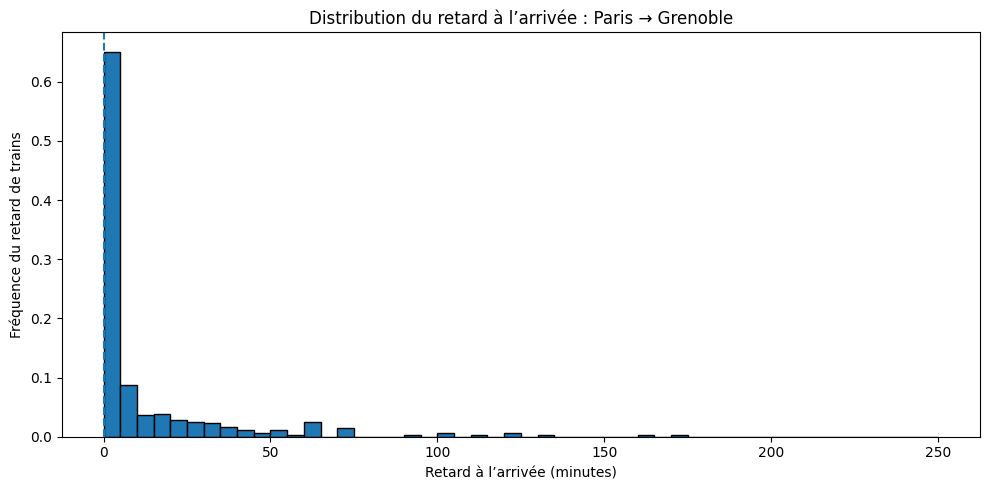

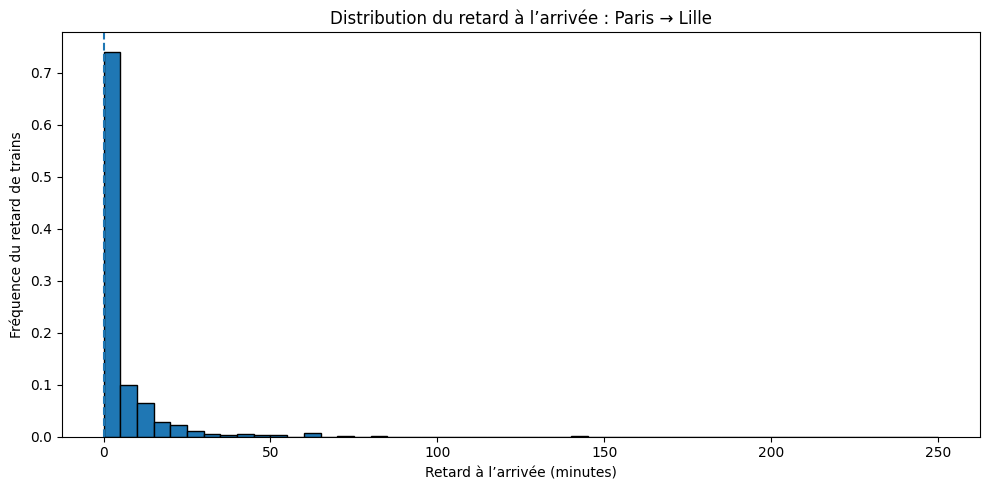

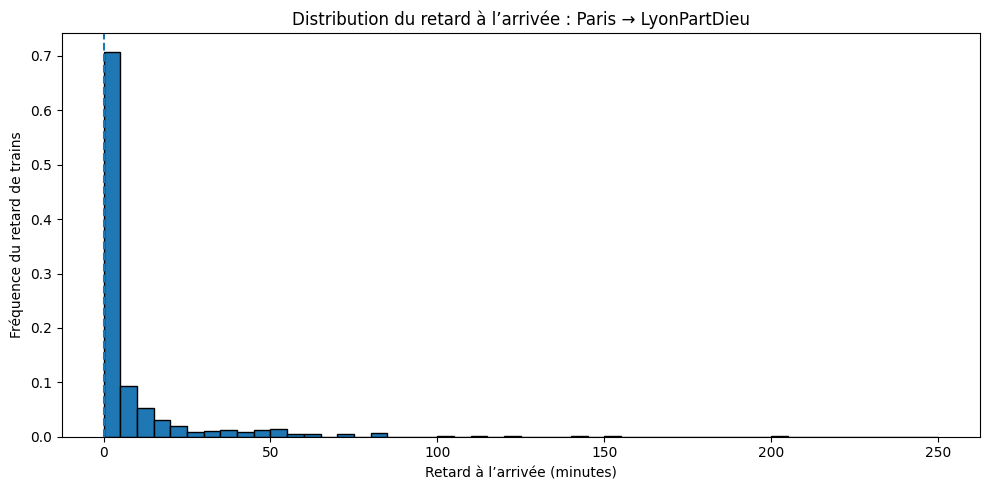

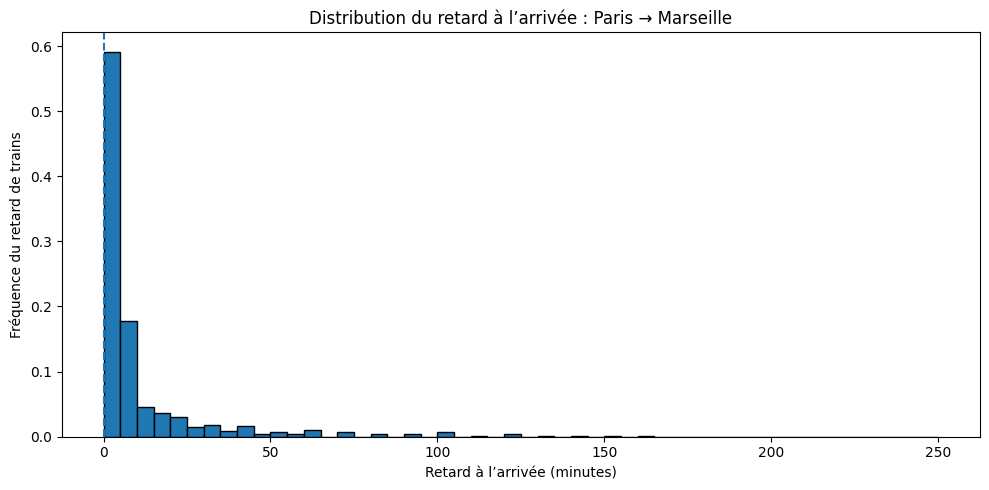

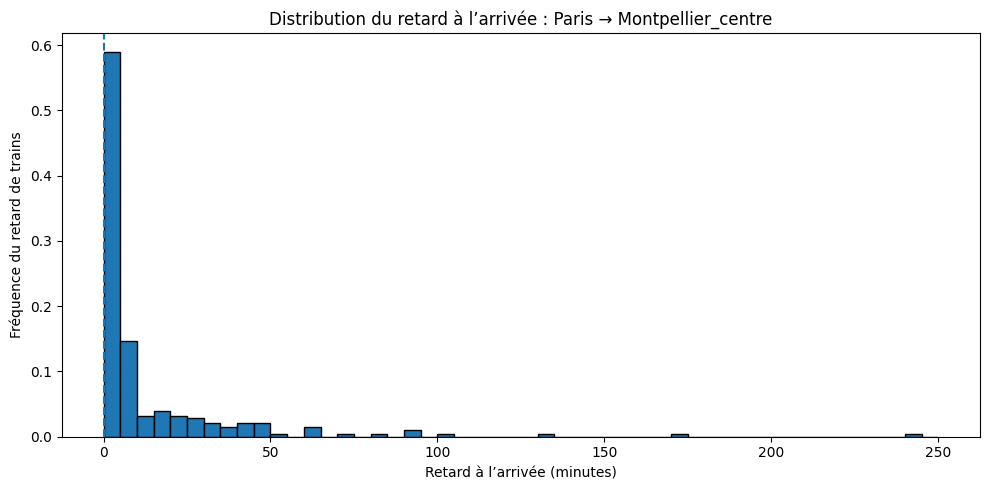

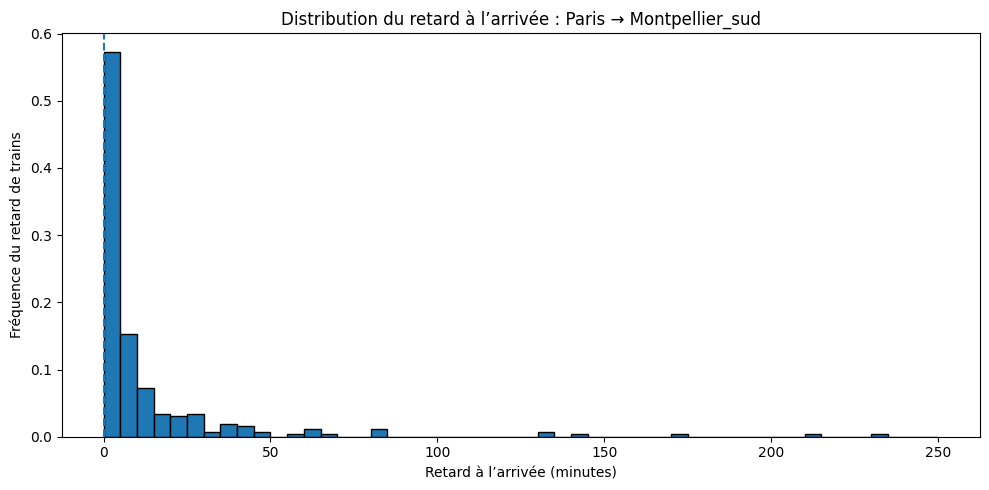

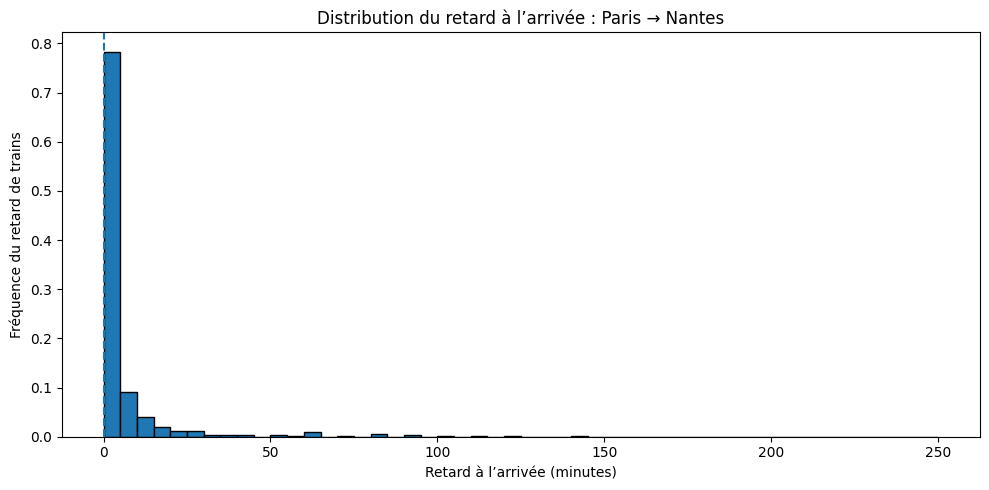

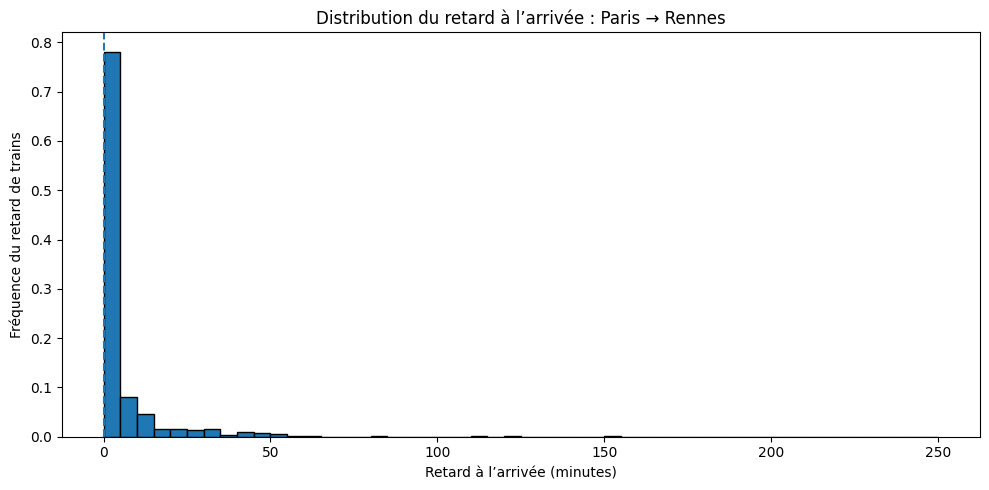

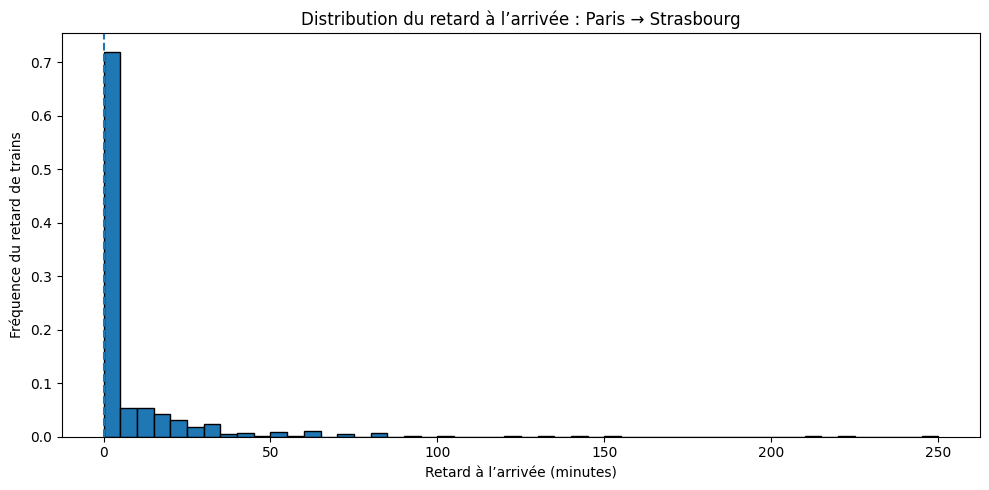

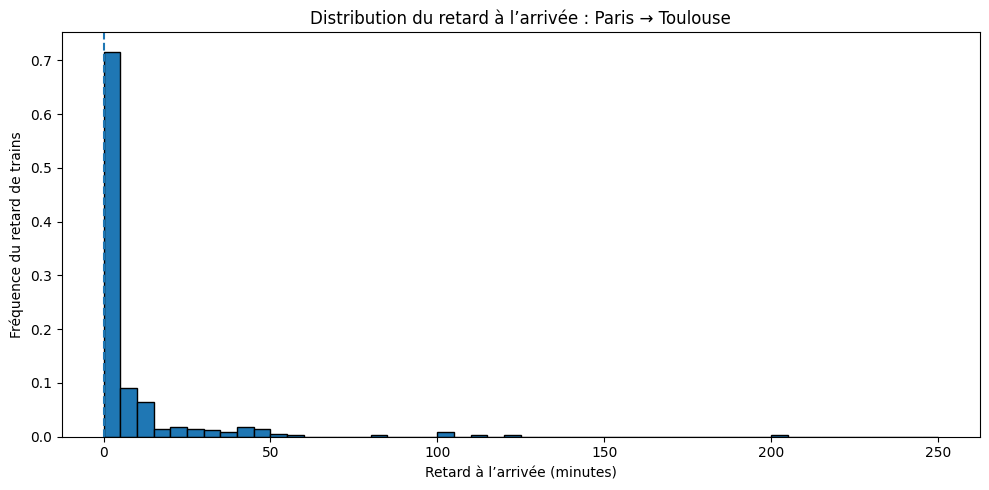

In [10]:
# === 1. Choisir la variable de retard à analyser ===
col_retard = "retard_arrivee_min"

# (Optionnel) Ne garder que les retards positifs si vous analysez strictement "le retard"
# df_plot = df_merged[df_merged[col_retard] > 0].copy()
df_plot = df_merged.copy()

# === 2. Définir des classes de 5 minutes (0,5,10,...) ===
# On fixe une borne max commune pour comparer visuellement les destinations
max_retard = df_plot[col_retard].dropna().max()
bornes = np.arange(0, max_retard + 5, 5)

# === 3. Générer un histogramme par destination ===
destinations = sorted(df_plot["destination"].dropna().unique())

for dest in destinations:
    data_dest = df_plot.loc[df_plot["destination"] == dest, col_retard].dropna()
    # Nombre total de trains pour cette destination sur toute la période
    nb_total_dest = len(df_plot[df_plot["destination"] == dest])

    # (Optionnel) Si vous voulez strictement (0,5], (5,10], ... : garder seulement > 0
    # data_dest = data_dest[data_dest > 0]

    plt.figure(figsize=(10, 5))
    #plt.hist(data_dest, bins=bornes, edgecolor="black")
    plt.hist(
        data_dest,
        bins=bornes,
        edgecolor="black",
        weights=np.ones(len(data_dest)) / nb_total_dest
        )

    plt.title(f"Distribution du retard à l’arrivée : Paris → {dest}")
    plt.xlabel("Retard à l’arrivée (minutes)")
    plt.ylabel("Fréquence du retard de trains")
    plt.axvline(0, linestyle="--")

    plt.tight_layout()
    plt.show()
    

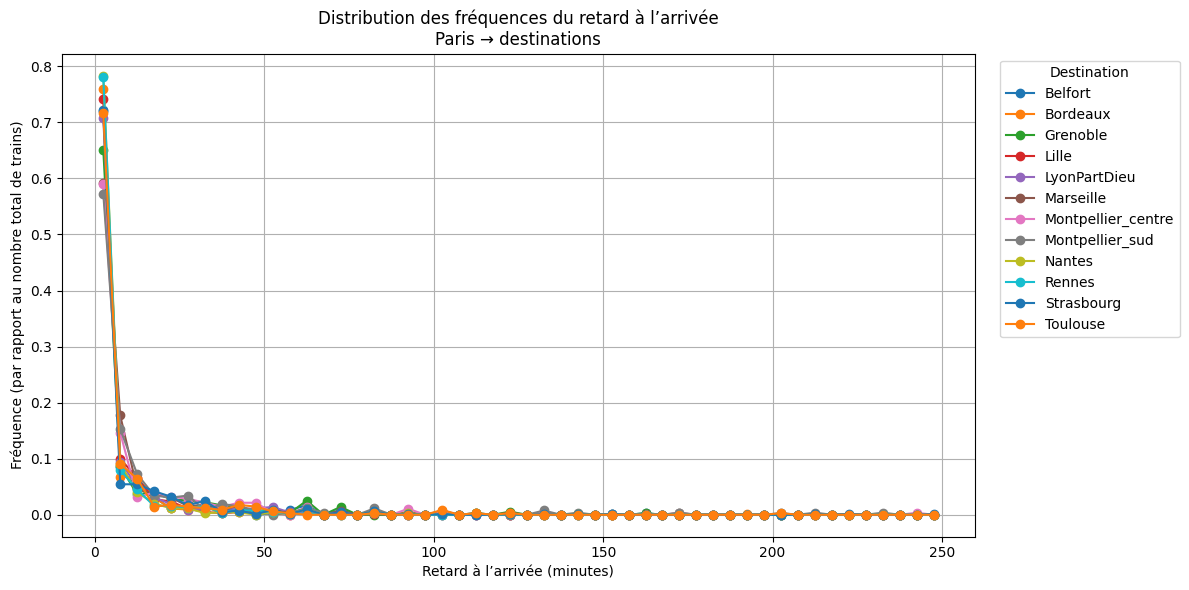

In [11]:
import numpy as np
import matplotlib.pyplot as plt

col_retard = "retard_arrivee_min"

# 只保留需要的列
df_plot = df_merged[["destination", col_retard]].dropna()

# 分箱（5 分钟一档）
max_retard = df_plot[col_retard].max()
bornes = np.arange(0, max_retard + 5, 5)
#bornes = np.arange(5, max_retard + 5, 5)

# 区间中心点（用于画折线）
centres = (bornes[:-1] + bornes[1:]) / 2

plt.figure(figsize=(12, 6))

destinations = sorted(df_plot["destination"].unique())

for dest in destinations:
    data_dest = df_plot.loc[
        df_plot["destination"] == dest,
        col_retard
    ]

    # Nombre total de trains sur la période pour cette destination
    nb_total_dest = len(data_dest)

    # Histogramme sous forme de fréquences
    counts, _ = np.histogram(data_dest, bins=bornes)
    frequences = counts / nb_total_dest

    # Tracer la courbe de fréquence
    plt.plot(centres, frequences, marker="o", label=dest)

plt.title("Distribution des fréquences du retard à l’arrivée\nParis → destinations")
plt.xlabel("Retard à l’arrivée (minutes)")
plt.ylabel("Fréquence (par rapport au nombre total de trains)")
plt.legend(title="Destination", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

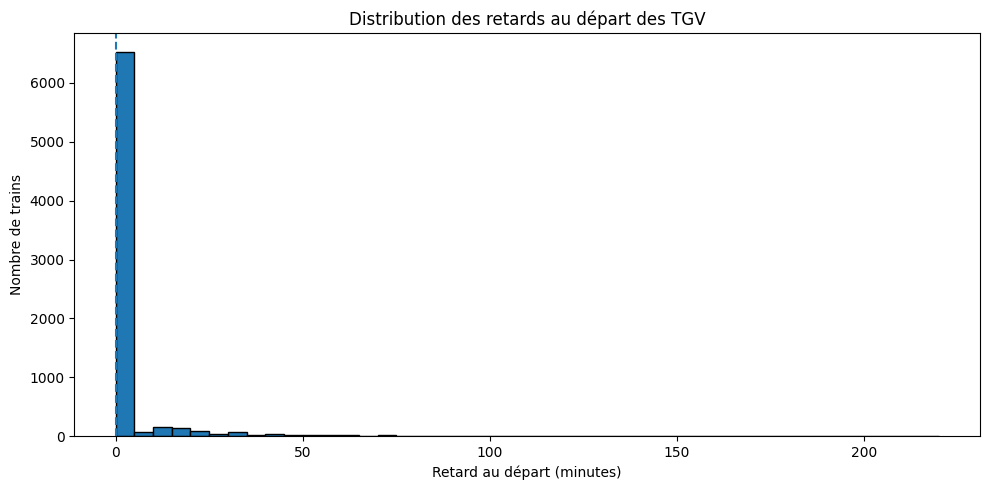

In [12]:
# === 1. Séparer les données réelles et les prévisions ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()
df_prevu = trains_all[trains_all["scenario"] == "prevu"].copy()

# Clés pour apparier prévision et réel
cles_fusion = ["date", "origine", "destination", "Train"]

# === 2. Fusionner les données (seulement les trains appariés) ===
df_merged = pd.merge(
    df_reel,
    df_prevu,
    on=cles_fusion,
    suffixes=("_reel", "_prevu"),
    how="inner"
)

# === 3. Construire les datetime de départ (prévu et réel) ===
df_merged["depart_reel_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_reel"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_merged["depart_prevu_dt"] = pd.to_datetime(
    df_merged["date"].astype(str) + " " + df_merged["Depart_prevu"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# === 4. Calcul du retard au départ (en minutes) ===
df_merged["retard_depart_min"] = (
    df_merged["depart_reel_dt"] - df_merged["depart_prevu_dt"]
).dt.total_seconds() / 60.0

# Supprimer les valeurs non calculables
df_merged = df_merged.dropna(subset=["retard_depart_min"])

# === 5. Visualisation de la distribution des retards au départ ===
plt.figure(figsize=(10, 5))

# Définir manuellement les bornes des classes (0, 5, 10, 15, ...)
bornes = np.arange(0, df_merged["retard_depart_min"].max() + 5, 5)

# Histogramme : chaque barre représente un intervalle de retard (en minutes)
plt.hist(
    df_merged["retard_depart_min"],
    bins=bornes,
    edgecolor="black"
)

plt.title("Distribution des retards au départ des TGV")
plt.xlabel("Retard au départ (minutes)")
plt.ylabel("Nombre de trains")

# Ligne verticale à 0 minute (frontière avance / retard)
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

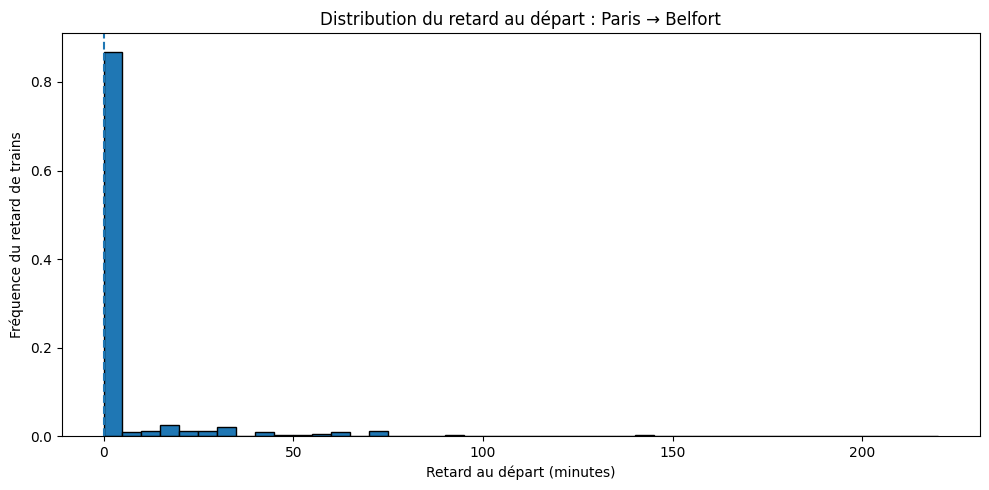

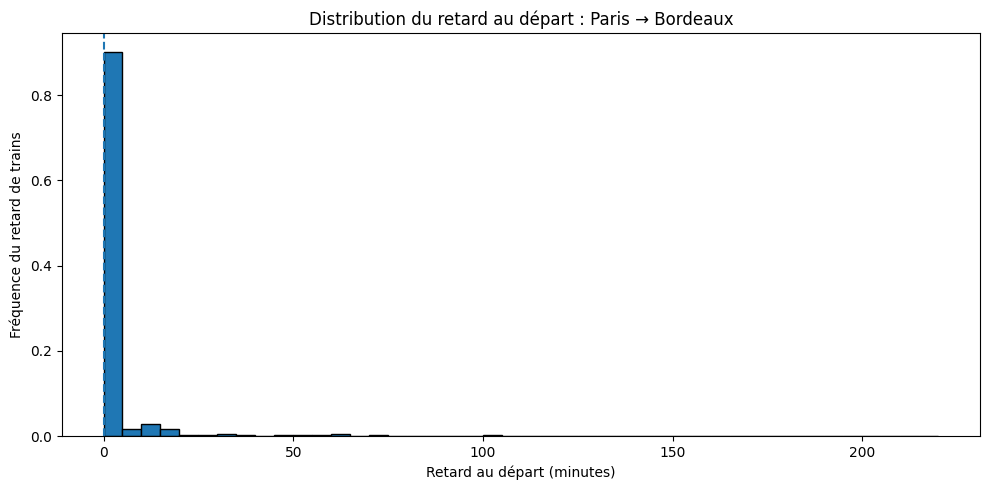

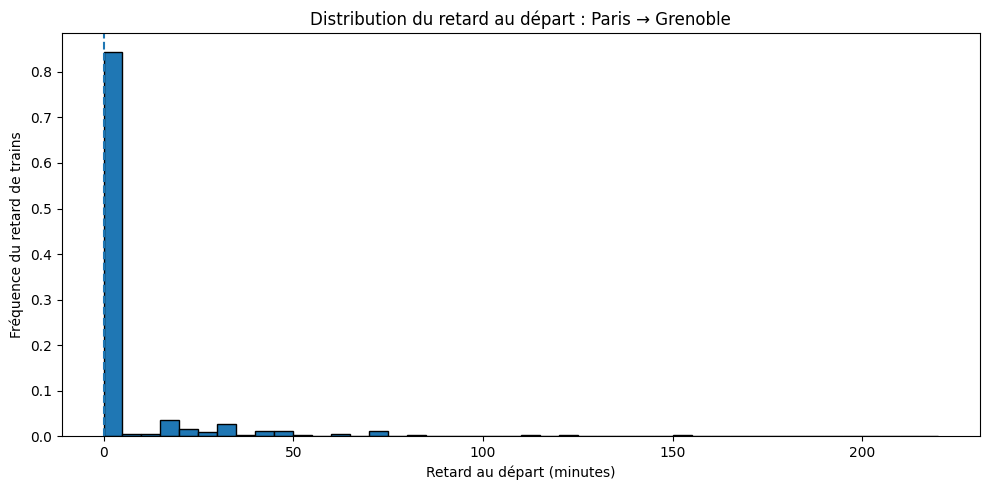

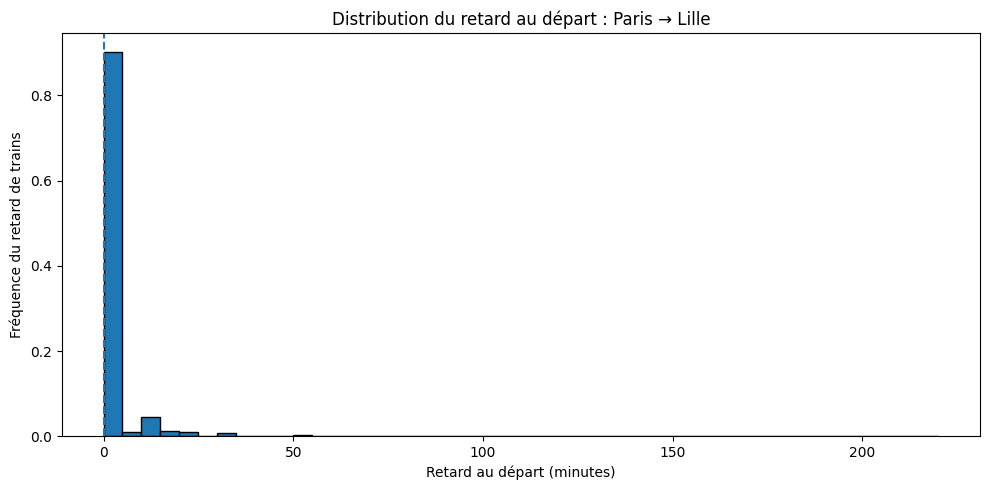

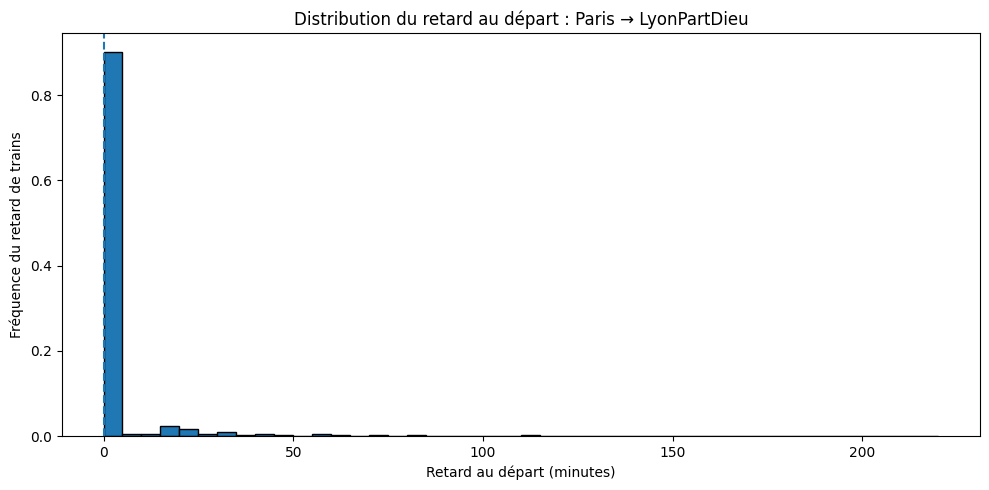

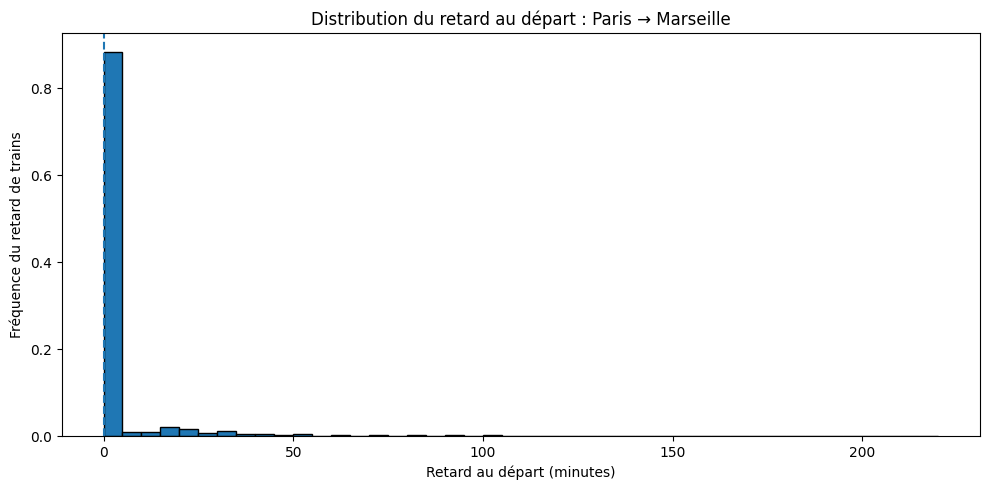

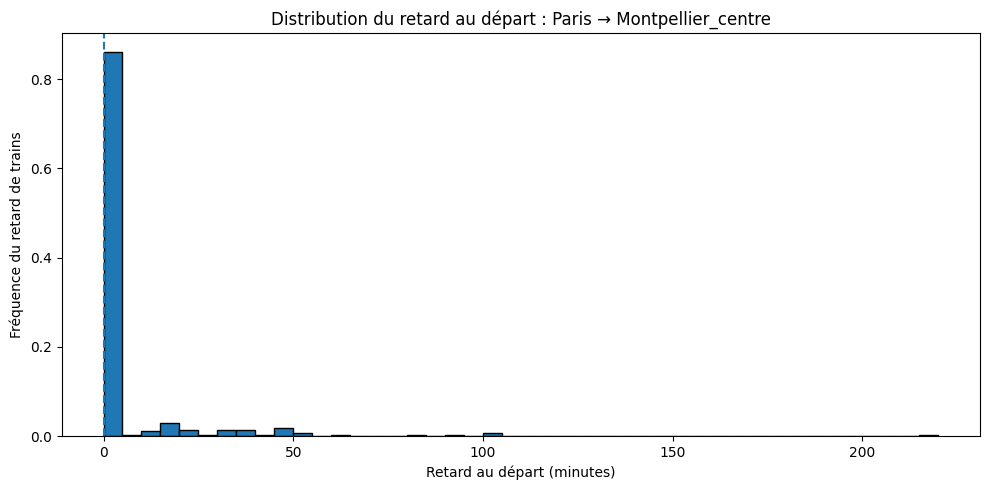

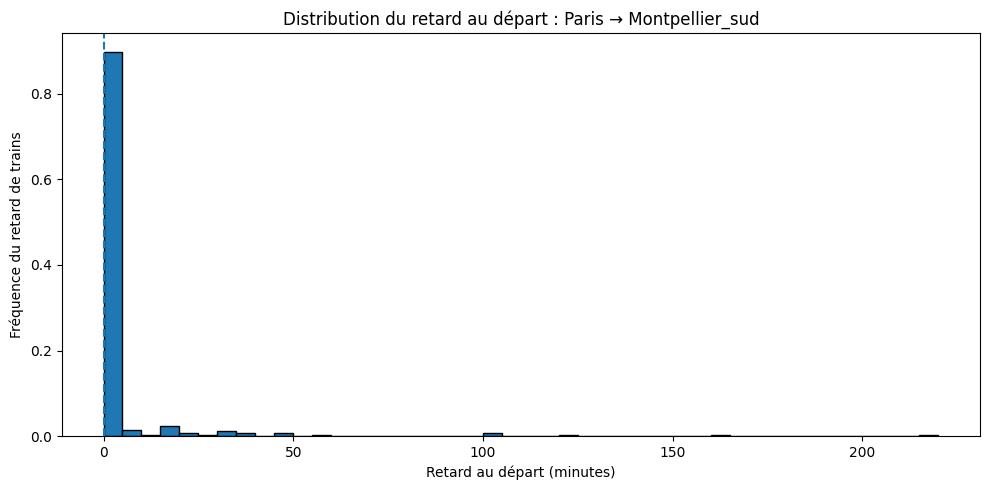

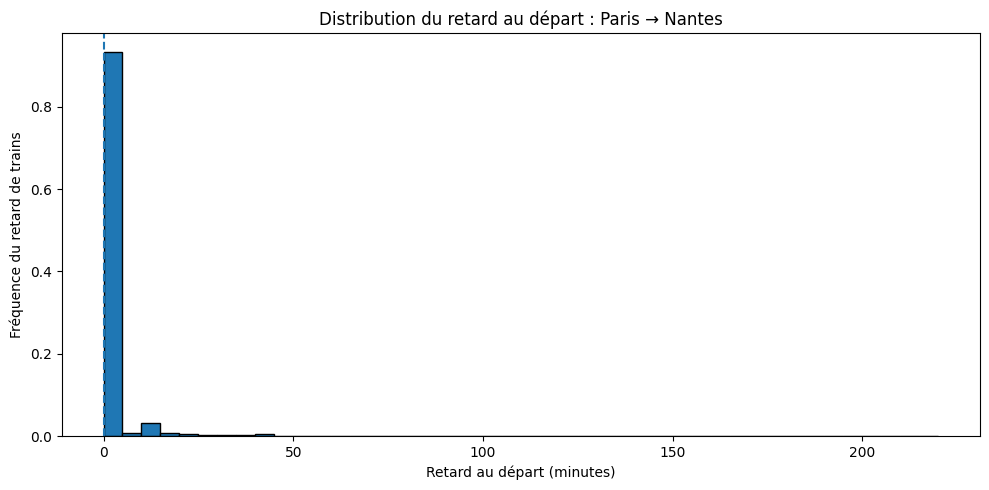

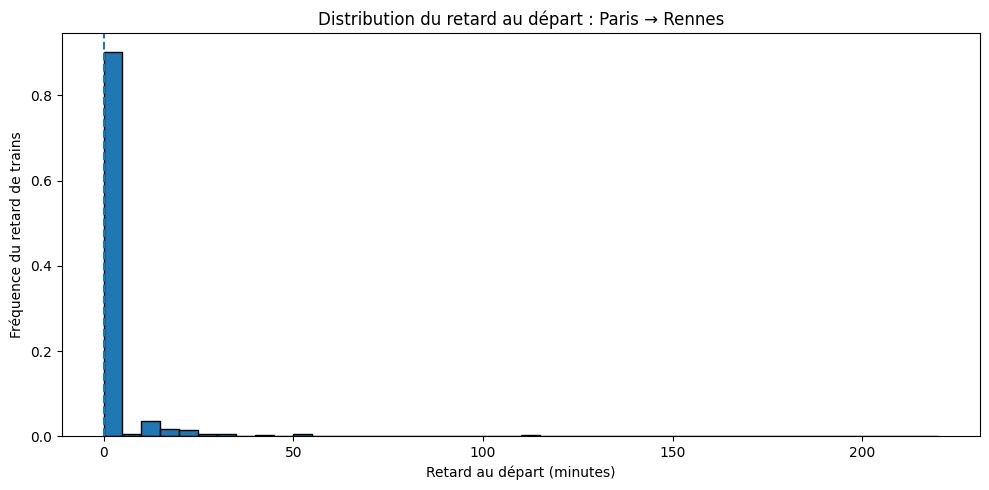

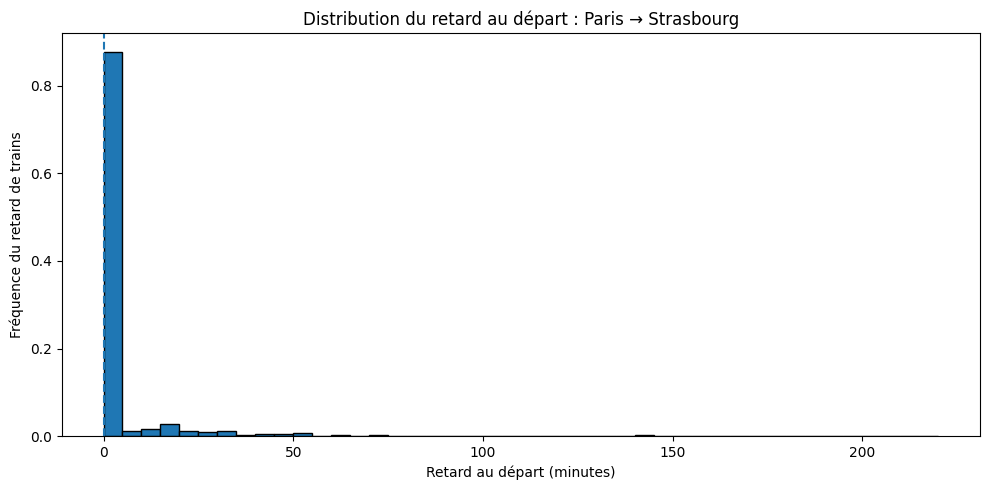

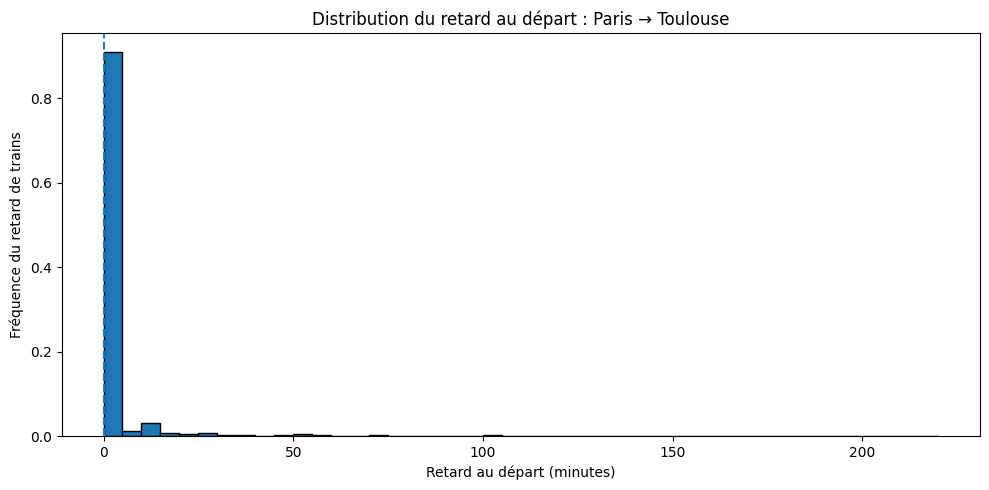

In [13]:
# === 1. Choisir la variable de retard à analyser ===
col_retard = "retard_depart_min"

# (Optionnel) Ne conserver que les retards strictement positifs (> 0)
# df_plot = df_merged[df_merged[col_retard] > 0].copy()
df_plot = df_merged.copy()

# === 2. Définir des classes de 5 minutes (0, 5, 10, ...) ===
# On utilise une borne maximale commune pour faciliter la comparaison entre villes
max_retard = df_plot[col_retard].dropna().max()
bornes = np.arange(0, max_retard + 5, 5)

# === 3. Générer un histogramme par destination ===
destinations = sorted(df_plot["destination"].dropna().unique())

for dest in destinations:
    
    # Extraire les retards au départ pour cette destination
    data_dest = df_plot.loc[
        df_plot["destination"] == dest,
        col_retard
    ].dropna()
    # Nombre total de trains pour cette destination sur toute la période
    nb_total_dest = len(df_plot[df_plot["destination"] == dest])
    # (Optionnel) Ne garder que les retards (> 0 min)
    # data_dest = data_dest[data_dest > 0]

    plt.figure(figsize=(10, 5))
    #plt.hist(data_dest, bins=bornes, edgecolor="black")
    plt.hist(
        data_dest,
        bins=bornes,
        edgecolor="black",
        weights=np.ones(len(data_dest)) / nb_total_dest
        )

    plt.title(f"Distribution du retard au départ : Paris → {dest}")
    plt.xlabel("Retard au départ (minutes)")
    plt.ylabel("Fréquence du retard de trains")

    # Ligne verticale à 0 minute (frontière avance / retard)
    plt.axvline(0, linestyle="--")

    plt.tight_layout()
    plt.show()


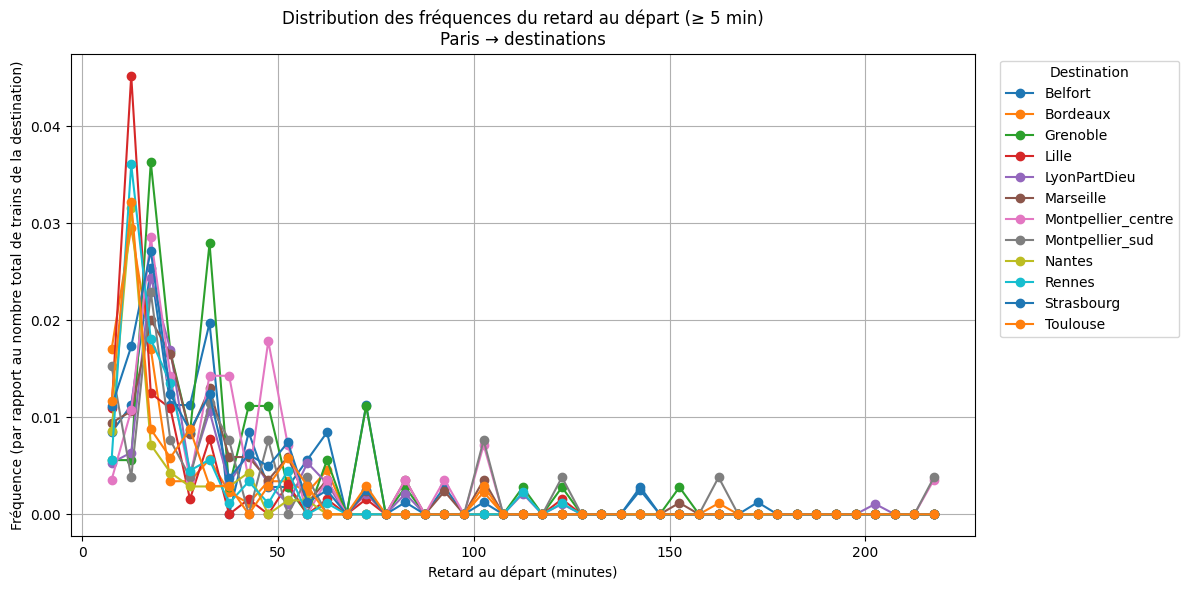

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. Choisir la variable de retard à analyser ===
col_retard = "retard_depart_min"

# === 2. Préparer les données (une ligne = un train apparié) ===
df_plot = df_merged[["destination", col_retard]].dropna()

# (Optionnel) Se concentrer sur les retards "significatifs" (>= 5 minutes)
# df_plot = df_plot[df_plot[col_retard] >= 5]

# === 3. Définir des classes de 5 minutes en excluant 0–5 ===
max_retard = df_plot[col_retard].max()
bornes = np.arange(5, max_retard + 5, 5)

# Centres des classes (pour tracer une courbe)
centres = (bornes[:-1] + bornes[1:]) / 2

# === 4. Tracer une courbe de fréquences par destination sur une seule figure ===
plt.figure(figsize=(12, 6))

destinations = sorted(df_plot["destination"].unique())

for dest in destinations:
    data_dest = df_plot.loc[df_plot["destination"] == dest, col_retard]

    # Nombre total de trains pour cette destination (sur la période, après filtre >= 5 min)
    nb_total_dest = len(data_dest)
    if nb_total_dest == 0:
        continue

    # Fréquences par classe
    counts, _ = np.histogram(data_dest, bins=bornes)
    frequences = counts / nb_total_dest

    plt.plot(centres, frequences, marker="o", label=dest)

plt.title("Distribution des fréquences du retard au départ (≥ 5 min)\nParis → destinations")
plt.xlabel("Retard au départ (minutes)")
plt.ylabel("Fréquence (par rapport au nombre total de trains de la destination)")
plt.legend(title="Destination", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

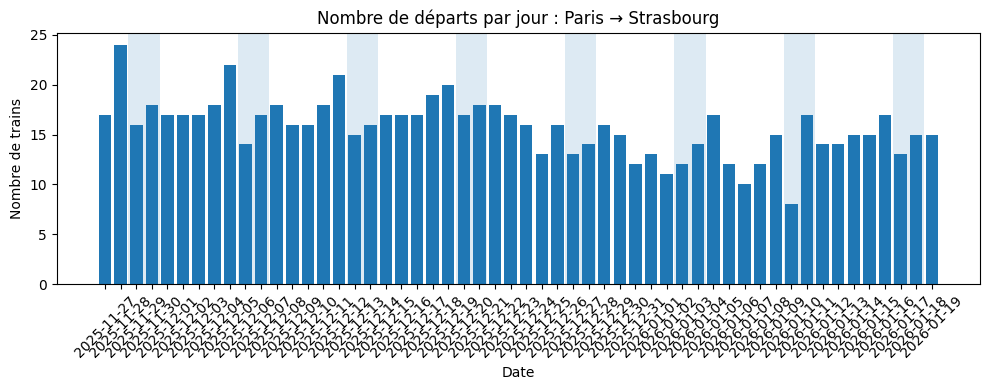

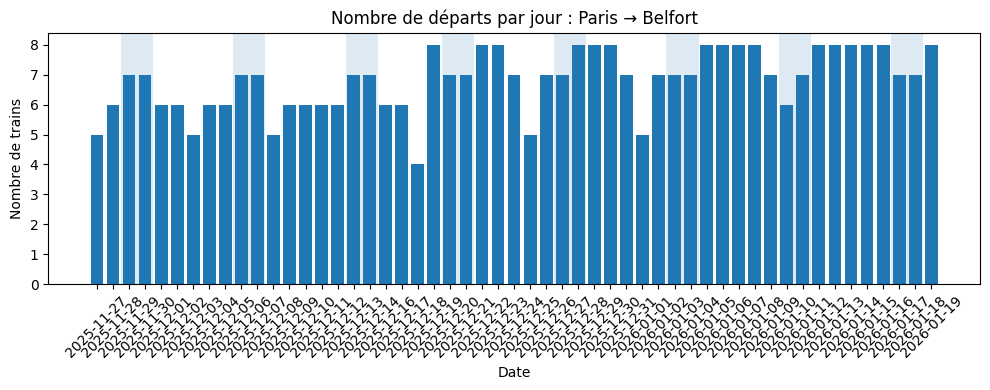

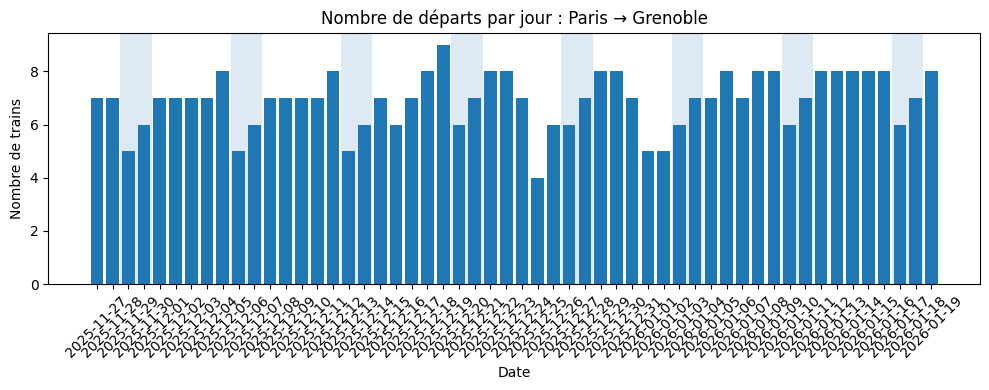

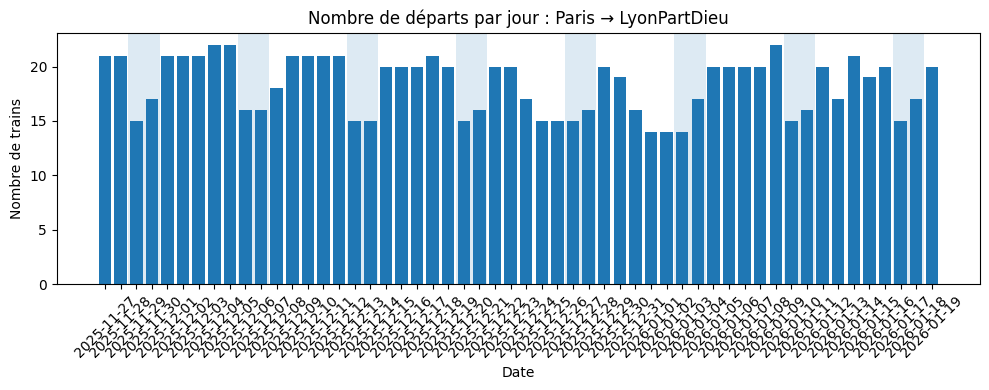

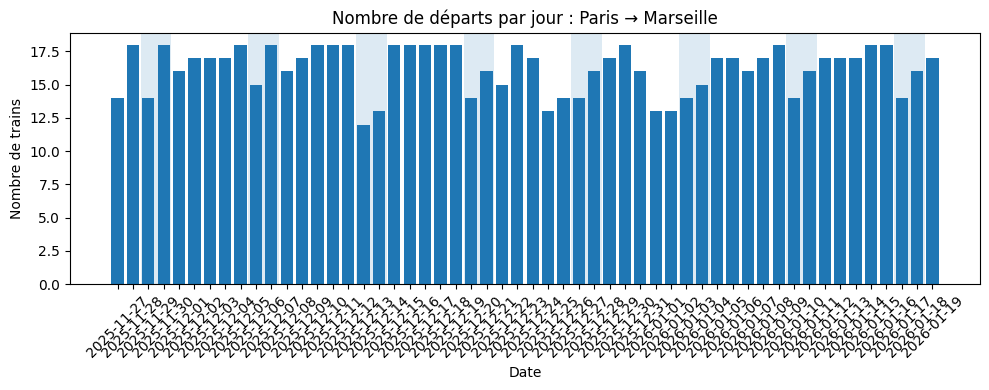

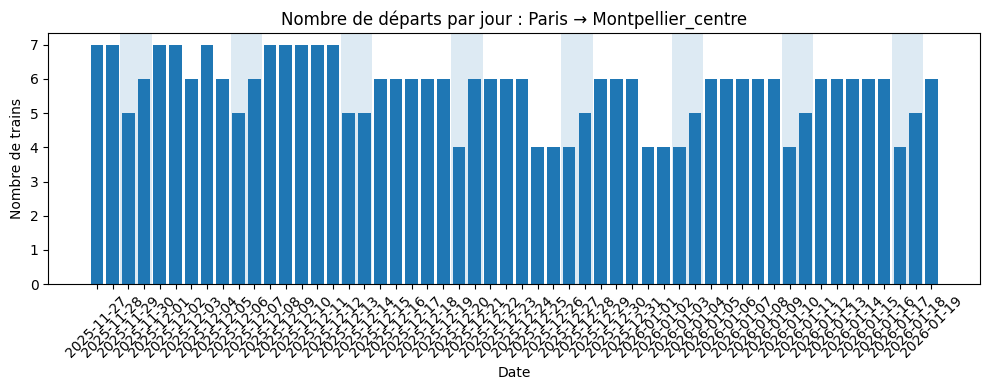

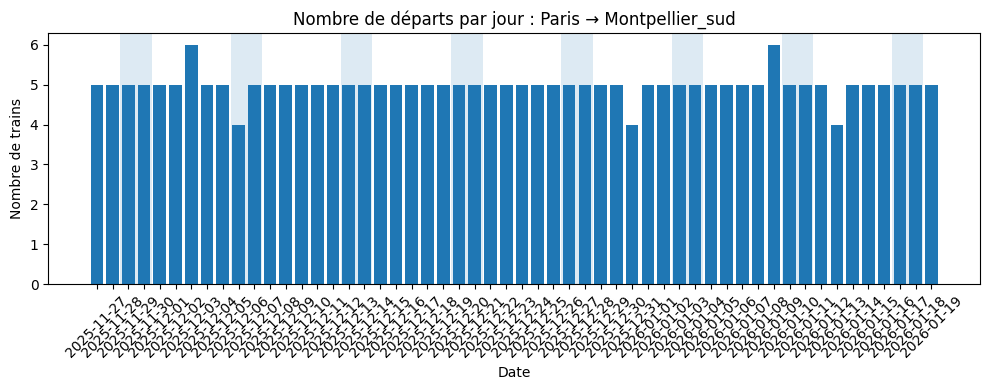

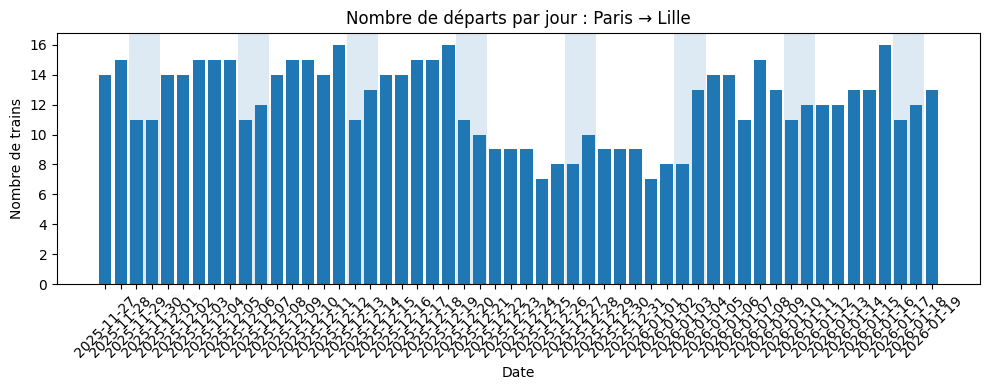

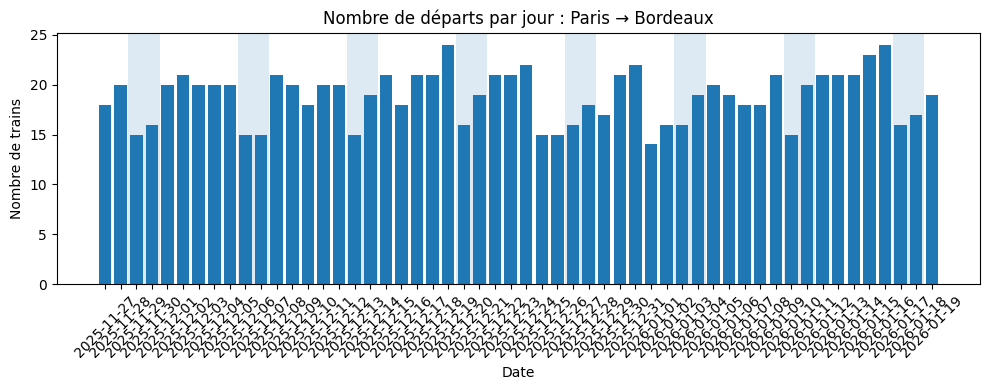

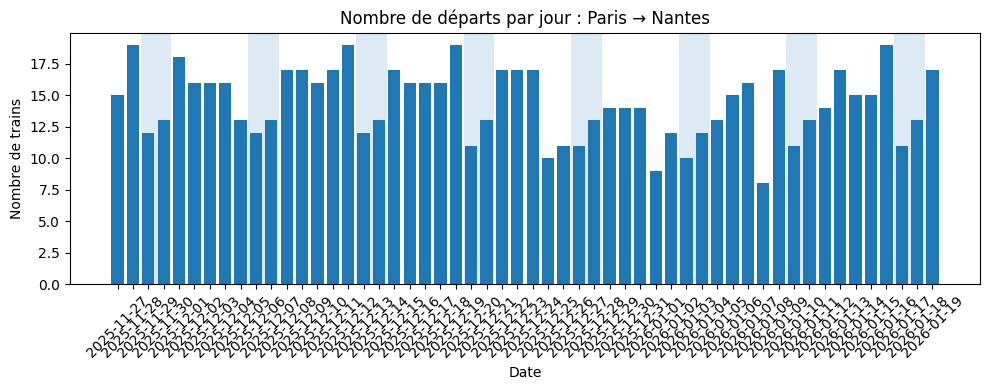

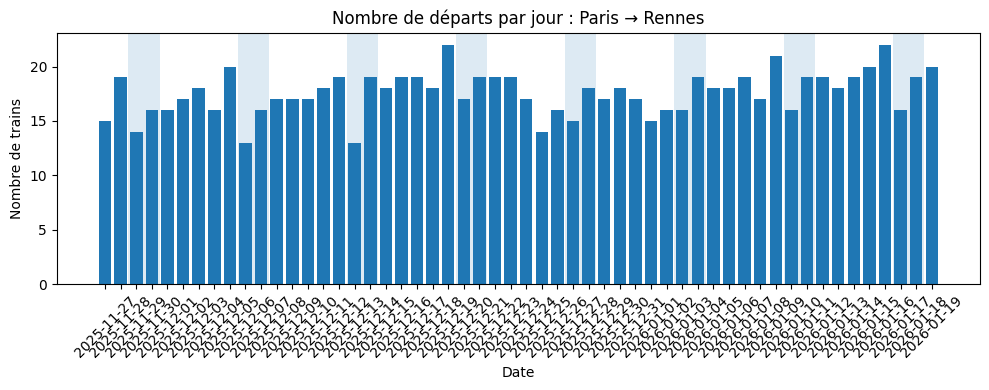

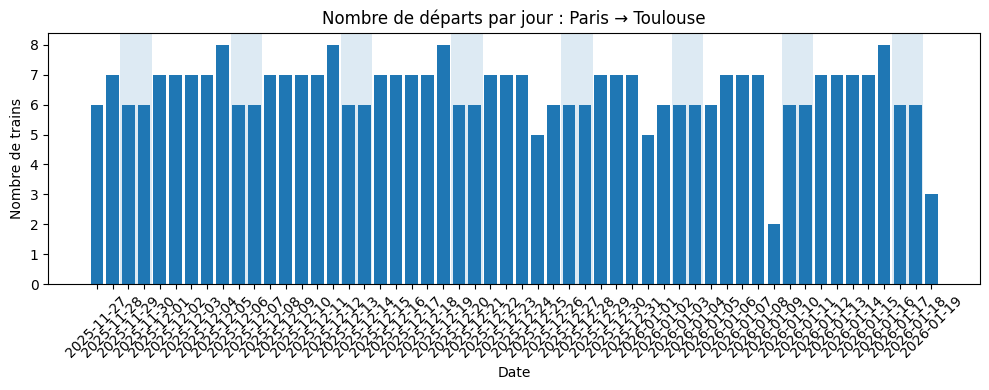

In [15]:
import matplotlib.pyplot as plt

# === 1. Filtrer uniquement les données réelles (scénario = 'reel') ===
# Les prévisions n’indiquent pas les départs réellement effectués.
df_reel = trains_all[trains_all["scenario"] == "reel"]

# === 2. Extraire la liste des destinations (en principe 12 villes) ===
destinations = df_reel["destination"].unique()

# === 3. Générer un graphique pour chaque destination ===
for dest in destinations:
    
    # Sélectionner uniquement les trains allant vers cette destination
    df_city = df_reel[df_reel["destination"] == dest]

    # Compter le nombre de trains par date
    count_by_date = (
        df_city.groupby("date")["Train"]
        .count()
        .sort_index()
    )

    # === 4. Création du graphique en barres ===
    # === Création explicite de la figure et de l'axe ===
    fig, ax = plt.subplots(figsize=(10, 4))

    # Axe des x = positions (0, 1, 2, ...)
    x = range(len(count_by_date.index))

    # Barres
    ax.bar(x, count_by_date.values)

    # Labels de dates
    ax.set_xticks(list(x))
    ax.set_xticklabels(count_by_date.index.astype(str), rotation=45)

    # Surligner les week-ends
    surligner_weekends(ax, count_by_date.index)

    # Titres et labels
    ax.set_title(f"Nombre de départs par jour : Paris → {dest}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de trains")

    plt.tight_layout()
    plt.show()


date
2025-11-27     59
2025-11-28     60
2025-11-29     24
2025-11-30     14
2025-12-01     34
2025-12-02     44
2025-12-03     34
2025-12-04     36
2025-12-05     54
2025-12-06     20
2025-12-07     20
2025-12-08     56
2025-12-09     35
2025-12-10     26
2025-12-11     19
2025-12-12     45
2025-12-13     19
2025-12-14     44
2025-12-15     44
2025-12-16     24
2025-12-17     31
2025-12-18     44
2025-12-19     37
2025-12-20     27
2025-12-21     20
2025-12-22     29
2025-12-23     33
2025-12-24     37
2025-12-25     46
2025-12-26     33
2025-12-27     26
2025-12-28     58
2025-12-29     46
2025-12-30     38
2025-12-31     31
2026-01-01     33
2026-01-02     26
2026-01-03     41
2026-01-04     53
2026-01-05     85
2026-01-06    121
2026-01-07    125
2026-01-08    100
2026-01-09     97
2026-01-10     45
2026-01-11     67
2026-01-12     42
2026-01-13     60
2026-01-14     33
2026-01-15     50
2026-01-16     33
2026-01-17      8
2026-01-18     20
2026-01-19     39
Name: en_retard, dtype:

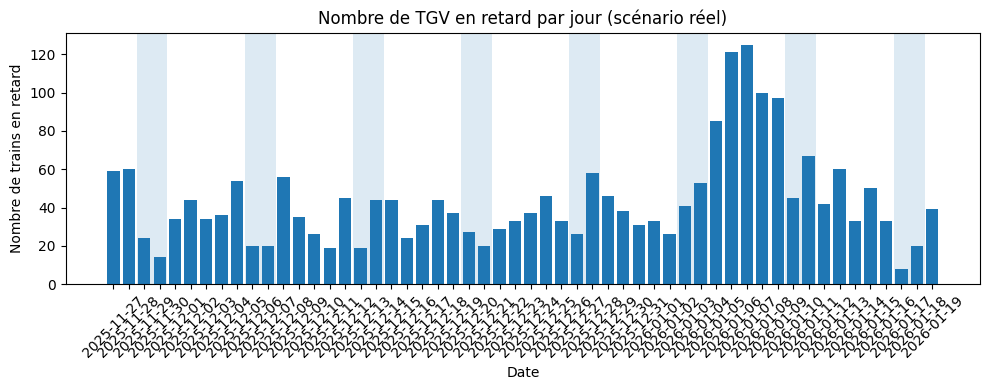

In [16]:
# === 1. Filtrer les données réelles (scénario = 'reel') ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Créer une variable booléenne indiquant si le train est en retard ===
# Hypothèse : tout train avec une colonne 'Statut' non vide est considéré "en retard".
df_reel["en_retard"] = df_reel["Statut"].notna()

# (Optionnel) Si vous voulez compter uniquement les retards "SIGNIFICANT_DELAYS",
# vous pouvez utiliser plutôt :
# df_reel["en_retard"] = df_reel["Statut"].eq("SIGNIFICANT_DELAYS")

# === 3. Calculer le nombre de trains en retard par jour ===
retards_par_jour = (
    df_reel.groupby("date")["en_retard"]
    .sum()          # somme des True → nombre de trains en retard
    .sort_index()   # trier par date
)

# Afficher la série pour vérifier
print(retards_par_jour)

# === 4. Représentation graphique : barres du nombre de trains en retard par jour ===
# === Création explicite de la figure et de l'axe ===
fig, ax = plt.subplots(figsize=(10, 4))

# Axe des x = positions (0, 1, 2, ...)
x = range(len(retards_par_jour.index))

# Barres
ax.bar(x, retards_par_jour.values)

# Labels de dates
ax.set_xticks(list(x))
ax.set_xticklabels(retards_par_jour.index.astype(str), rotation=45)

# Surligner les week-ends
surligner_weekends(ax, retards_par_jour.index)

# Titres et labels
ax.set_title("Nombre de TGV en retard par jour (scénario réel)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de trains en retard")

plt.tight_layout()
plt.show()


C:\Users\lly23\AppData\Local\Temp\ipykernel_23272\3559712554.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_delay.groupby(["date", "classe_retard_arrivee"])


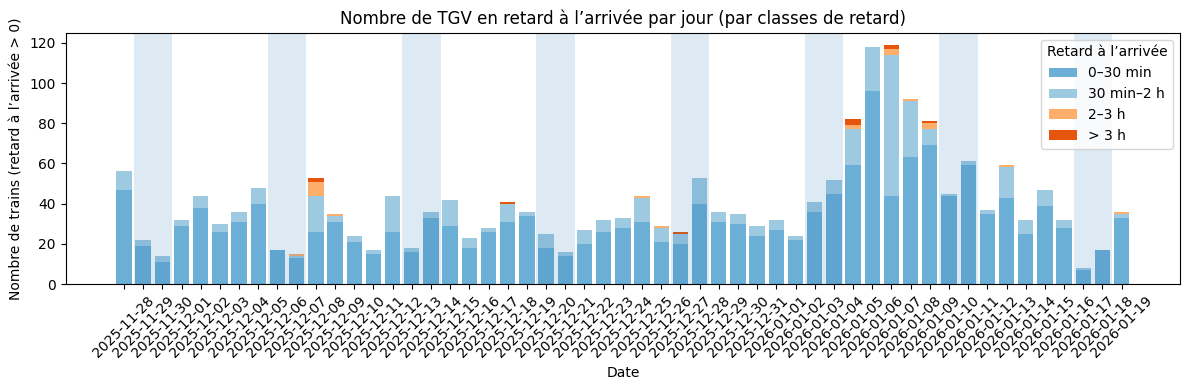

In [17]:
import numpy as np
import pandas as pd

df = df_merged.copy()

# 1) 修复 date 类型：确保可以用 .dt
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 2) 拼接日期 + 时间，生成 datetime
def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# 3) 跨午夜修正：arrivee < depart => arrivee + 1 day
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# 4) 到达延误（分钟）
df["retard_arrivee_min"] = (df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]).dt.total_seconds() / 60.0

# 1) 只关注“到达延误 > 0”
df_delay = df[df["retard_arrivee_min"] > 0].copy()

# 2) 分箱：0~30, 30~120, 120~180, >180（单位：分钟）
bins = [0, 30, 120, 180, np.inf]
labels = ["0–30 min", "30 min–2 h", "2–3 h", "> 3 h"]

df_delay["classe_retard_arrivee"] = pd.cut(
    df_delay["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# 3) 每天每类的数量（透视表）
counts = (
    df_delay.groupby(["date", "classe_retard_arrivee"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=labels, fill_value=0)  # 固定列顺序
    .sort_index()
)

# 4) 堆叠柱状图
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(counts.index))
bottom = np.zeros(len(counts.index))

# 你想要不同颜色 -> 这里显式给颜色（你也可以改）
colors = ["#6baed6", "#9ecae1", "#fdae6b", "#e6550d"]

for lab, col in zip(labels, colors):
    ax.bar(x, counts[lab].values, bottom=bottom, label=lab, color=col)
    bottom += counts[lab].values

ax.set_xticks(x)
ax.set_xticklabels(counts.index.astype(str), rotation=45)

# 高亮周末（沿用你已有函数）
surligner_weekends(ax, counts.index)

ax.set_title("Nombre de TGV en retard à l’arrivée par jour (par classes de retard)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de trains (retard à l’arrivée > 0)")
ax.legend(title="Retard à l’arrivée")

plt.tight_layout()
plt.show()

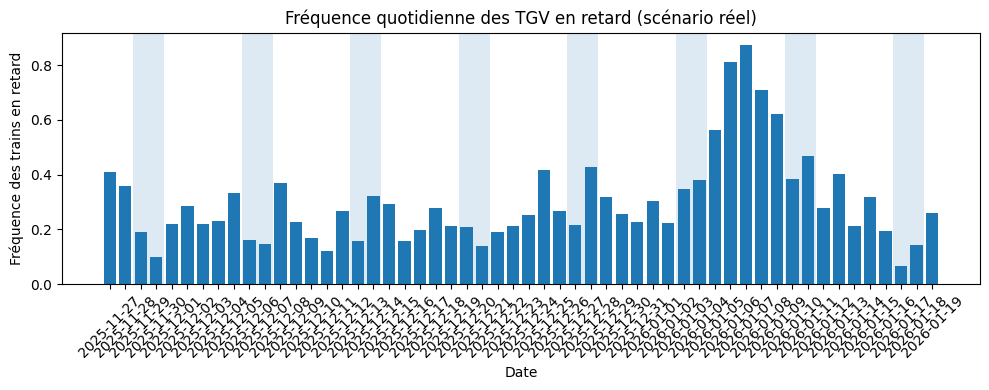

In [18]:
# === Calcul du nombre total de TGV par jour ===
total_trains_par_jour = (
    df_reel.groupby("date")["Train"]
    .count()
    .sort_index()
)
# === Calcul de la fréquence de retard par jour ===
frequence_retard_par_jour = retards_par_jour / total_trains_par_jour

# === Création explicite de la figure et de l'axe ===
fig, ax = plt.subplots(figsize=(10, 4))

# Axe des x = positions (0, 1, 2, ...)
x = range(len(frequence_retard_par_jour.index))

# Barres
ax.bar(x, frequence_retard_par_jour.values)

# Labels de dates
ax.set_xticks(list(x))
ax.set_xticklabels(frequence_retard_par_jour.index.astype(str), rotation=45)

# Surligner les week-ends
surligner_weekends(ax, frequence_retard_par_jour.index)

# Titres et labels
ax.set_title("Fréquence quotidienne des TGV en retard (scénario réel)")
ax.set_xlabel("Date")
ax.set_ylabel("Fréquence des trains en retard")

plt.tight_layout()
plt.show()

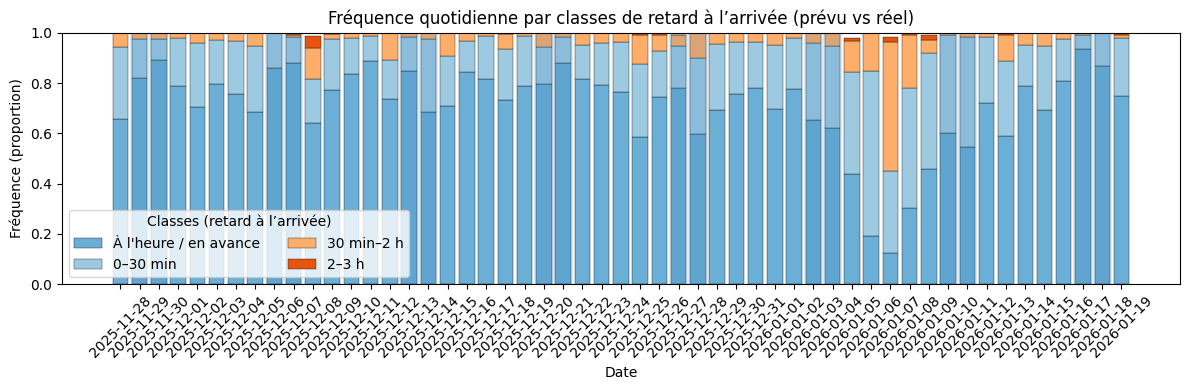

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Copier df_merged et assurer le type datetime pour la colonne date ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# === 2. Construire des datetime (date + heure) pour départ/arrivée (prévu/réel) ===
def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# === 3. Corriger les arrivées après minuit (arrivée < départ => +1 jour) ===
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# === 4. Calculer le retard à l'arrivée (en minutes) ===
df["retard_arrivee_min"] = (df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]).dt.total_seconds() / 60.0

# === 5. Classer le retard à l'arrivée par tranches (incluant "à l'heure / en avance") ===
bins = [-np.inf, 0, 30, 120, 180, np.inf]
labels = ["À l'heure / en avance", "0–30 min", "30 min–2 h", "2–3 h", "> 3 h"]

df["classe_retard_arrivee"] = pd.cut(
    df["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# === 6. Compter par jour et par classe (puis convertir en fréquences) ===
counts = (
    df.groupby(["date", "classe_retard_arrivee"], observed=True)  # observed=True pour éviter le FutureWarning
    .size()
    .unstack(fill_value=0)
    .reindex(columns=labels, fill_value=0)
    .sort_index()
)

# Fréquence = proportion sur le total de trains du jour
freq = counts.div(counts.sum(axis=1), axis=0)

# === 7. Tracer un histogramme empilé en fréquences ===
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(freq.index))
bottom = np.zeros(len(freq.index))

for lab, col in zip(labels, colors):
    ax.bar(x, freq[lab].values, bottom=bottom, label=lab, color=col, edgecolor="black", linewidth=0.25)
    bottom += freq[lab].values

ax.set_xticks(x)
ax.set_xticklabels(freq.index.strftime("%Y-%m-%d"), rotation=45)  # DatetimeIndex -> strftime() direct

surligner_weekends(ax, freq.index)

ax.set_title("Fréquence quotidienne par classes de retard à l’arrivée (prévu vs réel)")
ax.set_xlabel("Date")
ax.set_ylabel("Fréquence (proportion)")
ax.set_ylim(0, 1)
ax.legend(title="Classes (retard à l’arrivée)", ncols=2)

plt.tight_layout()
plt.show()

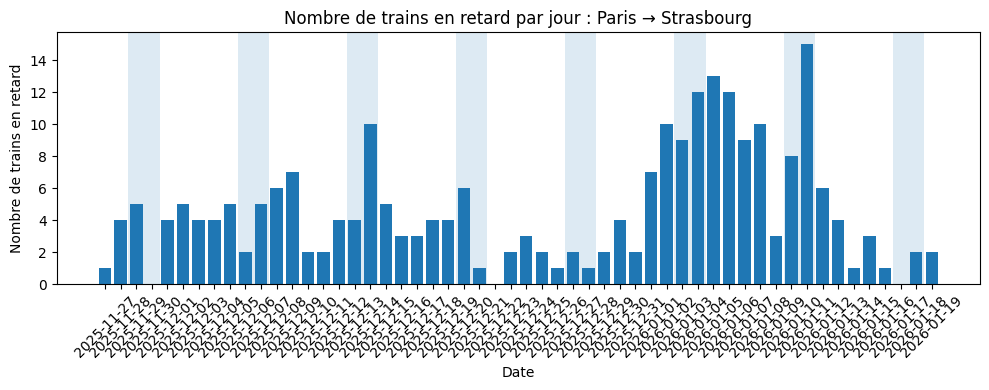

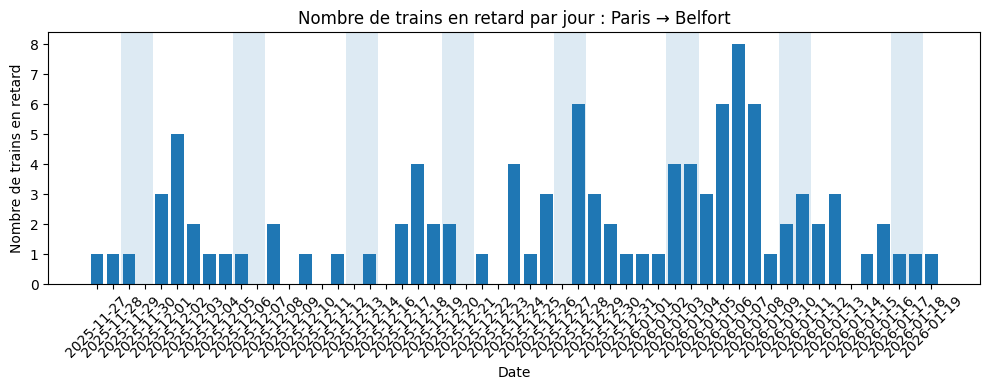

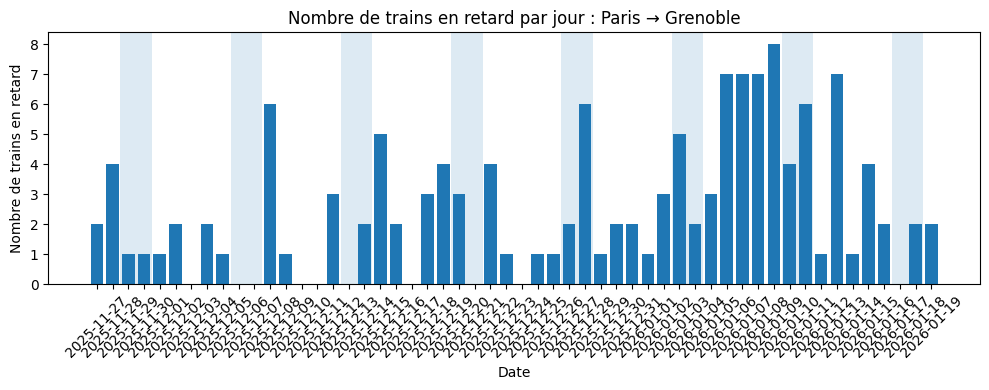

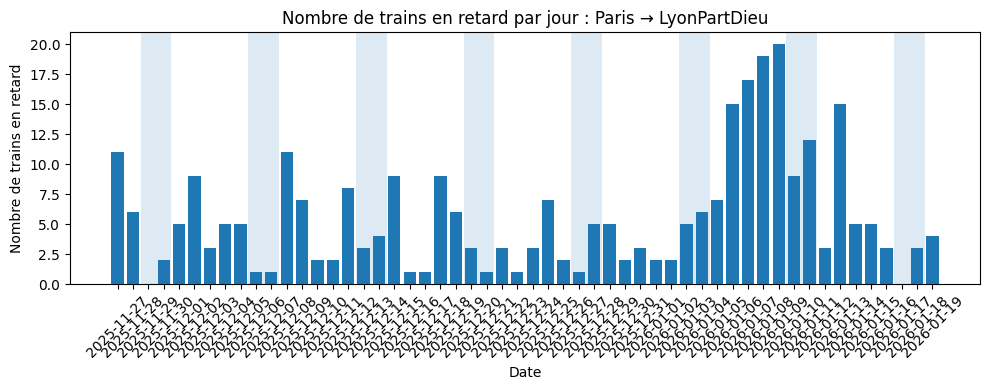

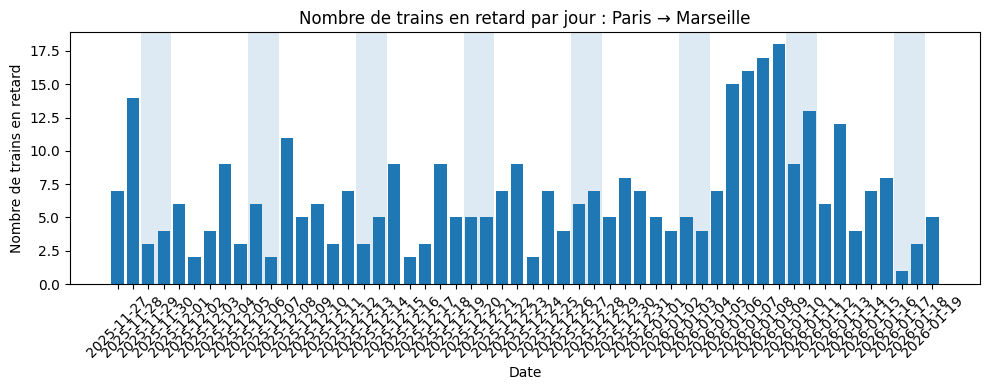

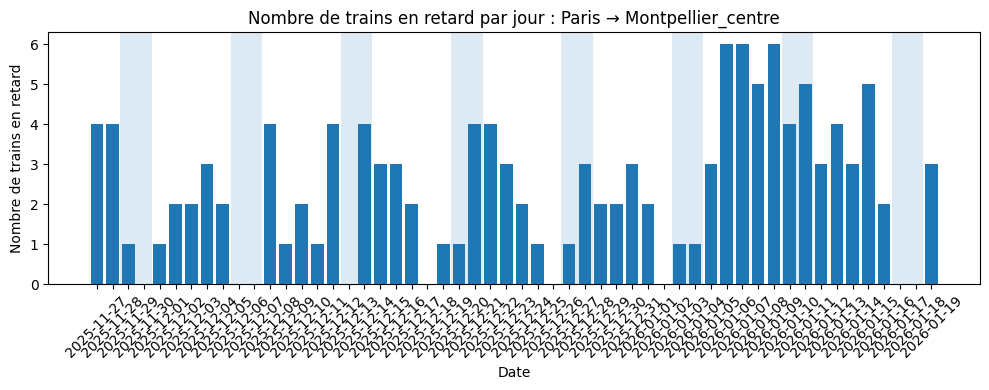

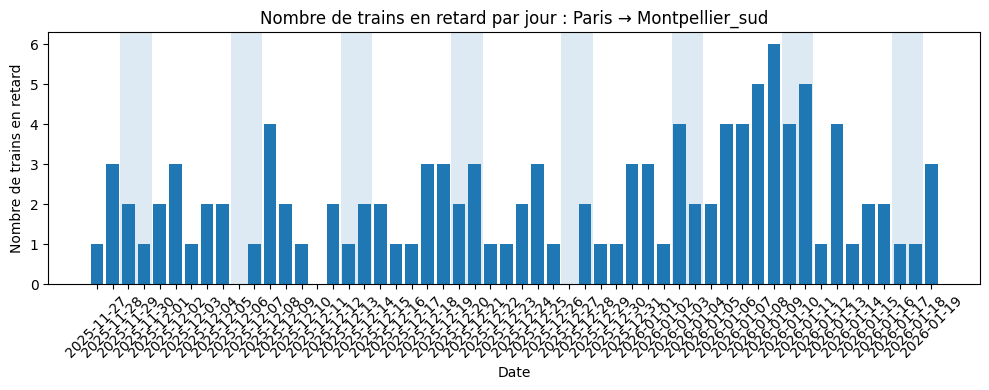

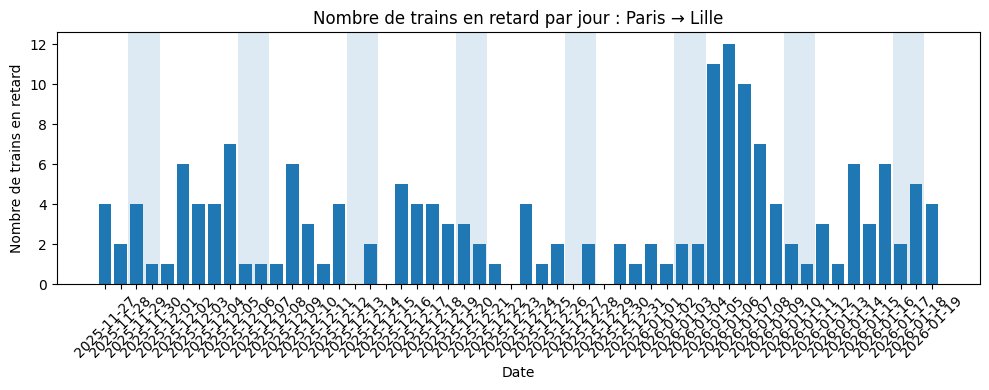

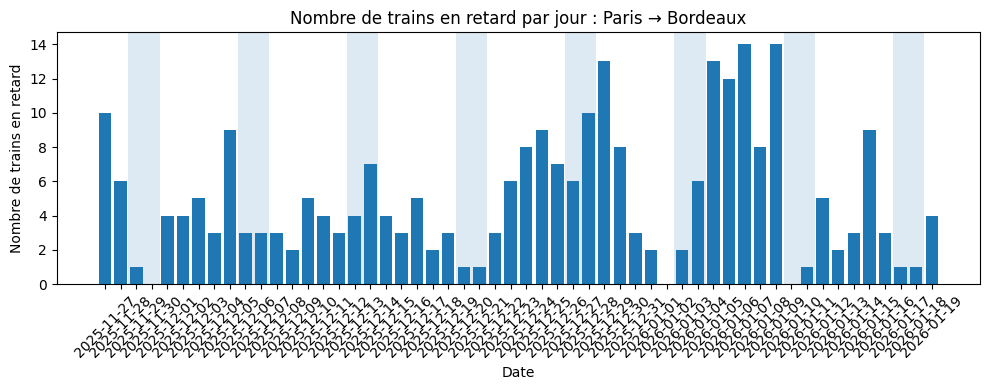

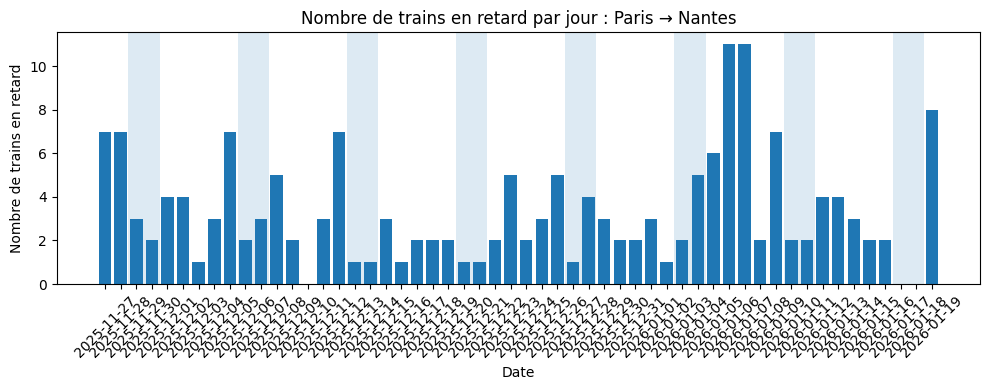

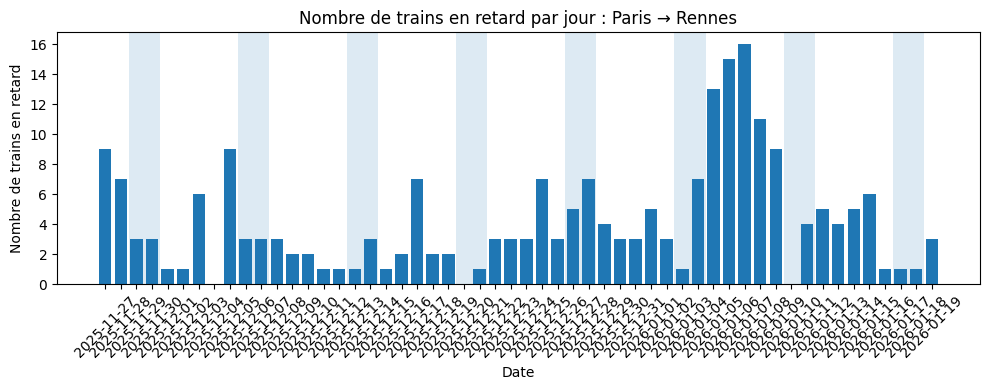

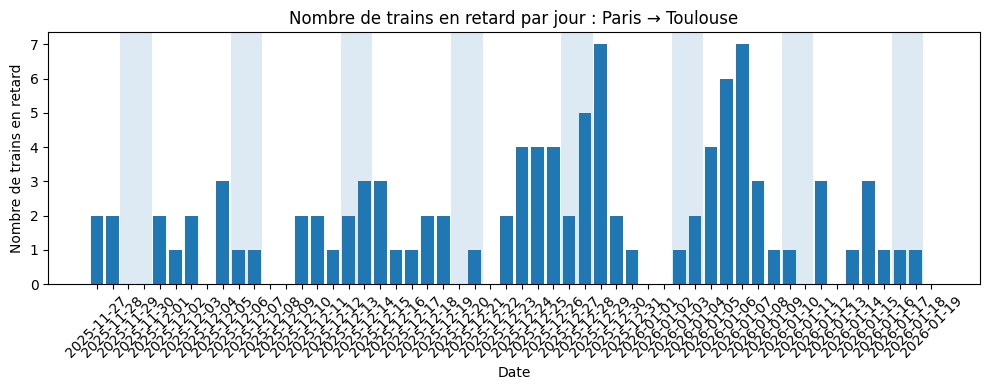

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir ce qu'est un train "en retard" ===
# Hypothèse : toute valeur non vide dans 'Statut' = retard.
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Extraire la liste des destinations ===
destinations = df_reel["destination"].unique()

# === 4. Générer un graphique pour chaque destination ===
for dest in destinations:
    
    # Sélectionner les données correspondant à cette ville
    df_city = df_reel[df_reel["destination"] == dest]

    # Calculer le nombre de trains en retard par jour
    retards_city = (
        df_city.groupby("date")["en_retard"]
        .sum()
        .sort_index()
    )

    # === 5. Création du graphique ===
    # === Création explicite de la figure et de l'axe ===
    fig, ax = plt.subplots(figsize=(10, 4))

    # Axe des x = positions (0, 1, 2, ...)
    x = range(len(retards_city.index))

    # Barres
    ax.bar(x, retards_city.values)

    # Labels de dates
    ax.set_xticks(list(x))
    ax.set_xticklabels(retards_city.index.astype(str), rotation=45)

    # Surligner les week-ends
    surligner_weekends(ax, retards_city.index)

    # Titres et labels
    ax.set_title(f"Nombre de trains en retard par jour : Paris → {dest}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de trains en retard")

    plt.tight_layout()
    plt.show()


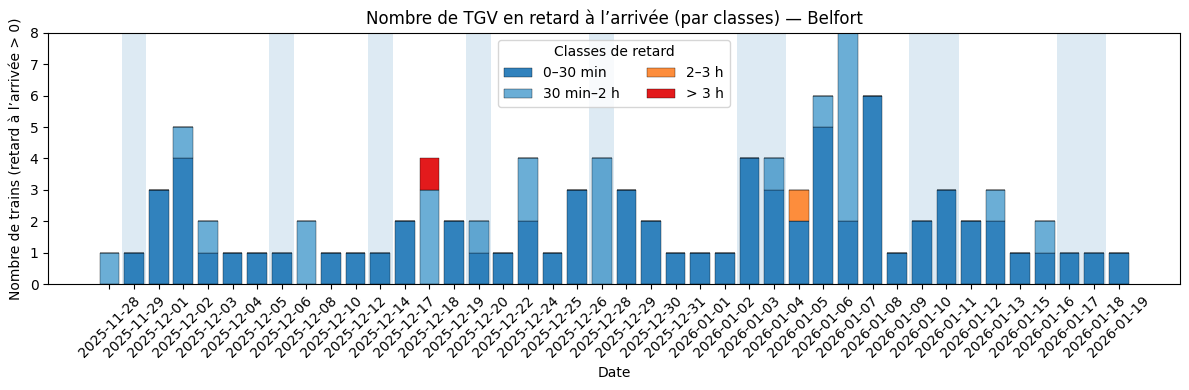

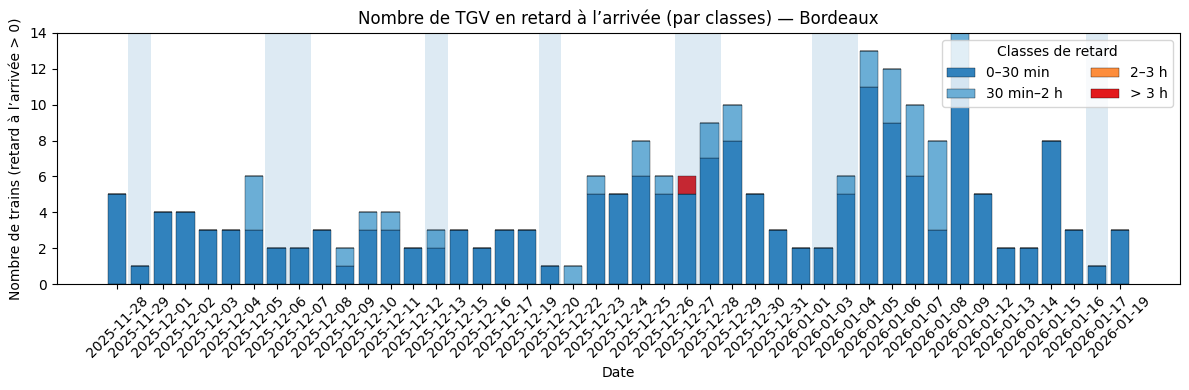

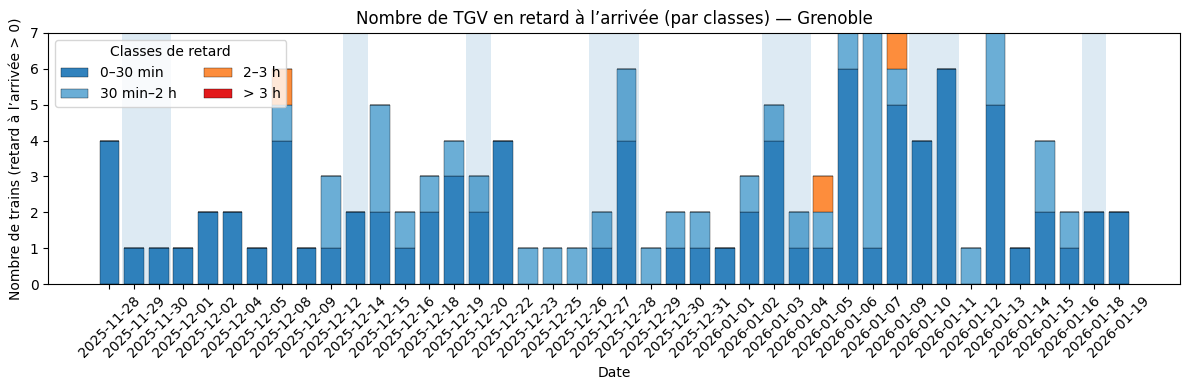

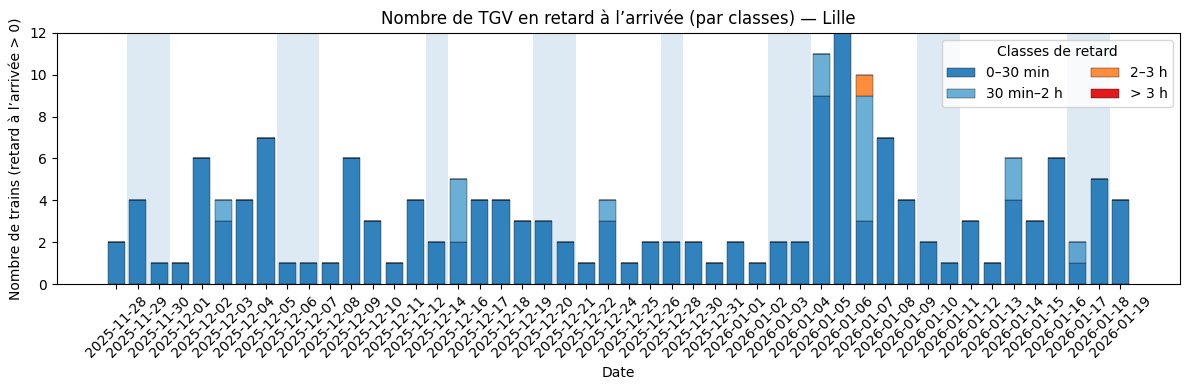

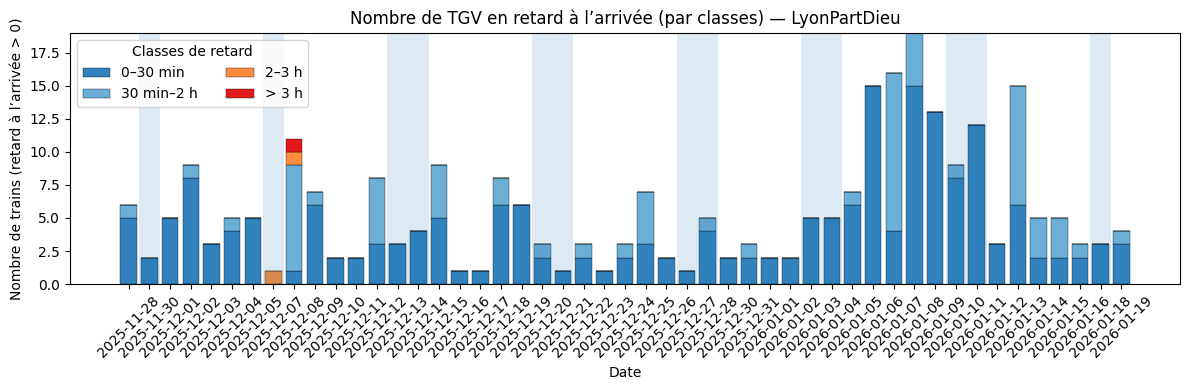

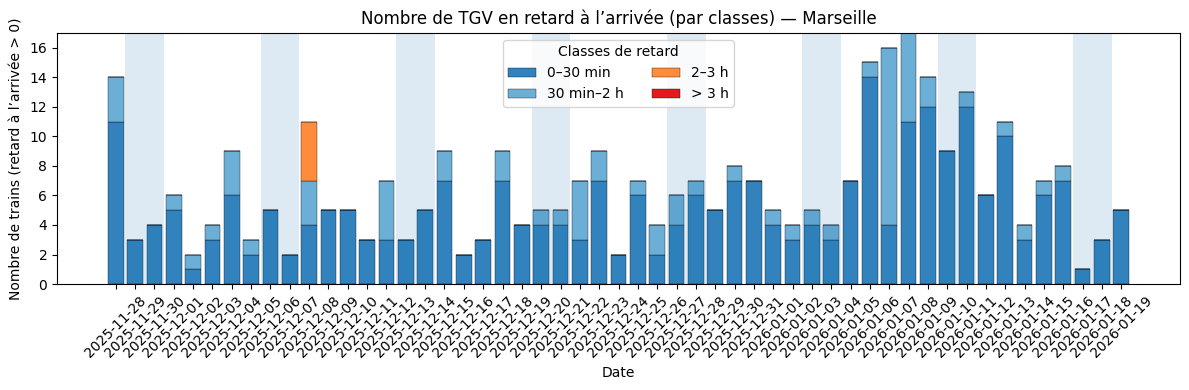

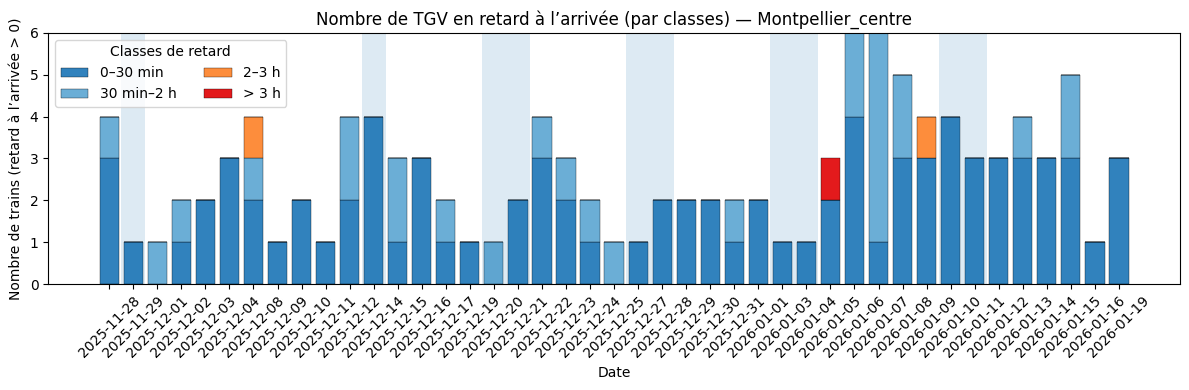

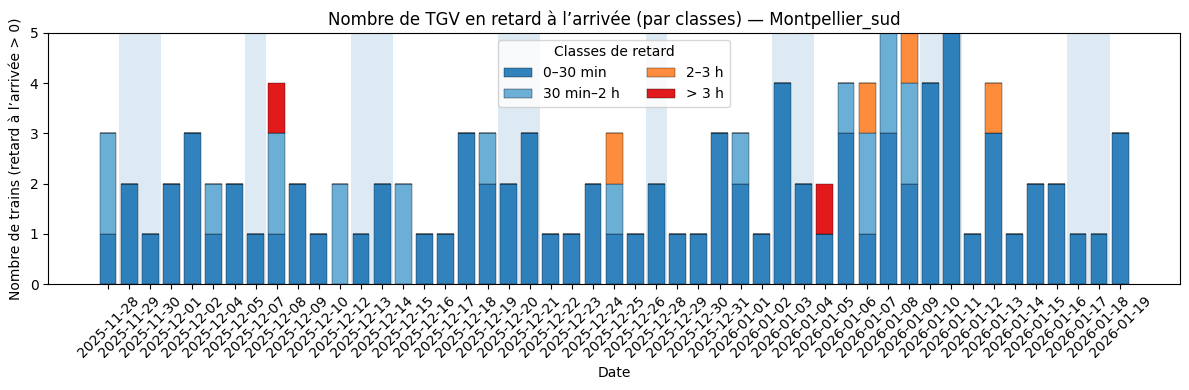

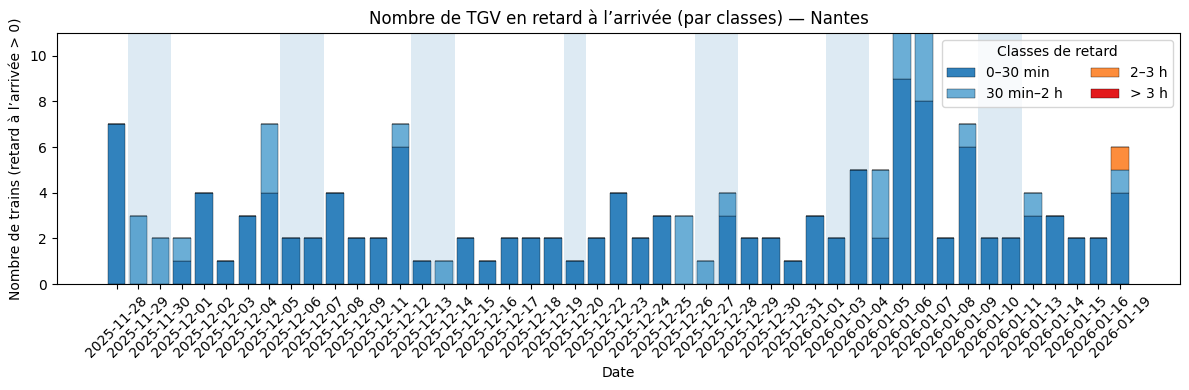

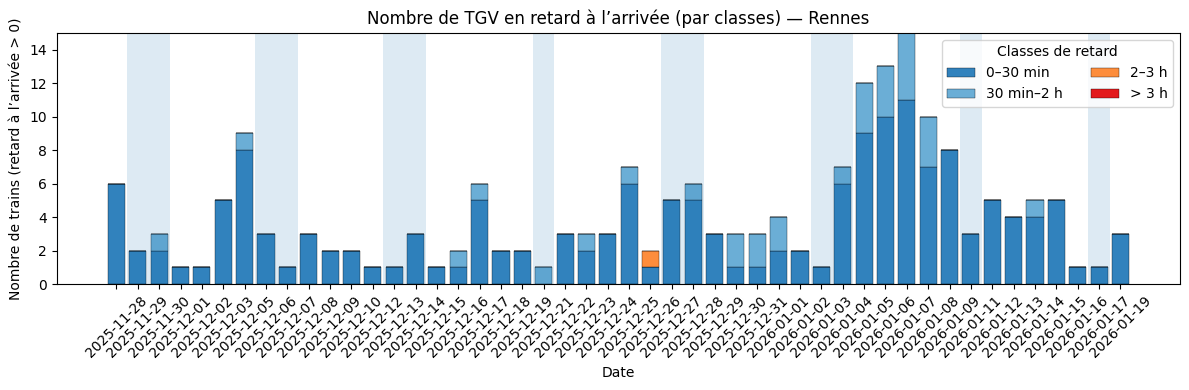

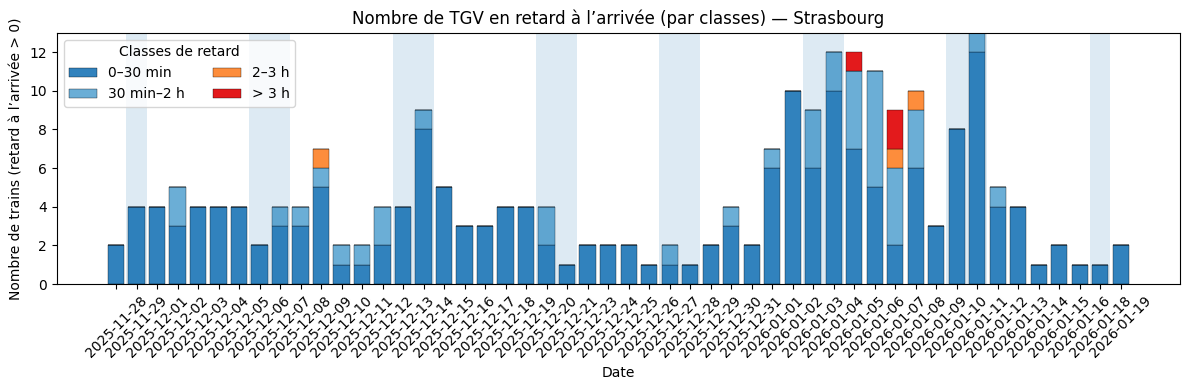

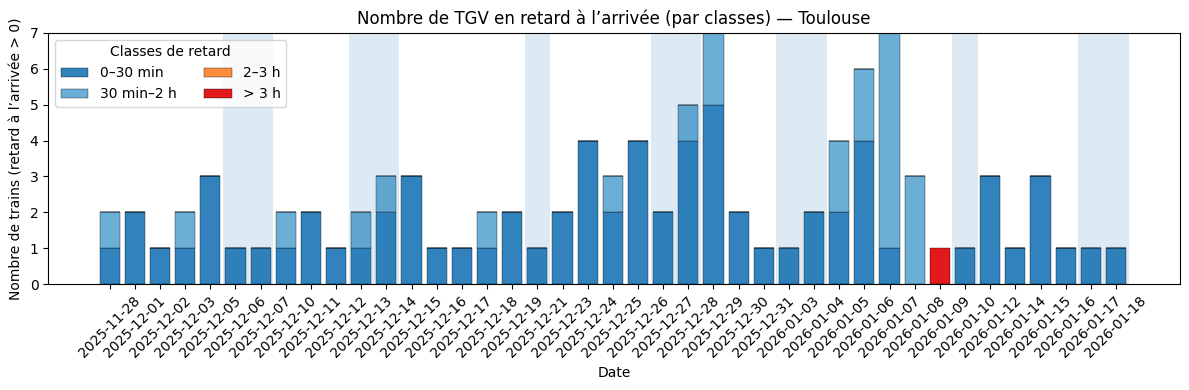

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Préparer les données : retard à l'arrivée et classes (sans "à l'heure") ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# Correction des arrivées après minuit
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# Retard à l'arrivée (en minutes)
df["retard_arrivee_min"] = (
    df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# === 2. Filtrer : uniquement les trains avec retard à l'arrivée > 0 ===
df_delay = df[df["retard_arrivee_min"] > 0].copy()

# === 3. Définir les classes de retard (4 classes) ===
bins = [0, 30, 120, 180, np.inf]
labels = ["0–30 min", "30 min–2 h", "2–3 h", "> 3 h"]

df_delay["classe_retard_arrivee"] = pd.cut(
    df_delay["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# Palette de couleurs (évite les bleus trop clairs sur fond week-end)
colors = {
    "0–30 min": "#3182bd",      # bleu foncé
    "30 min–2 h": "#6baed6",    # bleu moyen
    "2–3 h": "#fd8d3c",         # orange
    "> 3 h": "#e31a1c",         # rouge
}

# === 4. Boucle sur chaque destination : diagramme en barres empilées (fréquences absolues) ===
for destination in sorted(df_delay["destination"].dropna().unique()):

    df_dest = df_delay[df_delay["destination"] == destination]

    # Comptage par jour et par classe (uniquement trains en retard à l'arrivée)
    counts = (
        df_dest
        .groupby(["date", "classe_retard_arrivee"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
        .sort_index()
    )

    # Optionnel : ignorer les destinations sans aucun retard (sécurité)
    if counts.to_numpy().sum() == 0:
        continue

    # Tracé
    fig, ax = plt.subplots(figsize=(12, 4))

    x = np.arange(len(counts.index))
    bottom = np.zeros(len(counts.index))

    for lab in labels:
        ax.bar(
            x,
            counts[lab].values,
            bottom=bottom,
            label=lab,
            color=colors[lab],
            edgecolor="black",
            linewidth=0.25
        )
        bottom += counts[lab].values

    ax.set_xticks(x)
    ax.set_xticklabels(counts.index.strftime("%Y-%m-%d"), rotation=45)

    # Surligner les week-ends (fonction existante)
    surligner_weekends(ax, counts.index)

    ax.set_title(f"Nombre de TGV en retard à l’arrivée (par classes) — {destination}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de trains (retard à l’arrivée > 0)")
    ax.legend(title="Classes de retard", ncols=2)

    plt.tight_layout()
    plt.show()



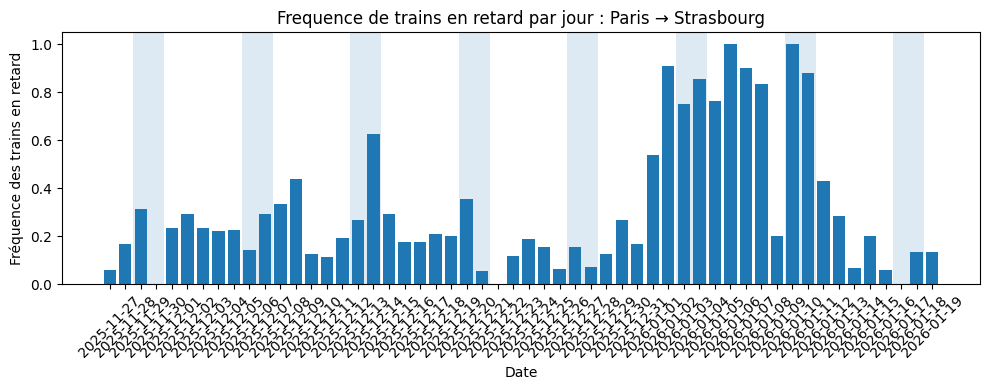

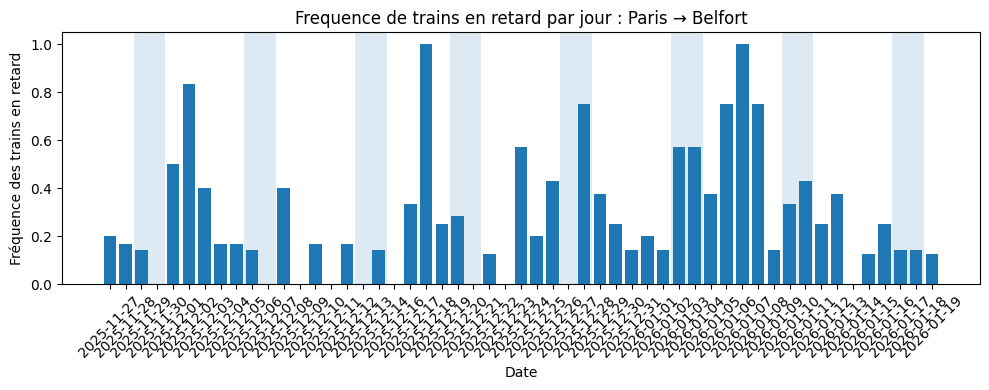

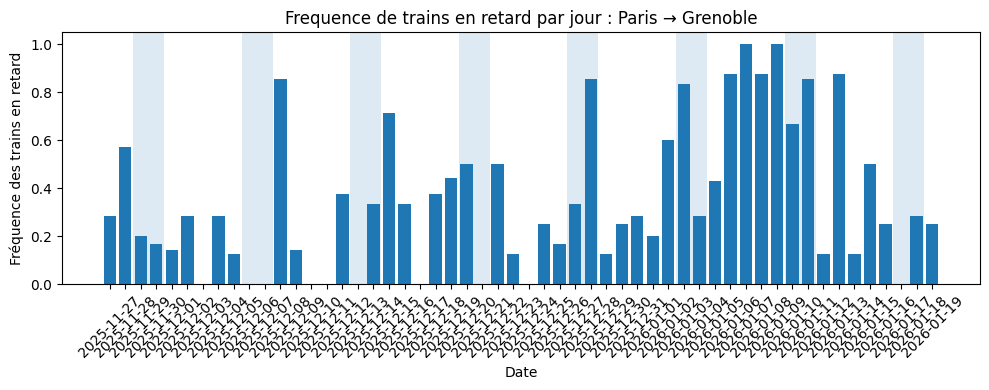

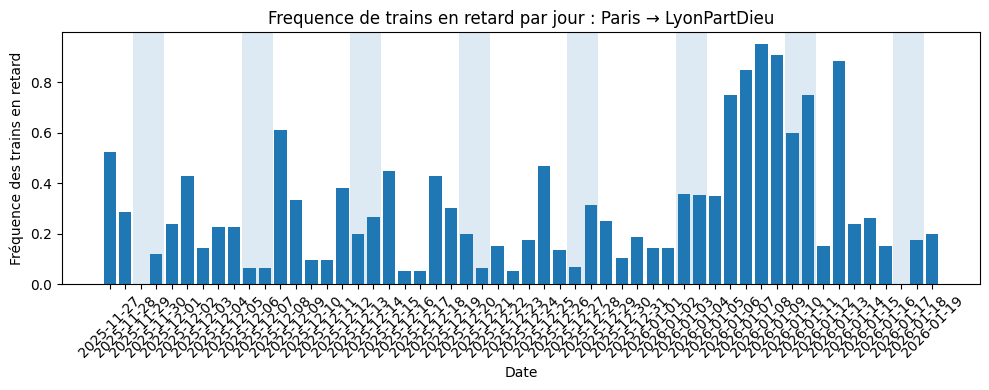

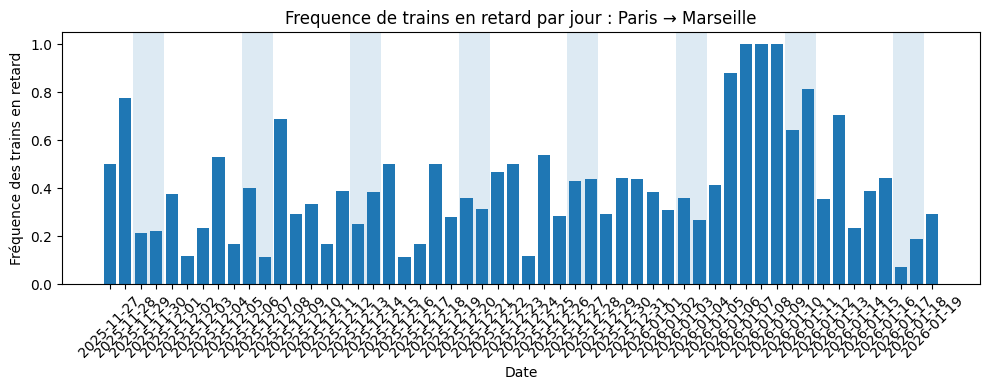

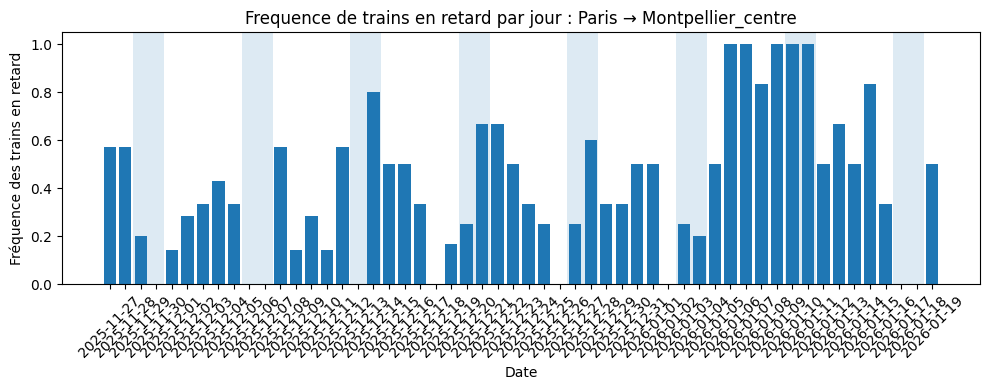

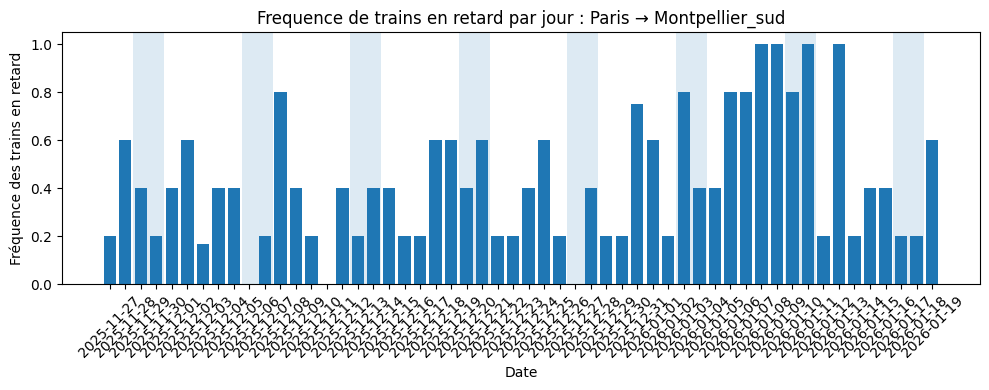

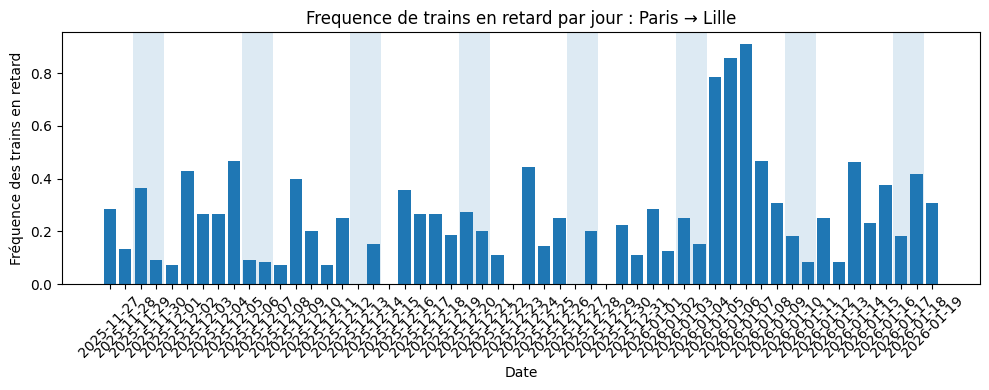

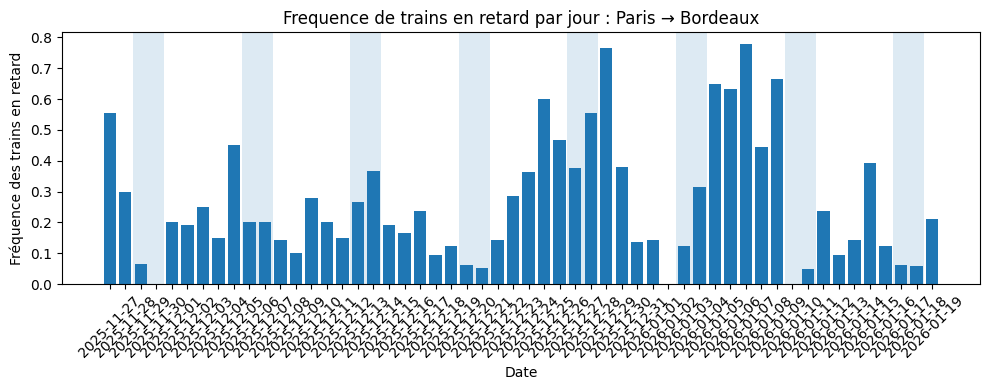

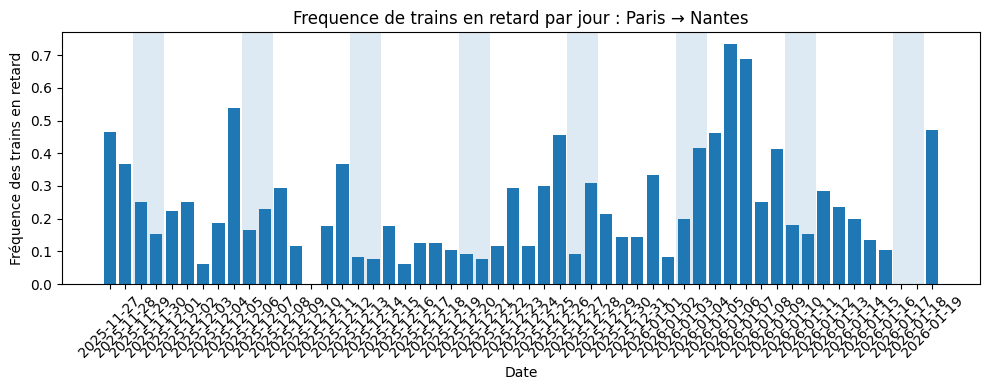

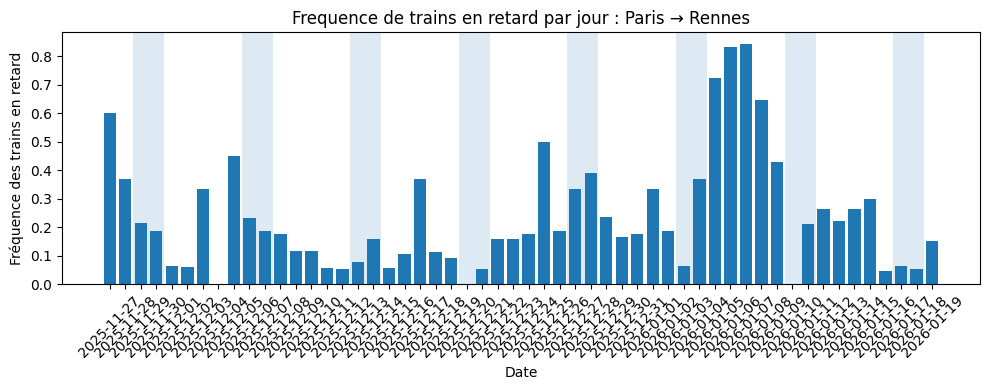

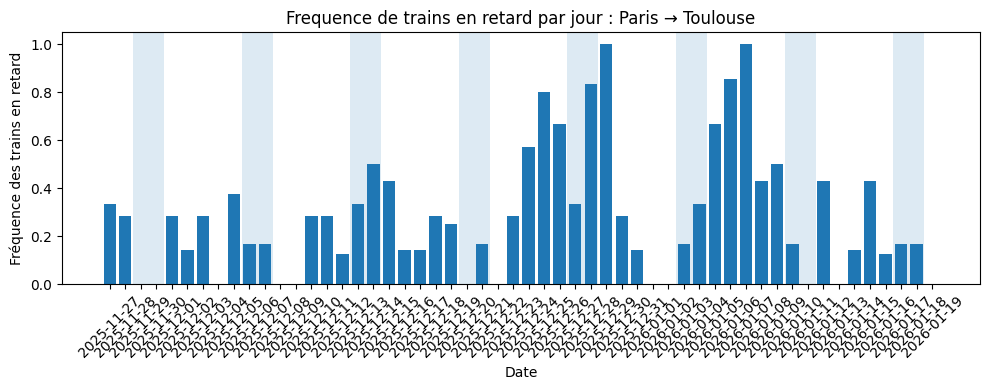

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir ce qu'est un train "en retard" ===
# Hypothèse : toute valeur non vide dans 'Statut' = retard.
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Extraire la liste des destinations ===
destinations = df_reel["destination"].unique()

# === 4. Générer un graphique pour chaque destination ===
for dest in destinations:
    
    # Sélectionner les données correspondant à cette ville
    df_city = df_reel[df_reel["destination"] == dest]

    # Calculer le nombre de trains en retard par jour
    retards_city = (
        df_city.groupby("date")["en_retard"]
        .sum()
        .sort_index()
    )
    # Nombre total de trains par jour pour cette destination
    total_city = (
        df_city.groupby("date")["Train"]
        .count()
        .sort_index()
    )
    # Fréquence de retard par jour
    frequence_city = retards_city / total_city
    frequence_city = frequence_city.fillna(0)

    # === 5. Création du graphique ===
    # === Création explicite de la figure et de l'axe ===
    fig, ax = plt.subplots(figsize=(10, 4))

    # Axe des x = positions (0, 1, 2, ...)
    x = range(len(frequence_city.index))

    # Barres
    ax.bar(x, frequence_city.values)

    # Labels de dates
    ax.set_xticks(list(x))
    ax.set_xticklabels(frequence_city.index.astype(str), rotation=45)

    # Surligner les week-ends
    surligner_weekends(ax, frequence_city.index)

    # Titres et labels
    ax.set_title(f"Frequence de trains en retard par jour : Paris → {dest}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Fréquence des trains en retard")

    plt.tight_layout()
    plt.show()

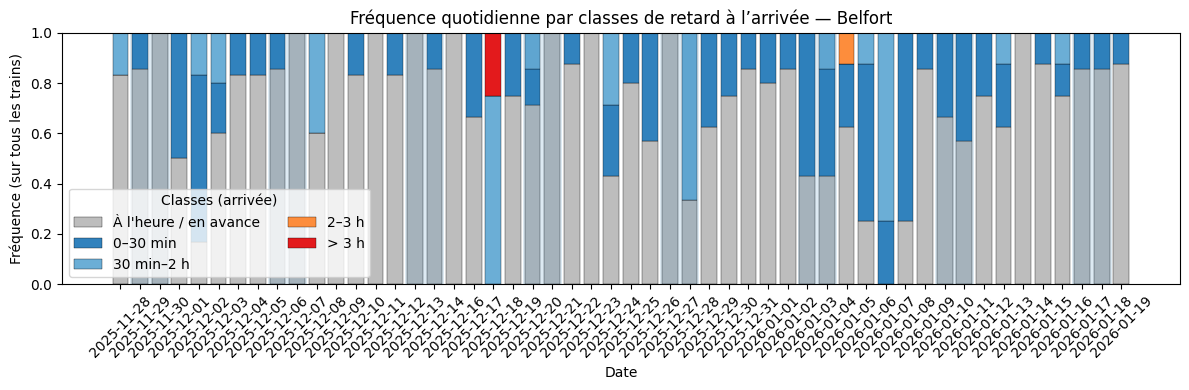

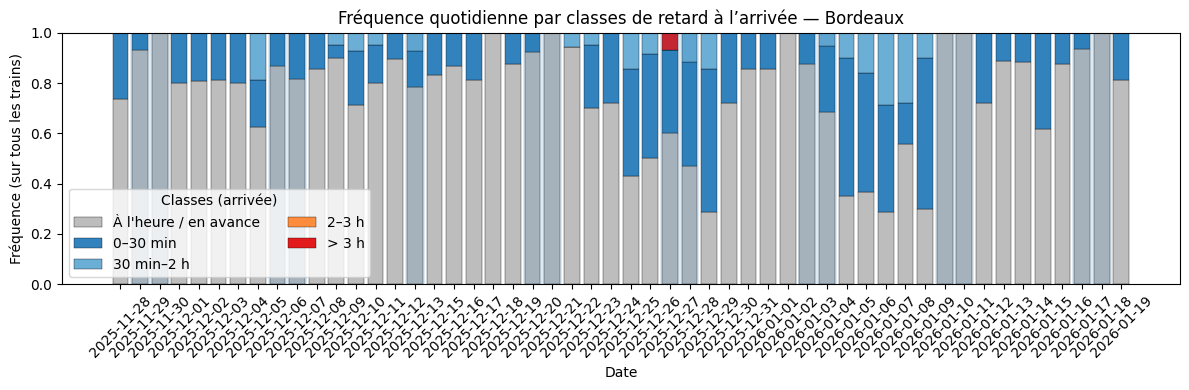

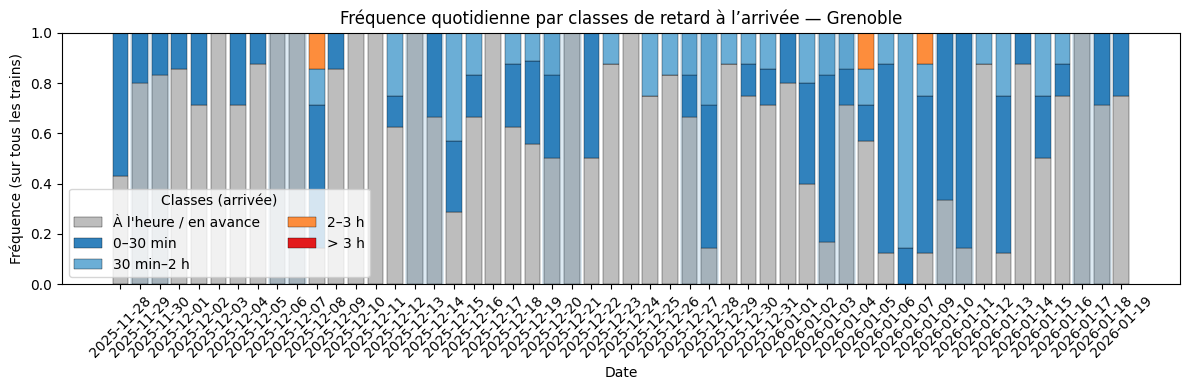

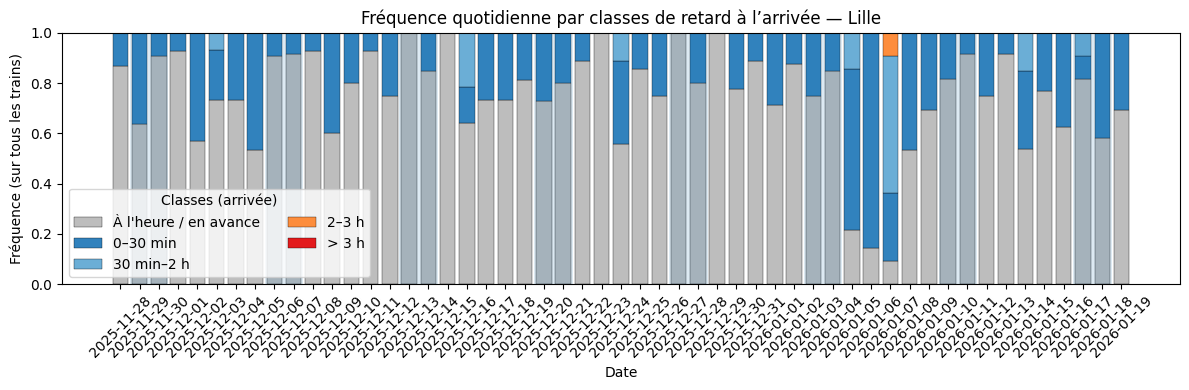

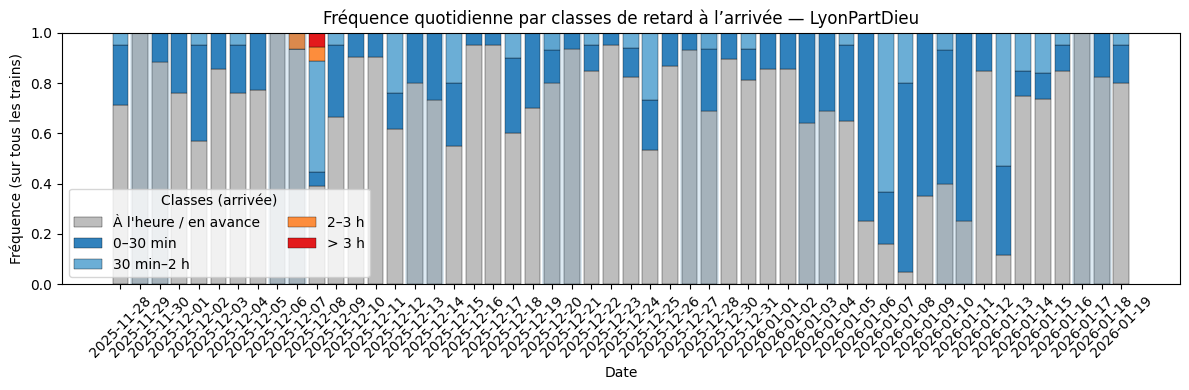

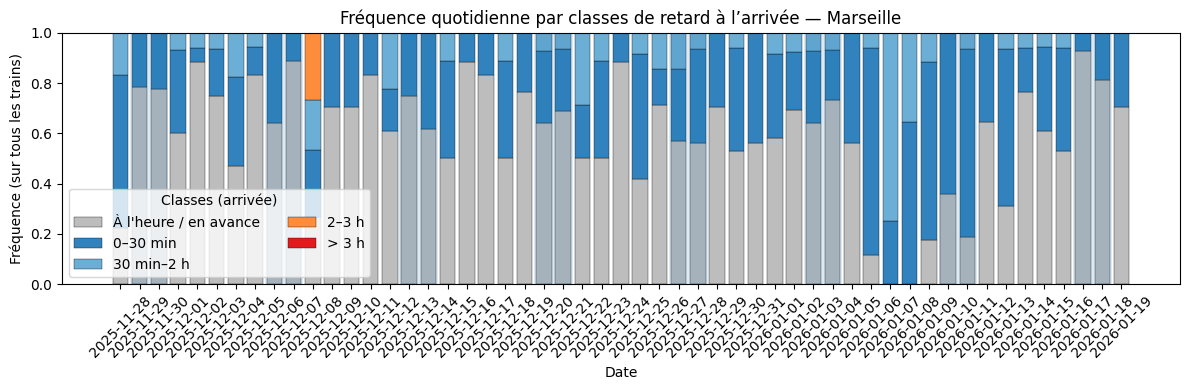

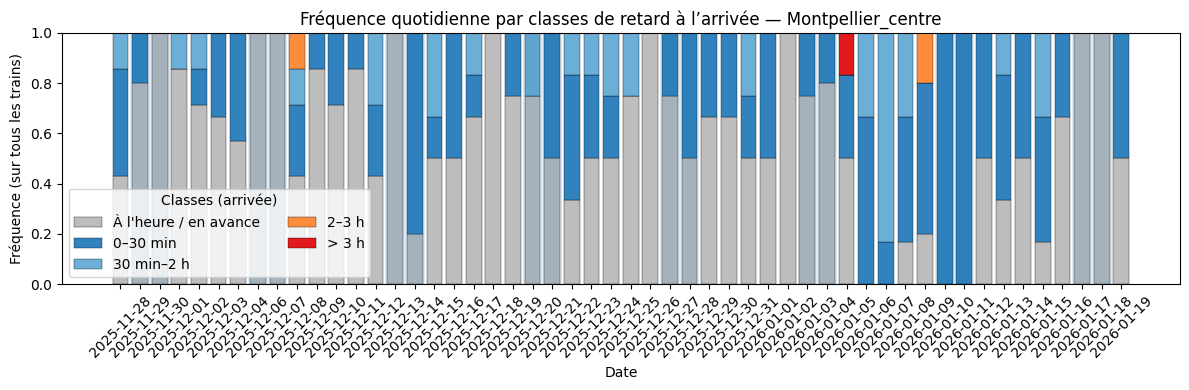

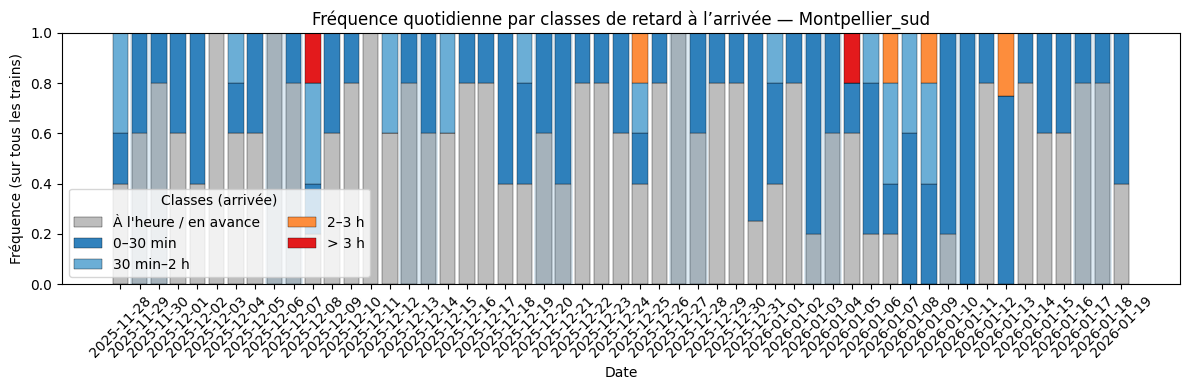

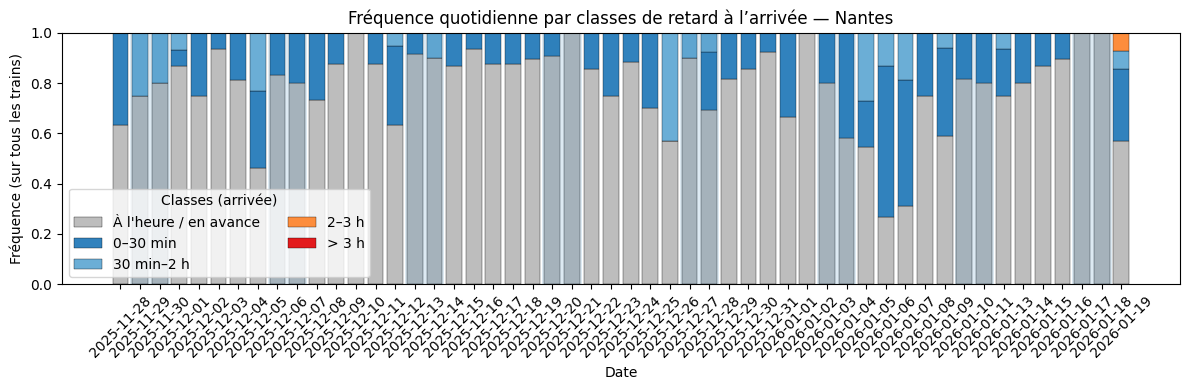

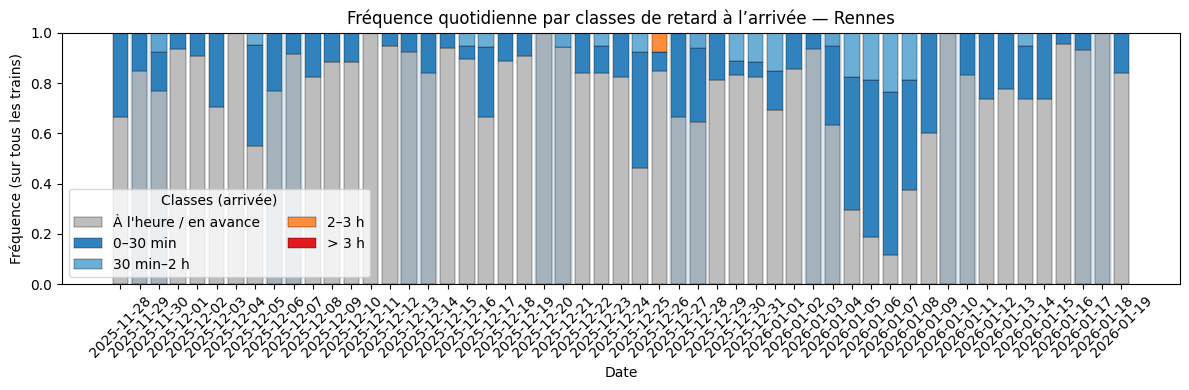

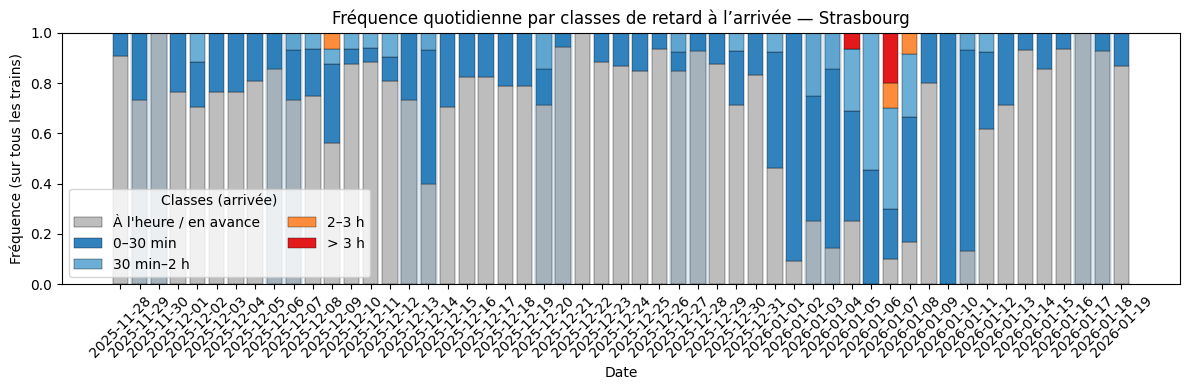

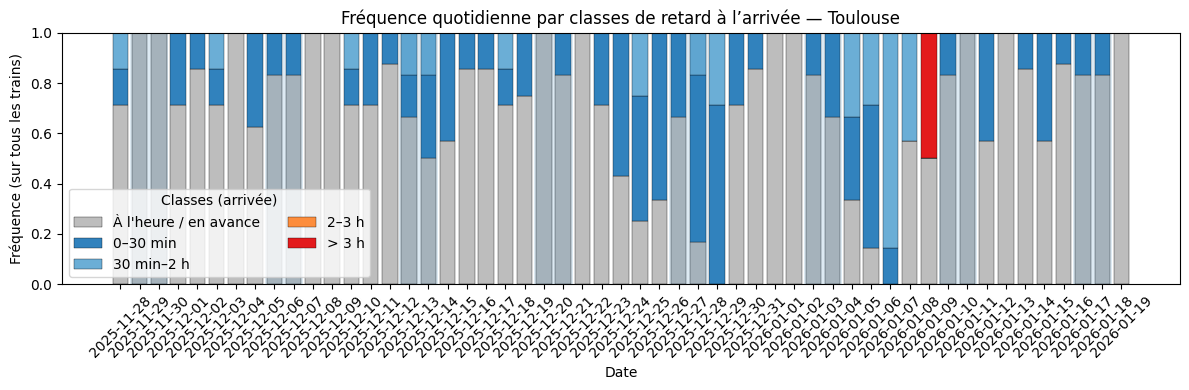

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Préparer les données : retard à l'arrivée et classes (incluant "à l'heure / en avance") ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# Correction des arrivées après minuit
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# Retard à l'arrivée (en minutes)
df["retard_arrivee_min"] = (
    df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# === 2. Définir les classes de retard (5 classes, incluant ≤0) ===
bins = [-np.inf, 0, 30, 120, 180, np.inf]
labels = ["À l'heure / en avance", "0–30 min", "30 min–2 h", "2–3 h", "> 3 h"]

df["classe_retard_arrivee"] = pd.cut(
    df["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Palette de couleurs (gris pour "à l'heure", puis bleu->orange->rouge)
colors = {
    "À l'heure / en avance": "#bdbdbd",
    "0–30 min": "#3182bd",
    "30 min–2 h": "#6baed6",
    "2–3 h": "#fd8d3c",
    "2–3 h": "#fd8d3c",
    "> 3 h": "#e31a1c",
}

# (Optionnel) Corriger une éventuelle duplication de clé (sécurité)
colors["2–3 h"] = "#fd8d3c"

# === 3. Boucle sur chaque destination : fréquences par classes (sur tous les trains) ===
for destination in sorted(df["destination"].dropna().unique()):

    df_dest = df[df["destination"] == destination]

    # Comptage par jour et par classe
    counts = (
        df_dest
        .groupby(["date", "classe_retard_arrivee"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
        .sort_index()
    )

    # Ignorer les destinations sans données (sécurité)
    if counts.to_numpy().sum() == 0:
        continue

    # Fréquence = proportion sur le total de trains du jour
    freq = counts.div(counts.sum(axis=1), axis=0)

    # === 4. Tracé du diagramme en barres empilées (fréquences) ===
    fig, ax = plt.subplots(figsize=(12, 4))

    x = np.arange(len(freq.index))
    bottom = np.zeros(len(freq.index))

    for lab in labels:
        ax.bar(
            x,
            freq[lab].values,
            bottom=bottom,
            label=lab,
            color=colors[lab],
            edgecolor="black",
            linewidth=0.25
        )
        bottom += freq[lab].values

    ax.set_xticks(x)
    ax.set_xticklabels(freq.index.strftime("%Y-%m-%d"), rotation=45)

    # Surligner les week-ends
    surligner_weekends(ax, freq.index)

    ax.set_title(f"Fréquence quotidienne par classes de retard à l’arrivée — {destination}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Fréquence (sur tous les trains)")
    ax.set_ylim(0, 1)
    ax.legend(title="Classes (arrivée)", ncols=2)

    plt.tight_layout()
    plt.show()


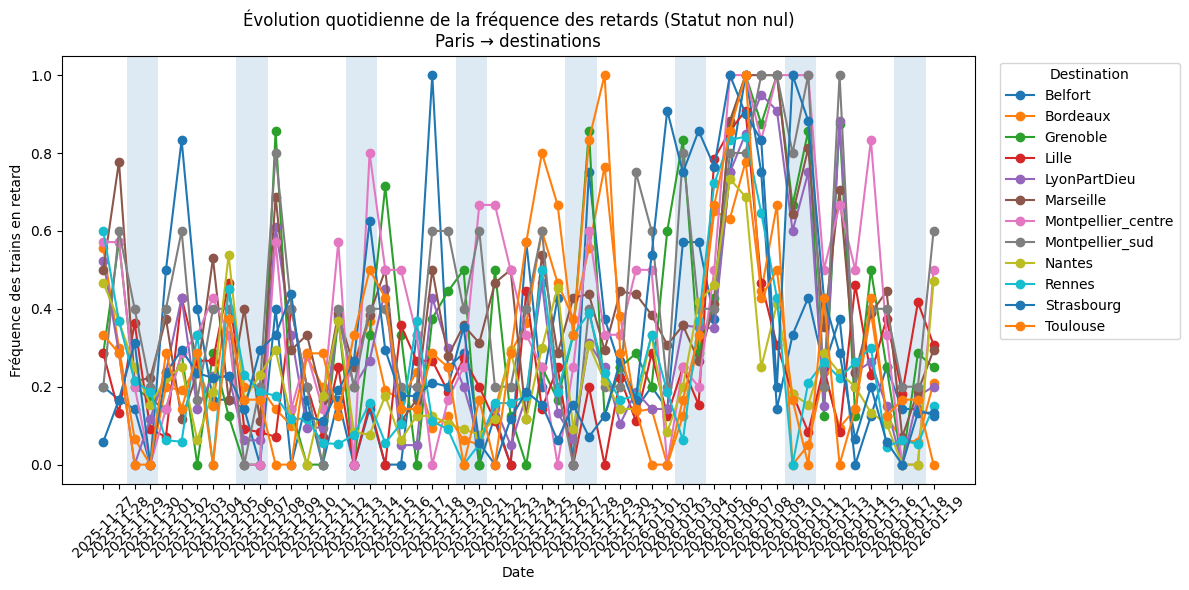

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Filtrer les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir l'indicateur de retard (Statut non nul) ===
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Calculer, pour chaque date et destination, le nombre total et le nombre en retard ===
agg = (
    df_reel.groupby(["date", "destination"])
    .agg(
        total_trains=("Train", "count"),
        trains_en_retard=("en_retard", "sum")
    )
    .reset_index()
)

# === 4. Calculer la fréquence quotidienne de retard ===
agg["frequence_retard"] = agg["trains_en_retard"] / agg["total_trains"]

# === 5. Mettre en forme en tableau (lignes = dates, colonnes = destinations) ===
table_freq = (
    agg.pivot(index="date", columns="destination", values="frequence_retard")
    .sort_index()
)

# (Optionnel) Remplacer les valeurs manquantes par 0 (jours sans trains)
table_freq = table_freq.fillna(0)

# === 6. Tracer une courbe par destination sur une seule figure ===
# === Création explicite de la figure et de l'axe ===
fig, ax = plt.subplots(figsize=(12, 6))

# Axe des x = positions (0, 1, 2, ...)
x = range(len(table_freq.index))

# Tracer une courbe par destination
for dest in table_freq.columns:
    ax.plot(x, table_freq[dest].values, marker="o", label=dest)

# Labels de dates
ax.set_xticks(list(x))
ax.set_xticklabels(table_freq.index.astype(str), rotation=45)

# Surligner les week-ends
surligner_weekends(ax, table_freq.index)

# Titres et légende
ax.set_title("Évolution quotidienne de la fréquence des retards (Statut non nul)\nParis → destinations")
ax.set_xlabel("Date")
ax.set_ylabel("Fréquence des trains en retard")
ax.legend(title="Destination", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir l'indicateur de retard ===
# Hypothèse : Statut non nul = train en retard
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Définir la période de vacances ===
debut_vacances = pd.to_datetime("2025-12-22").date()
fin_vacances = pd.to_datetime("2026-01-02").date()

# Variable booléenne : vacances / hors vacances
df_reel["vacances"] = df_reel["date"].between(debut_vacances, fin_vacances)

# === 4. Compter les effectifs pour le tableau de contingence ===

# Vacances
A = df_reel[(df_reel["vacances"]) & (df_reel["en_retard"])].shape[0]      # Vacances & retard
B = df_reel[(df_reel["vacances"]) & (~df_reel["en_retard"])].shape[0]     # Vacances & pas retard

# Hors vacances
C = df_reel[(~df_reel["vacances"]) & (df_reel["en_retard"])].shape[0]     # Hors vacances & retard
D = df_reel[(~df_reel["vacances"]) & (~df_reel["en_retard"])].shape[0]    # Hors vacances & pas retard

# === 5. Créer le tableau récapitulatif ===
table_contingence = pd.DataFrame(
    [[A, B],
     [C, D]],
    index=["Vacances", "Hors vacances"],
    columns=["Trains en retard", "Trains à l'heure"]
)

print("Tableau de contingence (vacances vs hors vacances) :")
print(table_contingence)


Tableau de contingence (vacances vs hors vacances) :
               Trains en retard  Trains à l'heure
Vacances                    436              1163
Hors vacances              1889              4291


In [26]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# === 1. Vérifier / récupérer le tableau de contingence ===
# Si vous avez déjà "table_contingence", vous pouvez directement l'utiliser.
# Sinon, vous pouvez le reconstruire à partir de A,B,C,D comme ci-dessous :
# table_contingence = pd.DataFrame(
#     [[A, B],
#      [C, D]],
#     index=["Vacances", "Hors vacances"],
#     columns=["Trains en retard", "Trains à l'heure"]
# )

print("=== Tableau de contingence ===")
print(table_contingence)

# === 2. Test du χ² d'indépendance ===
# Correction de continuité (Yates) : par défaut True pour les tableaux 2x2 dans SciPy.
# Vous pouvez mettre correction=False si vous préférez le χ² sans correction.
chi2, p_value, dof, expected = chi2_contingency(table_contingence.values, correction=True)

print("\n=== Test du χ² (indépendance) ===")
print(f"Chi2 = {chi2:.4f}")
print(f"ddl (degrés de liberté) = {dof}")
print(f"p-value = {p_value:.6g}")

# === 3. Effectifs attendus (expected counts) ===
expected_df = pd.DataFrame(
    expected,
    index=table_contingence.index,
    columns=table_contingence.columns
)

print("\n=== Effectifs attendus (sous H0 : indépendance) ===")
print(expected_df)

# === 4. Indicateurs d'effet (probabilités, différence, risque relatif) ===
# Extraire les effectifs observés
A = table_contingence.loc["Vacances", "Trains en retard"]
B = table_contingence.loc["Vacances", "Trains à l'heure"]
C = table_contingence.loc["Hors vacances", "Trains en retard"]
D = table_contingence.loc["Hors vacances", "Trains à l'heure"]

n_vac = A + B
n_hors = C + D

p_vac = A / n_vac if n_vac > 0 else np.nan
p_hors = C / n_hors if n_hors > 0 else np.nan

delta_p = p_vac - p_hors
rr = (p_vac / p_hors) if (p_hors not in [0, np.nan] and p_hors > 0) else np.nan

print("\n=== Probabilités de retard (fréquences) ===")
print(f"P(retard | vacances)      = {p_vac:.4f}  ({p_vac*100:.2f} %)")
print(f"P(retard | hors vacances) = {p_hors:.4f}  ({p_hors*100:.2f} %)")

print("\n=== Taille d'effet ===")
print(f"Différence Δp (vac - hors) = {delta_p:.4f}  ({delta_p*100:.2f} points de %)")
print(f"Risque relatif RR          = {rr:.4f}")

# === 5. Interprétation simple (seuil 5%) ===
alpha = 0.05
print("\n=== Conclusion (alpha = 0.05) ===")
if p_value < alpha:
    print("On rejette H0 : la probabilité de retard dépend significativement de la période (vacances vs hors vacances).")
else:
    print("On ne rejette pas H0 : aucune différence statistiquement significative détectée entre vacances et hors vacances.")


=== Tableau de contingence ===
               Trains en retard  Trains à l'heure
Vacances                    436              1163
Hors vacances              1889              4291

=== Test du χ² (indépendance) ===
Chi2 = 6.4423
ddl (degrés de liberté) = 1
p-value = 0.0111433

=== Effectifs attendus (sous H0 : indépendance) ===
               Trains en retard  Trains à l'heure
Vacances             477.911685       1121.088315
Hors vacances       1847.088315       4332.911685

=== Probabilités de retard (fréquences) ===
P(retard | vacances)      = 0.2727  (27.27 %)
P(retard | hors vacances) = 0.3057  (30.57 %)

=== Taille d'effet ===
Différence Δp (vac - hors) = -0.0330  (-3.30 points de %)
Risque relatif RR          = 0.8921

=== Conclusion (alpha = 0.05) ===
On rejette H0 : la probabilité de retard dépend significativement de la période (vacances vs hors vacances).


In [27]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir l'indicateur de retard ===
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Définir la période de vacances ===
debut_vacances = pd.to_datetime("2025-12-22").date()
fin_vacances = pd.to_datetime("2026-01-02").date()
df_reel["vacances"] = df_reel["date"].between(debut_vacances, fin_vacances)

# === 4. Fonction utilitaire : construire le tableau 2x2 pour une destination ===
def contingence_vacances(df):
    # Compter les effectifs
    A = df[(df["vacances"]) & (df["en_retard"])].shape[0]       # Vacances & retard
    B = df[(df["vacances"]) & (~df["en_retard"])].shape[0]      # Vacances & à l'heure
    C = df[(~df["vacances"]) & (df["en_retard"])].shape[0]      # Hors vacances & retard
    D = df[(~df["vacances"]) & (~df["en_retard"])].shape[0]     # Hors vacances & à l'heure

    table = np.array([[A, B],
                      [C, D]], dtype=int)
    return table, A, B, C, D

# === 5. Boucle sur les destinations ===
resultats = []
destinations = sorted(df_reel["destination"].dropna().unique())

for dest in destinations:
    df_dest = df_reel[df_reel["destination"] == dest].copy()

    table, A, B, C, D = contingence_vacances(df_dest)

    # Totaux par période
    n_vac = A + B
    n_hors = C + D

    # Probabilités (fréquences)
    p_vac = A / n_vac if n_vac > 0 else np.nan
    p_hors = C / n_hors if n_hors > 0 else np.nan
    delta_p = p_vac - p_hors if (not np.isnan(p_vac) and not np.isnan(p_hors)) else np.nan
    rr = (p_vac / p_hors) if (not np.isnan(p_vac) and not np.isnan(p_hors) and p_hors > 0) else np.nan

    # Test du χ² (avec correction de continuité de Yates pour 2x2)
    # Si une ligne/colonne est vide (aucun train), le test n'est pas applicable.
    if n_vac == 0 or n_hors == 0:
        chi2 = np.nan
        p_value = np.nan
        dof = np.nan
        min_expected = np.nan
    else:
        chi2, p_value, dof, expected = chi2_contingency(table, correction=True)
        min_expected = expected.min()

    resultats.append({
        "destination": dest,
        "A_vac_retard": A,
        "B_vac_heure": B,
        "C_hors_retard": C,
        "D_hors_heure": D,
        "n_vac": n_vac,
        "n_hors": n_hors,
        "p_vac": p_vac,
        "p_hors": p_hors,
        "delta_p": delta_p,
        "RR": rr,
        "chi2": chi2,
        "ddl": dof,
        "p_value": p_value,
        "min_expected": min_expected
    })

# === 6. Tableau de résultats ===
df_res = pd.DataFrame(resultats).sort_values("p_value", na_position="last")

# (Optionnel) Ajouter une colonne "significatif" au seuil 5%
alpha = 0.05
df_res["significatif_5pct"] = df_res["p_value"] < alpha

# Formatage pratique (en %)
df_res["p_vac_pct"] = df_res["p_vac"] * 100
df_res["p_hors_pct"] = df_res["p_hors"] * 100
df_res["delta_p_pts"] = df_res["delta_p"] * 100

print(df_res[[
    "destination",
    "n_vac", "n_hors",
    "p_vac_pct", "p_hors_pct", "delta_p_pts",
    "RR",
    "chi2", "p_value", "significatif_5pct",
    "min_expected"
]].to_string(index=False))


       destination  n_vac  n_hors  p_vac_pct  p_hors_pct  delta_p_pts       RR      chi2  p_value  significatif_5pct  min_expected
      LyonPartDieu    201     790  17.910448   33.291139   -15.380691 0.537994 17.269027 0.000032               True     60.644803
          Bordeaux    218     801  34.403670   24.094881    10.308788 1.427841  8.870836 0.002898               True     57.334642
        Strasbourg    174     677  20.689655   31.019202   -10.329547 0.666995  6.693023 0.009679               True     50.298472
          Toulouse     76     273  40.789474   25.274725    15.514748 1.613844  6.261549 0.012339               True     21.776504
             Lille    102     553  15.686275   27.848101   -12.161827 0.563280  6.010134 0.014224               True     26.473282
   Montpellier_sud     59     210  32.203390   45.714286   -13.510896 0.704449  2.905506 0.088278              False     25.223048
          Grenoble     79     294  30.379747   37.755102    -7.375355 0.804653  1.1

In [28]:
import pandas as pd

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir l'indicateur de retard ===
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Définir la période de vacances à exclure ===
debut_vacances = pd.to_datetime("2025-12-22").date()
fin_vacances = pd.to_datetime("2026-01-02").date()

# Exclure les jours de vacances
df_hors_vac = df_reel[~df_reel["date"].between(debut_vacances, fin_vacances)].copy()

# === 4. Définir week-end / jour ouvré ===
# dayofweek : 5 = samedi, 6 = dimanche
df_hors_vac["weekend"] = pd.to_datetime(df_hors_vac["date"]).dt.dayofweek >= 5

# === 5. Compter les effectifs pour le tableau de contingence ===

# Week-end
A = df_hors_vac[(df_hors_vac["weekend"]) & (df_hors_vac["en_retard"])].shape[0]      # Week-end & retard
B = df_hors_vac[(df_hors_vac["weekend"]) & (~df_hors_vac["en_retard"])].shape[0]     # Week-end & à l'heure

# Jours ouvrés
C = df_hors_vac[(~df_hors_vac["weekend"]) & (df_hors_vac["en_retard"])].shape[0]     # Ouvré & retard
D = df_hors_vac[(~df_hors_vac["weekend"]) & (~df_hors_vac["en_retard"])].shape[0]    # Ouvré & à l'heure

# === 6. Tableau récapitulatif ===
table_weekend = pd.DataFrame(
    [[A, B],
     [C, D]],
    index=["Week-end", "Jour ouvré"],
    columns=["Trains en retard", "Trains à l'heure"]
)

print("Tableau de contingence (hors vacances) : week-end vs jours ouvrés")
print(table_weekend)


Tableau de contingence (hors vacances) : week-end vs jours ouvrés
            Trains en retard  Trains à l'heure
Week-end                 422              1411
Jour ouvré              1467              2880


In [29]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# === 1. Afficher le tableau de contingence ===
print("=== Tableau de contingence (hors vacances) : week-end vs jours ouvrés ===")
print(table_weekend)

# === 2. Test du χ² d'indépendance ===
# correction=True : correction de continuité de Yates (souvent utilisée pour les tableaux 2x2)
chi2, p_value, dof, expected = chi2_contingency(table_weekend.values, correction=True)

print("\n=== Résultats du test du χ² ===")
print(f"Chi2 = {chi2:.4f}")
print(f"ddl (degrés de liberté) = {dof}")
print(f"p-value = {p_value:.6g}")

# === 3. Effectifs attendus sous H0 (indépendance) ===
expected_df = pd.DataFrame(
    expected,
    index=table_weekend.index,
    columns=table_weekend.columns
)
print("\n=== Effectifs attendus (H0 : indépendance) ===")
print(expected_df)
print(f"\nMinimum des effectifs attendus = {expected_df.values.min():.3f}")

# === 4. Probabilités de retard + tailles d'effet ===
A = table_weekend.loc["Week-end", "Trains en retard"]
B = table_weekend.loc["Week-end", "Trains à l'heure"]
C = table_weekend.loc["Jour ouvré", "Trains en retard"]
D = table_weekend.loc["Jour ouvré", "Trains à l'heure"]

n_we = A + B
n_ouv = C + D

p_we = A / n_we if n_we > 0 else np.nan
p_ouv = C / n_ouv if n_ouv > 0 else np.nan

delta_p = p_we - p_ouv
rr = (p_we / p_ouv) if (not np.isnan(p_we) and not np.isnan(p_ouv) and p_ouv > 0) else np.nan

print("\n=== Probabilités de retard (hors vacances) ===")
print(f"P(retard | week-end)    = {p_we:.4f}  ({p_we*100:.2f} %)")
print(f"P(retard | jour ouvré)  = {p_ouv:.4f} ({p_ouv*100:.2f} %)")

print("\n=== Taille d'effet ===")
print(f"Différence Δp (week-end - ouvré) = {delta_p:.4f}  ({delta_p*100:.2f} points de %)")
print(f"Risque relatif RR = {rr:.4f}")

# === 5. Conclusion simple (alpha = 0.05) ===
alpha = 0.05
print("\n=== Conclusion (alpha = 0.05) ===")
if p_value < alpha:
    print("On rejette H0 : la fréquence de retard dépend significativement du type de jour (week-end vs ouvré).")
else:
    print("On ne rejette pas H0 : aucune différence statistiquement significative détectée entre week-end et jours ouvrés.")


=== Tableau de contingence (hors vacances) : week-end vs jours ouvrés ===
            Trains en retard  Trains à l'heure
Week-end                 422              1411
Jour ouvré              1467              2880

=== Résultats du test du χ² ===
Chi2 = 69.3748
ddl (degrés de liberté) = 1
p-value = 8.14211e-17

=== Effectifs attendus (H0 : indépendance) ===
            Trains en retard  Trains à l'heure
Week-end          560.281068       1272.718932
Jour ouvré       1328.718932       3018.281068

Minimum des effectifs attendus = 560.281

=== Probabilités de retard (hors vacances) ===
P(retard | week-end)    = 0.2302  (23.02 %)
P(retard | jour ouvré)  = 0.3375 (33.75 %)

=== Taille d'effet ===
Différence Δp (week-end - ouvré) = -0.1073  (-10.73 points de %)
Risque relatif RR = 0.6822

=== Conclusion (alpha = 0.05) ===
On rejette H0 : la fréquence de retard dépend significativement du type de jour (week-end vs ouvré).


In [30]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# === 1. Filtrer uniquement les données réelles ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# === 2. Définir l'indicateur de retard ===
df_reel["en_retard"] = df_reel["Statut"].notna()

# === 3. Exclure la période de vacances ===
debut_vacances = pd.to_datetime("2025-12-22").date()
fin_vacances = pd.to_datetime("2026-01-02").date()
df_hors_vac = df_reel[~df_reel["date"].between(debut_vacances, fin_vacances)].copy()

# === 4. Définir week-end / jour ouvré ===
# dayofweek : 5 = samedi, 6 = dimanche
df_hors_vac["weekend"] = pd.to_datetime(df_hors_vac["date"]).dt.dayofweek >= 5

# === 5. Fonction utilitaire : tableau 2x2 (week-end vs ouvré) pour une destination ===
def contingence_weekend(df):
    # Week-end
    A = df[(df["weekend"]) & (df["en_retard"])].shape[0]       # Week-end & retard
    B = df[(df["weekend"]) & (~df["en_retard"])].shape[0]      # Week-end & à l'heure
    # Jours ouvrés
    C = df[(~df["weekend"]) & (df["en_retard"])].shape[0]      # Ouvré & retard
    D = df[(~df["weekend"]) & (~df["en_retard"])].shape[0]     # Ouvré & à l'heure

    table = np.array([[A, B],
                      [C, D]], dtype=int)
    return table, A, B, C, D

# === 6. Boucle sur les destinations : χ² + tailles d'effet ===
resultats = []
destinations = sorted(df_hors_vac["destination"].dropna().unique())

for dest in destinations:
    df_dest = df_hors_vac[df_hors_vac["destination"] == dest].copy()

    table, A, B, C, D = contingence_weekend(df_dest)

    n_we = A + B
    n_ouv = C + D

    # Probabilités (fréquences)
    p_we = A / n_we if n_we > 0 else np.nan
    p_ouv = C / n_ouv if n_ouv > 0 else np.nan
    delta_p = (p_we - p_ouv) if (not np.isnan(p_we) and not np.isnan(p_ouv)) else np.nan
    rr = (p_we / p_ouv) if (not np.isnan(p_we) and not np.isnan(p_ouv) and p_ouv > 0) else np.nan

    # Test du χ² : si une période n'a aucun train, le test n'est pas applicable
    if n_we == 0 or n_ouv == 0:
        chi2 = np.nan
        p_value = np.nan
        dof = np.nan
        min_expected = np.nan
    else:
        chi2, p_value, dof, expected = chi2_contingency(table, correction=True)  # Yates
        min_expected = expected.min()

    resultats.append({
        "destination": dest,
        "A_weekend_retard": A,
        "B_weekend_heure": B,
        "C_ouvre_retard": C,
        "D_ouvre_heure": D,
        "n_weekend": n_we,
        "n_ouvre": n_ouv,
        "p_weekend": p_we,
        "p_ouvre": p_ouv,
        "delta_p": delta_p,
        "RR": rr,
        "chi2": chi2,
        "ddl": dof,
        "p_value": p_value,
        "min_expected": min_expected
    })

# === 7. Résultats en tableau ===
df_res = pd.DataFrame(resultats)

# Colonnes en % (pratique pour lecture)
df_res["p_weekend_pct"] = df_res["p_weekend"] * 100
df_res["p_ouvre_pct"] = df_res["p_ouvre"] * 100
df_res["delta_p_pts"] = df_res["delta_p"] * 100

# Significativité au seuil 5%
alpha = 0.05
df_res["significatif_5pct"] = df_res["p_value"] < alpha

# Trier par p-value (les NaN à la fin)
df_res = df_res.sort_values("p_value", na_position="last")

print(df_res[[
    "destination",
    "n_weekend", "n_ouvre",
    "p_weekend_pct", "p_ouvre_pct", "delta_p_pts",
    "RR",
    "chi2", "p_value", "significatif_5pct",
    "min_expected"
]].to_string(index=False))


       destination  n_weekend  n_ouvre  p_weekend_pct  p_ouvre_pct  delta_p_pts       RR      chi2  p_value  significatif_5pct  min_expected
          Bordeaux        233      568      13.304721    28.521127   -15.216406 0.466487 20.093318 0.000007               True     56.141074
            Rennes        232      516      13.362069    27.906977   -14.544908 0.478807 18.088746 0.000021               True     54.278075
      LyonPartDieu        219      571      22.831050    37.302977   -14.471927 0.612044 14.283189 0.000157               True     72.907595
             Lille        157      396      17.834395    31.818182   -13.983787 0.560510 10.256588 0.001362               True     43.721519
         Marseille        209      483      32.535885    45.548654   -13.012769 0.714311  9.637844 0.001906               True     86.982659
            Nantes        169      449      14.792899    26.726058   -11.933158 0.553501  9.083333 0.002579               True     39.652104
        Stras

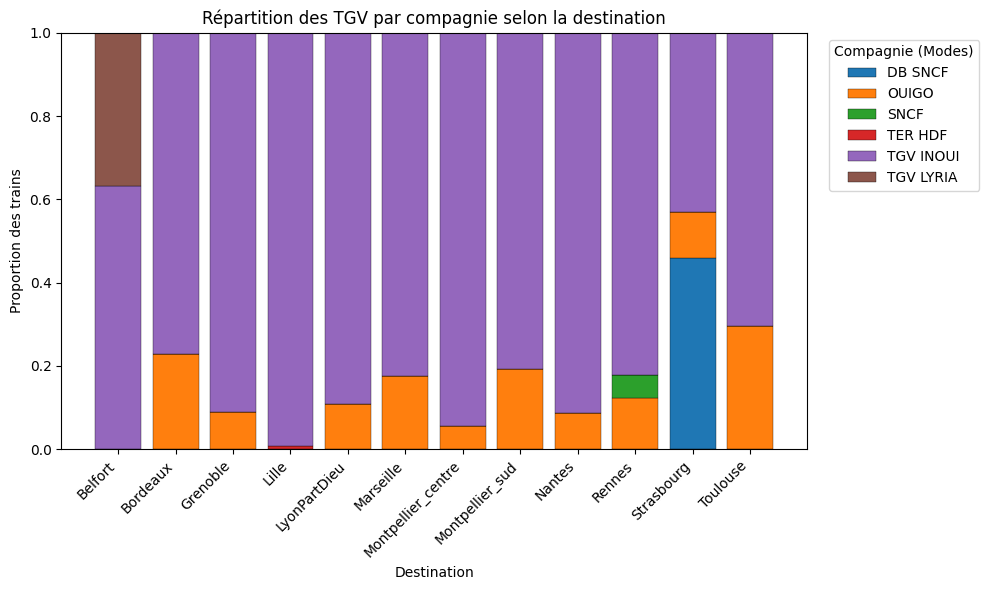

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1. Sélection des données réelles (scénario = 'reel') ===
df_reel = trains_all[trains_all["scenario"] == "reel"].copy()

# Sécurité : s'assurer que la colonne date est bien au format datetime
df_reel["date"] = pd.to_datetime(df_reel["date"], errors="coerce")

# === 2. Nettoyage simple de la colonne Modes ===
# Éviter NaN et espaces parasites
df_reel["Modes"] = df_reel["Modes"].fillna("Inconnu").str.strip()

# === 2bis. Exclure les services non pertinents pour l'analyse ===
# Ici : ignorer les trains avec Modes = "ADDITIONAL SERVICE"
df_reel = df_reel[df_reel["Modes"] != "ADDITIONAL SERVICE"].copy()

# (Optionnel) Vérification rapide
# print(df_reel["Modes"].value_counts())

# === 3. Comptage des trains par destination et par compagnie (Modes) ===
counts = (
    df_reel
    .groupby(["destination", "Modes"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# === 4. Conversion en proportions (par destination) ===
proportions = counts.div(counts.sum(axis=1), axis=0)

# Tri des destinations (optionnel)
proportions = proportions.sort_index()

# === 5. Tracé du diagramme en barres empilées ===
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(proportions.index))
bottom = np.zeros(len(proportions.index))

for mode in proportions.columns:
    ax.bar(
        x,
        proportions[mode].values,
        bottom=bottom,
        label=mode,
        edgecolor="black",
        linewidth=0.25
    )
    bottom += proportions[mode].values

ax.set_xticks(x)
ax.set_xticklabels(proportions.index, rotation=45, ha="right")

ax.set_title("Répartition des TGV par compagnie selon la destination")
ax.set_xlabel("Destination")
ax.set_ylabel("Proportion des trains")
ax.set_ylim(0, 1)

ax.legend(title="Compagnie (Modes)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


Modes_clean,DB SNCF,OUIGO,SNCF,TER HDF,TGV INOUI,TGV LYRIA
classe_retard_arrivee,,,,,,
0–5 min,30,35,4,1,627,15
5–10 min,21,63,3,0,282,11
10–30 min,45,63,4,0,457,9
30 min–1 h,13,43,0,0,237,7
1–2 h,6,25,0,0,76,1
2–3 h,2,3,0,0,17,0
> 3 h,2,3,0,0,4,1


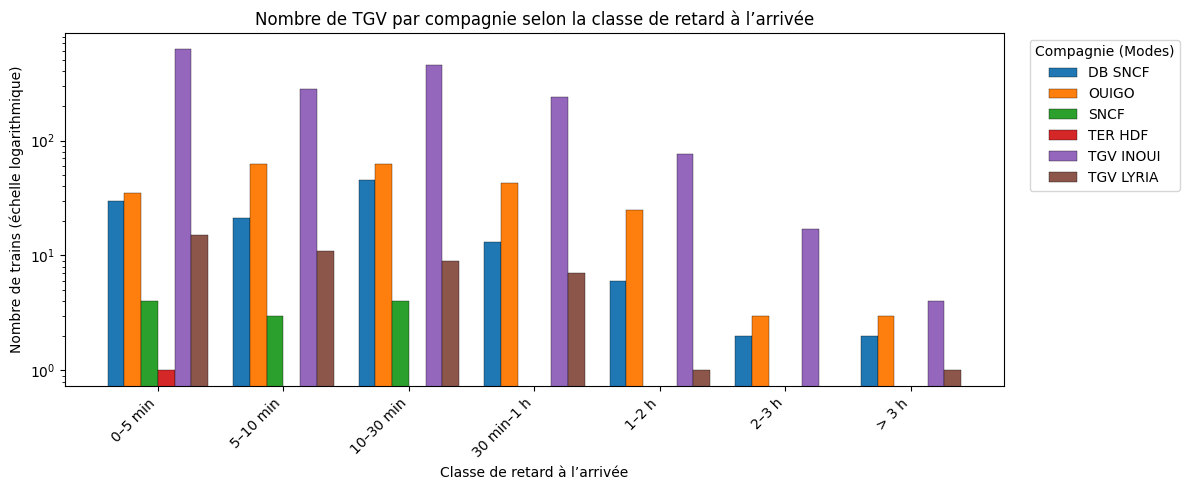

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Préparer les données : retard à l'arrivée (en minutes) + compagnie (Modes) ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

# Datetimes (réel / prévu)
df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# Correction des arrivées après minuit
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# Retard à l'arrivée (en minutes)
df["retard_arrivee_min"] = (
    df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# === 2. Garder uniquement les trains en retard à l'arrivée (> 0) ===
df = df[df["retard_arrivee_min"] > 0].copy()

# === 3. Récupérer la compagnie (Modes) depuis df_merged (compatibilité) ===
# Selon la manière dont df_merged a été construit, la colonne peut s'appeler Modes_reel ou Modes
mode_col = "Modes_reel" if "Modes_reel" in df.columns else ("Modes" if "Modes" in df.columns else None)
if mode_col is None:
    raise KeyError("Colonne Modes introuvable dans df_merged (attendu: 'Modes_reel' ou 'Modes').")

df["Modes_clean"] = df[mode_col].fillna("Inconnu").astype(str).str.strip()
df = df[df["Modes_clean"] != "ADDITIONAL SERVICE"].copy()

# === 4. Définir les classes de retard demandées ===
bins = [0, 5, 10, 30, 60, 120, 180, np.inf]
labels = ["0–5 min", "5–10 min", "10–30 min", "30 min–1 h", "1–2 h", "2–3 h", "> 3 h"]

df["classe_retard_arrivee"] = pd.cut(
    df["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# === 5. Tableau de comptage : (classe de retard) x (compagnie) ===
counts = (
    df.groupby(["classe_retard_arrivee", "Modes_clean"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=labels, fill_value=0)  # garder l'ordre des classes
)

# Affichage du tableau (pour vérifier)
display(counts)

# === 6. Diagramme en barres groupées avec axe Y logarithmique ===
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(counts.index))
n_modes = len(counts.columns)

bar_width = min(0.8 / max(n_modes, 1), 0.25)

for i, mode in enumerate(counts.columns):
    ax.bar(
        x + (i - (n_modes - 1) / 2) * bar_width,
        counts[mode].values,
        width=bar_width,
        label=mode,
        edgecolor="black",
        linewidth=0.25
    )

ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=45, ha="right")

# 👉 关键一行：对数纵坐标
ax.set_yscale("log")

ax.set_title("Nombre de TGV par compagnie selon la classe de retard à l’arrivée")
ax.set_xlabel("Classe de retard à l’arrivée")
ax.set_ylabel("Nombre de trains (échelle logarithmique)")

ax.legend(title="Compagnie (Modes)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Modes_clean,DB SNCF,OUIGO,SNCF,TER HDF,TGV INOUI,TGV LYRIA
classe_retard_arrivee,,,,,,
0–5 min,0.078125,0.037155,0.100,0.2,0.108122,0.116279
5–10 min,0.054688,0.066879,0.075,0.0,0.048629,0.085271
10–30 min,0.117188,0.066879,0.100,0.0,0.078807,0.069767
30 min–1 h,0.033854,0.045648,0.000,0.0,0.040869,0.054264
1–2 h,0.015625,0.026539,0.000,0.0,0.013106,0.007752
2–3 h,0.005208,0.003185,0.000,0.0,0.002932,0.000000
> 3 h,0.005208,0.003185,0.000,0.0,0.000690,0.007752


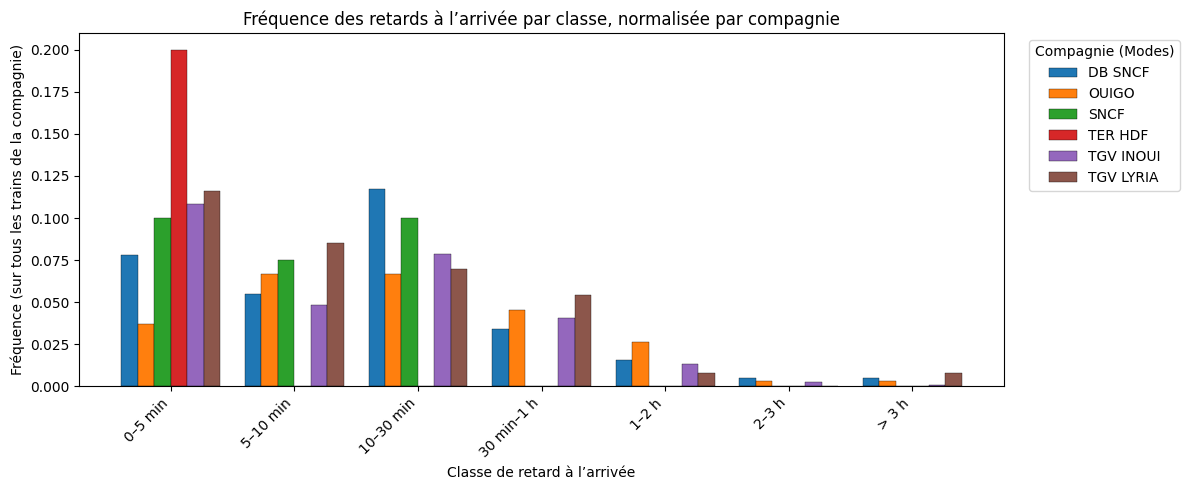

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Préparer les données : retard à l'arrivée (en minutes) + compagnie (Modes) ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# Correction des arrivées après minuit
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# Retard à l'arrivée (en minutes)
df["retard_arrivee_min"] = (
    df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# === 2. Récupérer la compagnie (Modes) ===
mode_col = "Modes_reel" if "Modes_reel" in df.columns else ("Modes" if "Modes" in df.columns else None)
if mode_col is None:
    raise KeyError("Colonne Modes introuvable dans df_merged (attendu: 'Modes_reel' ou 'Modes').")

df["Modes_clean"] = df[mode_col].fillna("Inconnu").astype(str).str.strip()
df = df[df["Modes_clean"] != "ADDITIONAL SERVICE"].copy()

# === 3. Définir les classes de retard demandées (uniquement > 0 min) ===
bins = [0, 5, 10, 30, 60, 120, 180, np.inf]
labels = ["0–5 min", "5–10 min", "10–30 min", "30 min–1 h", "1–2 h", "2–3 h", "> 3 h"]

df["classe_retard_arrivee"] = pd.cut(
    df["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# === 4. Calcul du total des trains par compagnie (dénominateur) ===
total_par_mode = df.groupby("Modes_clean", observed=True).size()

# === 5. Comptage des trains (retard dans une classe) par compagnie ===
# On ignore les trains qui ne tombent dans aucune classe (retard <= 0 ou NaN)
df_in_classes = df[df["classe_retard_arrivee"].notna()].copy()

counts = (
    df_in_classes
    .groupby(["classe_retard_arrivee", "Modes_clean"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=labels, fill_value=0)
)

# === 6. Conversion en fréquences : / total de la compagnie ===
freq = counts.copy()
for mode in freq.columns:
    freq[mode] = freq[mode] / total_par_mode.get(mode, np.nan)

# Remplacer d'éventuels NaN (si une compagnie n'a aucun train, rare) par 0
freq = freq.fillna(0)

# Affichage (vérification)
display(freq)

# === 7. Diagramme en barres groupées (fréquences) ===
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(freq.index))
n_modes = len(freq.columns)
bar_width = min(0.8 / max(n_modes, 1), 0.25)

for i, mode in enumerate(freq.columns):
    ax.bar(
        x + (i - (n_modes - 1) / 2) * bar_width,
        freq[mode].values,
        width=bar_width,
        label=mode,
        edgecolor="black",
        linewidth=0.25
    )

ax.set_xticks(x)
ax.set_xticklabels(freq.index, rotation=45, ha="right")

ax.set_title("Fréquence des retards à l’arrivée par classe, normalisée par compagnie")
ax.set_xlabel("Classe de retard à l’arrivée")
ax.set_ylabel("Fréquence (sur tous les trains de la compagnie)")

ax.legend(title="Compagnie (Modes)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


['ADDITIONAL SERVICE', 'DB SNCF', 'OUIGO', 'SNCF', 'TER HDF', 'TGV INOUI', 'TGV LYRIA']


Modes_clean,OUIGO,TGV INOUI
classe_retard_arrivee,,
0–5 min,0.037155,0.108122
5–10 min,0.066879,0.048629
10–30 min,0.066879,0.078807
30 min–1 h,0.045648,0.040869
1–2 h,0.026539,0.013106
2–3 h,0.003185,0.002932
> 3 h,0.003185,0.000690


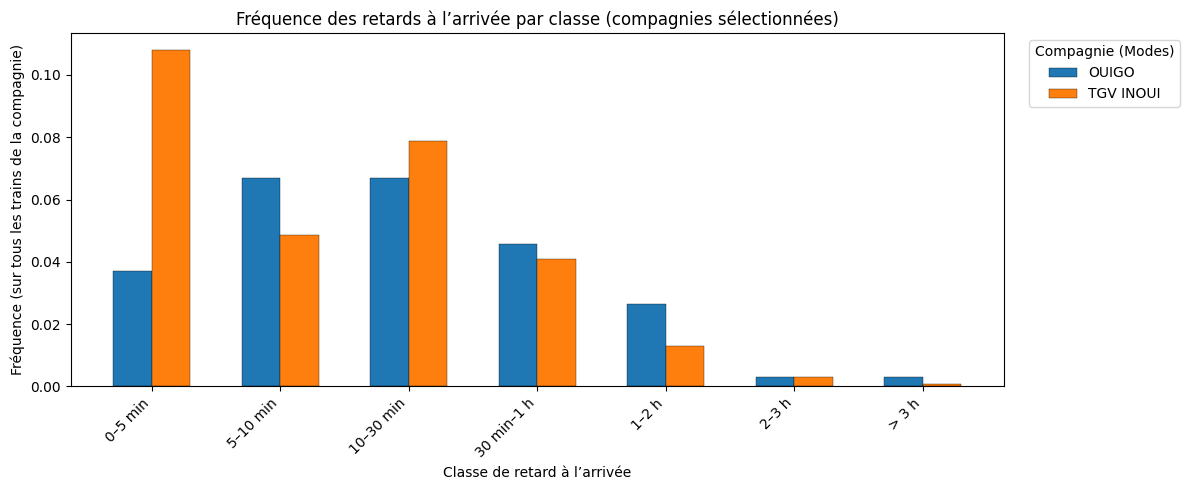

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) PARAMÈTRES À MODIFIER
# =========================
# --- Choisir les compagnies à afficher ---
modes_selectionnes = [
     'OUIGO', 'TGV INOUI'
    # "Inconnu",
]

# --- Option : afficher la liste des compagnies disponibles ---
# (utile la première fois)
print(sorted(df_merged["Modes_reel"].dropna().astype(str).str.strip().unique()))

# === 1. Préparer les données : retard à l'arrivée (en minutes) + compagnie (Modes) ===
df = df_merged.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

def build_dt(date_series, time_series):
    return pd.to_datetime(
        date_series.dt.strftime("%Y-%m-%d") + " " + time_series.astype(str),
        errors="coerce"
    )

df["depart_reel_dt"]   = build_dt(df["date"], df["Depart_reel"])
df["arrivee_reel_dt"]  = build_dt(df["date"], df["Arrivee_reel"])
df["depart_prevu_dt"]  = build_dt(df["date"], df["Depart_prevu"])
df["arrivee_prevu_dt"] = build_dt(df["date"], df["Arrivee_prevu"])

# Correction des arrivées après minuit
for suffix in ["reel", "prevu"]:
    dep = f"depart_{suffix}_dt"
    arr = f"arrivee_{suffix}_dt"
    mask = df[arr].notna() & df[dep].notna() & (df[arr] < df[dep])
    df.loc[mask, arr] = df.loc[mask, arr] + pd.Timedelta(days=1)

# Retard à l'arrivée (en minutes)
df["retard_arrivee_min"] = (
    df["arrivee_reel_dt"] - df["arrivee_prevu_dt"]
).dt.total_seconds() / 60.0

# === 2. Récupérer la compagnie (Modes) ===
mode_col = "Modes_reel" if "Modes_reel" in df.columns else ("Modes" if "Modes" in df.columns else None)
if mode_col is None:
    raise KeyError("Colonne Modes introuvable dans df_merged (attendu: 'Modes_reel' ou 'Modes').")

df["Modes_clean"] = df[mode_col].fillna("Inconnu").astype(str).str.strip()

# === 3. Filtrer sur les compagnies sélectionnées ===
df = df[df["Modes_clean"].isin(modes_selectionnes)].copy()

# === 4. Définir les classes de retard demandées (uniquement > 0 min) ===
bins = [0, 5, 10, 30, 60, 120, 180, np.inf]
labels = ["0–5 min", "5–10 min", "10–30 min", "30 min–1 h", "1–2 h", "2–3 h", "> 3 h"]

df["classe_retard_arrivee"] = pd.cut(
    df["retard_arrivee_min"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# === 5. Total des trains par compagnie (dénominateur) ===
total_par_mode = df.groupby("Modes_clean", observed=True).size()

# === 6. Comptage des trains dans chaque classe (numérateur) ===
df_in_classes = df[df["classe_retard_arrivee"].notna()].copy()

counts = (
    df_in_classes
    .groupby(["classe_retard_arrivee", "Modes_clean"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=labels, fill_value=0)
)

# === 7. Fréquences : / total de la compagnie ===
freq = counts.copy()
for mode in freq.columns:
    freq[mode] = freq[mode] / total_par_mode.get(mode, np.nan)
freq = freq.fillna(0)

display(freq)

# === 8. Diagramme en barres groupées (fréquences) ===
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(freq.index))
n_modes = len(freq.columns)
bar_width = min(0.8 / max(n_modes, 1), 0.3)

for i, mode in enumerate(freq.columns):
    ax.bar(
        x + (i - (n_modes - 1) / 2) * bar_width,
        freq[mode].values,
        width=bar_width,
        label=mode,
        edgecolor="black",
        linewidth=0.25
    )

ax.set_xticks(x)
ax.set_xticklabels(freq.index, rotation=45, ha="right")

ax.set_title("Fréquence des retards à l’arrivée par classe (compagnies sélectionnées)")
ax.set_xlabel("Classe de retard à l’arrivée")
ax.set_ylabel("Fréquence (sur tous les trains de la compagnie)")

ax.legend(title="Compagnie (Modes)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [39]:
import numpy as np
import pandas as pd

# === 1. Vérifications minimales ===
# On suppose que df_retards existe déjà (construit à partir des fichiers *_retards_*)
required_cols = ["Modes", "Duree_prev", "Retard_arrivee(min)"]
missing = [c for c in required_cols if c not in df_retards.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df_retards : {missing}")

df = df_retards.copy()

# === 2. Nettoyage des colonnes (types + valeurs) ===
# Normaliser le nom de compagnie
df["Modes_clean"] = df["Modes"].fillna("Inconnu").astype(str).str.strip()

# Convertir en numérique (gère virgules, espaces, chaînes, etc.)
df["Duree_prev_num"] = pd.to_numeric(
    df["Duree_prev"].astype(str).str.replace(",", ".", regex=False).str.strip(),
    errors="coerce"
)
df["Retard_arrivee_min_num"] = pd.to_numeric(
    df["Retard_arrivee(min)"].astype(str).str.replace(",", ".", regex=False).str.strip(),
    errors="coerce"
)

# Option : ignorer les lignes incohérentes (durée prévue <= 0, retard manquant)
df = df.dropna(subset=["Duree_prev_num", "Retard_arrivee_min_num"])
df = df[df["Duree_prev_num"] > 0]

# Option : si tu veux ne garder que les retards positifs (souvent le cas dans retards)
# df = df[df["Retard_arrivee_min_num"] > 0]

# === 3. Sélection des compagnies d'intérêt ===
modes_cibles = ["TGV INOUI", "OUIGO"]
df_sel = df[df["Modes_clean"].isin(modes_cibles)].copy()

# === 4. Calcul de l'indicateur : somme(retard) / somme(durée prévue) ===
res = (
    df_sel.groupby("Modes_clean", observed=True)
    .agg(
        nb_trains=("Retard_arrivee_min_num", "size"),
        retard_total_min=("Retard_arrivee_min_num", "sum"),
        duree_prev_total_min=("Duree_prev_num", "sum"),
    )
)

res["ratio_retard_sur_duree_prev"] = res["retard_total_min"] / res["duree_prev_total_min"]

# === 5. Affichage ===
# Tri (du plus grand ratio au plus petit)
res = res.sort_values("ratio_retard_sur_duree_prev", ascending=False)

display(res)

# Option : version en pourcentage (facile à interpréter)
res_pct = res.copy()
res_pct["ratio_retard_sur_duree_prev_pct"] = 100 * res_pct["ratio_retard_sur_duree_prev"]
display(res_pct[["nb_trains", "retard_total_min", "duree_prev_total_min", "ratio_retard_sur_duree_prev_pct"]])


,nb_trains,retard_total_min,duree_prev_total_min,ratio_retard_sur_duree_prev
Modes_clean,,,,
TGV INOUI,692,8730.0,92616.0,0.09426
OUIGO,114,1590.0,18130.0,0.08770


,nb_trains,retard_total_min,duree_prev_total_min,ratio_retard_sur_duree_prev_pct
Modes_clean,,,,
TGV INOUI,692,8730.0,92616.0,9.426017
OUIGO,114,1590.0,18130.0,8.769994
